In [1]:
# ============================================================
# Cell 1 - Install Dependencies
# ============================================================

!pip -q install gymnasium
!pip -q install stable-baselines3
!pip -q install pygame
!pip -q install matplotlib
!pip -q install opencv-python
!pip -q install networkx
!pip -q install imageio
!pip -q install tqdm

import os
import cv2
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
import networkx as nx
import imageio

from tqdm import tqdm

import torch
from torch import nn

from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

print("="*60)
print("Maze RL Project")
print("="*60)
print("Torch Version :", torch.__version__)
print("Gymnasium     :", gym.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("\nEverything Installed Successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 5.6 MB/s eta 0:00:00
Maze RL Project
Torch Version : 2.11.0+cpu
Gymnasium     : 1.3.0
CUDA Available: False
Running on CPU

Everything Installed Successfully!


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


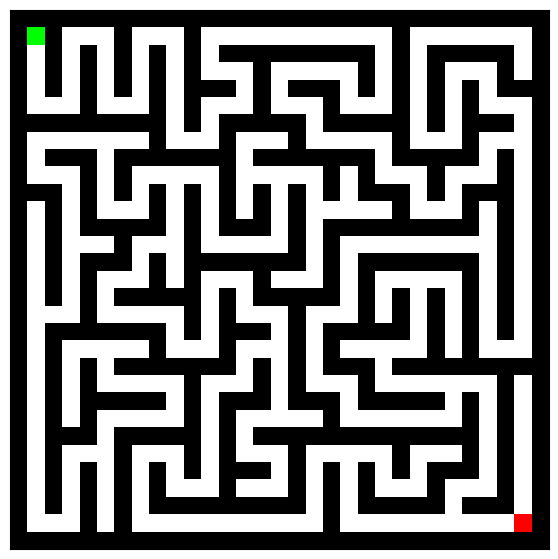

Maze Shape : (31, 31)
Start : (1, 1)
Goal : (29, 29)


In [2]:
# ============================================================
# Cell 2 - Perfect Random Maze Generator
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt

class MazeGenerator:

    WALL = 1
    PATH = 0

    def __init__(self, width=21, height=21):

        # Maze dimensions must be odd
        self.width = width if width % 2 == 1 else width + 1
        self.height = height if height % 2 == 1 else height + 1

    def generate(self):

        maze = np.ones((self.height, self.width), dtype=np.uint8)

        stack = []

        start = (1,1)

        maze[start] = self.PATH

        stack.append(start)

        directions = [
            (-2,0),
            (2,0),
            (0,-2),
            (0,2)
        ]

        while stack:

            x,y = stack[-1]

            neighbors = []

            for dx,dy in directions:

                nx = x + dx
                ny = y + dy

                if 1 <= nx < self.height-1 and 1 <= ny < self.width-1:

                    if maze[nx,ny] == self.WALL:

                        neighbors.append((nx,ny,dx,dy))

            if neighbors:

                nx,ny,dx,dy = random.choice(neighbors)

                maze[x+dx//2,y+dy//2] = self.PATH
                maze[nx,ny] = self.PATH

                stack.append((nx,ny))

            else:

                stack.pop()

        self.start = (1,1)
        self.goal = (self.height-2,self.width-2)

        maze[self.start] = 2
        maze[self.goal] = 3

        return maze

    def show(self,maze):

        img = np.zeros((maze.shape[0],maze.shape[1],3))

        # Walls
        img[maze==1] = [0,0,0]

        # Path
        img[maze==0] = [1,1,1]

        # Start
        img[maze==2] = [0,1,0]

        # Goal
        img[maze==3] = [1,0,0]

        plt.figure(figsize=(7,7))
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.show()


# ============================
# Test Generator
# ============================

generator = MazeGenerator(31,31)

maze = generator.generate()

generator.show(maze)

print("Maze Shape :", maze.shape)
print("Start :", generator.start)
print("Goal :", generator.goal)

Observation Shape : (21, 21)
Observation Min   : 0
Observation Max   : 4


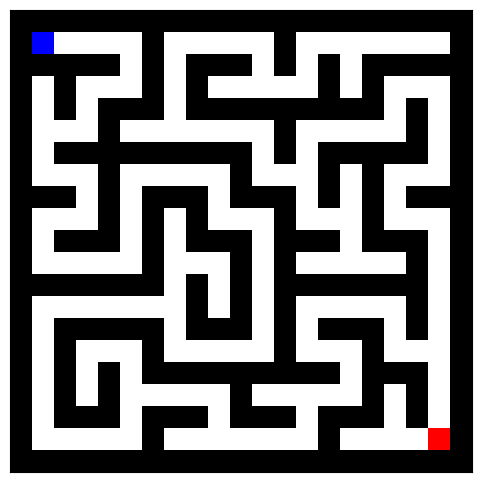


Environment Ready Successfully!


In [5]:
# ============================================================
# Cell 3 - Fixed Gymnasium Maze Environment
# ============================================================

import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt

class MazeEnv(gym.Env):

    metadata = {"render_modes": ["human"]}

    def __init__(self, maze_size=21, max_steps=500):
        super().__init__()

        self.maze_size = maze_size
        self.max_steps = max_steps

        self.generator = MazeGenerator(maze_size, maze_size)

        # 0=Up 1=Down 2=Left 3=Right
        self.action_space = spaces.Discrete(4)

        # 0 Path
        # 1 Wall
        # 2 Start
        # 3 Goal
        # 4 Agent
        self.observation_space = spaces.Box(
            low=0,
            high=4,
            shape=(maze_size, maze_size),
            dtype=np.uint8
        )

    def _get_obs(self):

        obs = self.maze.copy()

        x, y = self.agent_pos
        obs[x, y] = 4

        return obs.astype(np.uint8)

    def reset(self, seed=None, options=None):

        super().reset(seed=seed)

        self.maze = self.generator.generate()

        self.agent_pos = list(self.generator.start)

        self.goal = self.generator.goal

        self.steps = 0

        return self._get_obs(), {}

    def step(self, action):

        self.steps += 1

        x, y = self.agent_pos

        nx, ny = x, y

        if action == 0:
            nx -= 1

        elif action == 1:
            nx += 1

        elif action == 2:
            ny -= 1

        elif action == 3:
            ny += 1

        reward = -0.05

        # Boundary Check
        if (
            nx < 0
            or ny < 0
            or nx >= self.maze_size
            or ny >= self.maze_size
        ):
            reward = -2

        # Wall
        elif self.maze[nx, ny] == 1:
            reward = -2

        else:
            self.agent_pos = [nx, ny]

        terminated = False
        truncated = False

        # Goal
        if tuple(self.agent_pos) == self.goal:
            reward = 100
            terminated = True

        # Max Steps
        if self.steps >= self.max_steps:
            truncated = True

        return self._get_obs(), reward, terminated, truncated, {}

    def render(self):

        img = np.zeros((self.maze_size, self.maze_size, 3))

        img[self.maze == 1] = [0,0,0]
        img[self.maze == 0] = [1,1,1]
        img[self.maze == 2] = [0,1,0]
        img[self.maze == 3] = [1,0,0]

        ax, ay = self.agent_pos
        img[ax, ay] = [0,0,1]

        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.show()


# ============================================================
# Test Environment
# ============================================================

env = MazeEnv(21)

obs, info = env.reset()

print("Observation Shape :", obs.shape)
print("Observation Min   :", obs.min())
print("Observation Max   :", obs.max())

env.render()

from stable_baselines3.common.env_checker import check_env

check_env(env, warn=True)

print("\nEnvironment Ready Successfully!")

In [6]:
# ============================================================
# Cell 4 - PPO Training
# ============================================================

from gymnasium.wrappers import FlattenObservation
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import torch

# Create Environment
env = MazeEnv(maze_size=21)

# Flatten Observation (21x21 -> 441)
env = FlattenObservation(env)

# Monitor Training
env = Monitor(env)

print("Observation Shape:", env.observation_space.shape)
print("Action Space:", env.action_space)

# ============================================================
# PPO Model
# ============================================================

model = PPO(
    policy="MlpPolicy",
    env=env,

    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,

    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,

    verbose=1,

    device="cuda" if torch.cuda.is_available() else "cpu"
)

print("\nStarting Training...\n")

# ============================================================
# Train
# ============================================================

TOTAL_TIMESTEPS = 100_000

model.learn(total_timesteps=TOTAL_TIMESTEPS)

print("\nTraining Finished!")

# ============================================================
# Save Model
# ============================================================

model.save("maze_ppo")

print("\nModel Saved Successfully!")

Observation Shape: (441,)
Action Space: Discrete(4)
Using cpu device
Wrapping the env in a DummyVecEnv.

Starting Training...



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 500      |
|    ep_rew_mean     | -508     |
| time/              |          |
|    fps             | 1943     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
----------------------------------------
| rollout/                |            |
|    ep_len_mean          | 500        |
|    ep_rew_mean          | -506       |
| time/                   |            |
|    fps                  | 1385       |
|    iterations           | 2          |
|    time_elapsed         | 2          |
|    total_timesteps      | 4096       |
| train/                  |            |
|    approx_kl            | 0.01250371 |
|    clip_fraction        | 0.116      |
|    clip_range           | 0.2        |
|    entropy_loss         | -1.38      |
|    explained_variance   | 0.0143     |
|    learning_rate        | 0.0003     |
|   

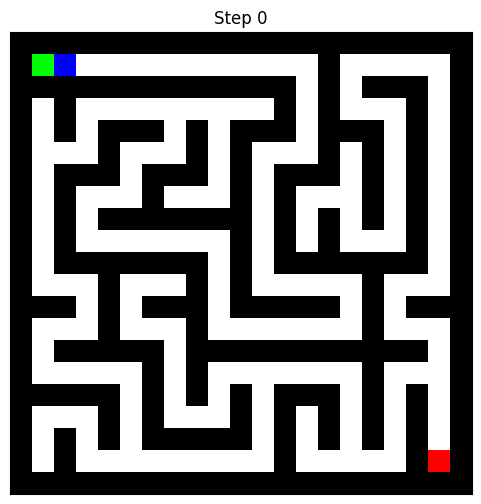

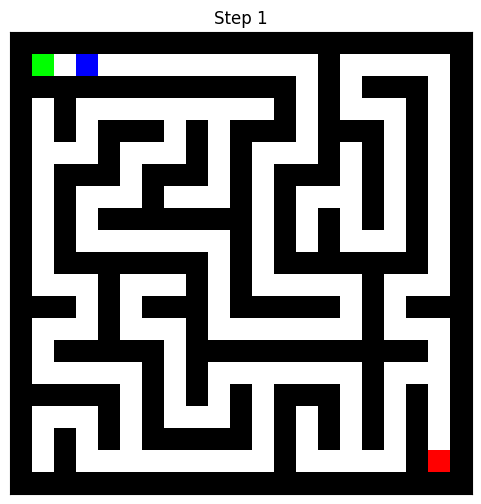

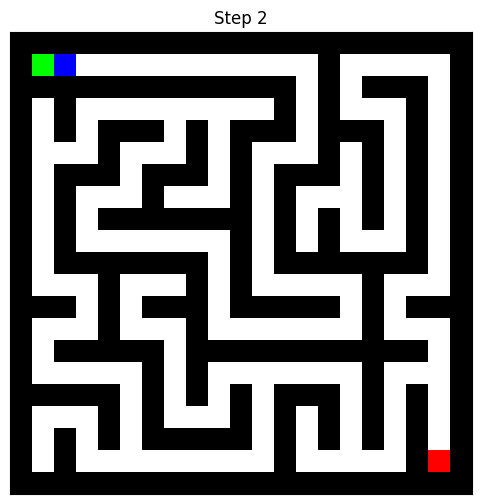

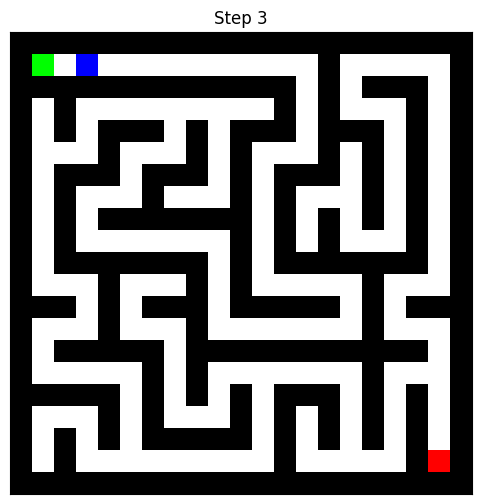

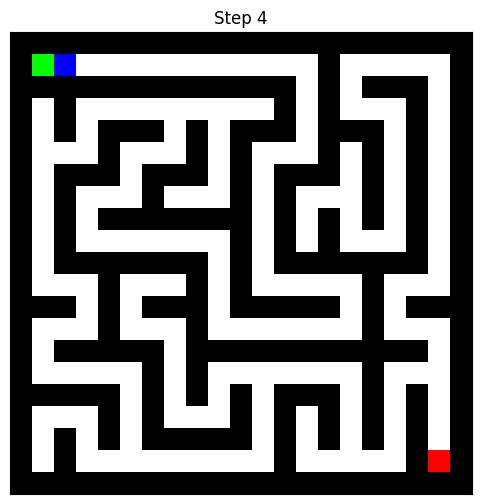

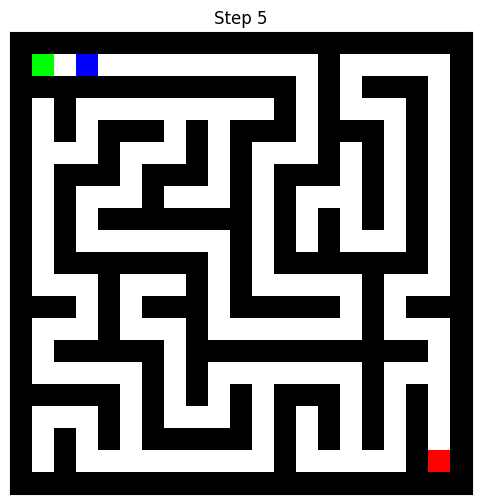

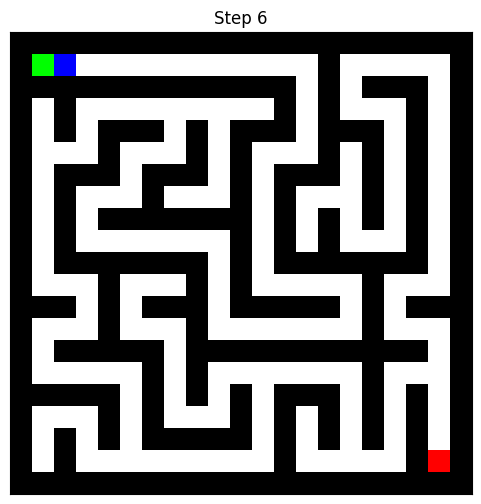

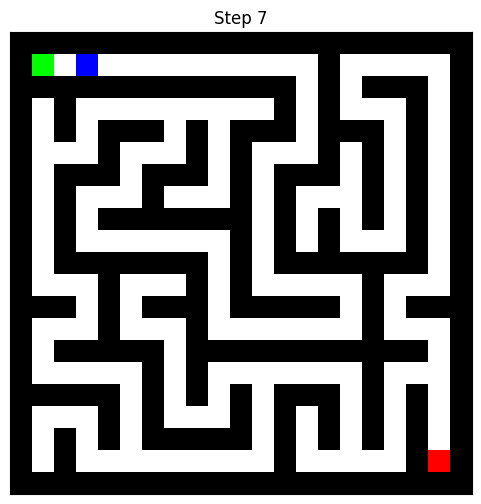

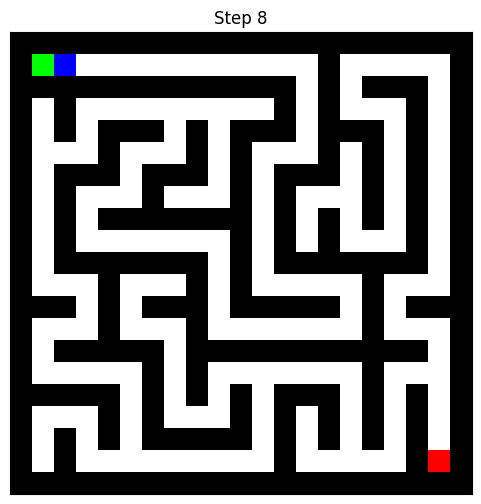

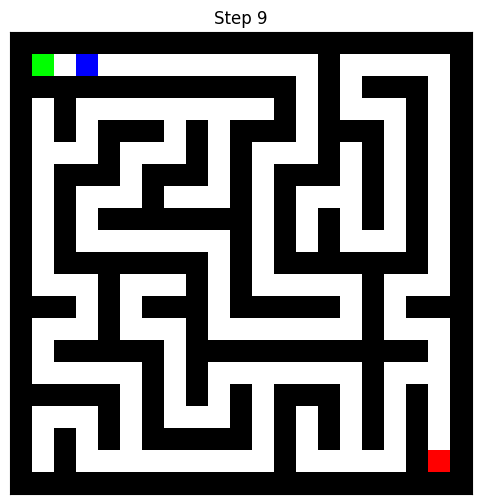

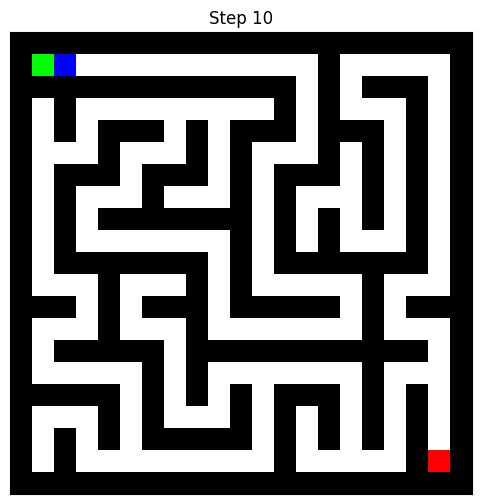

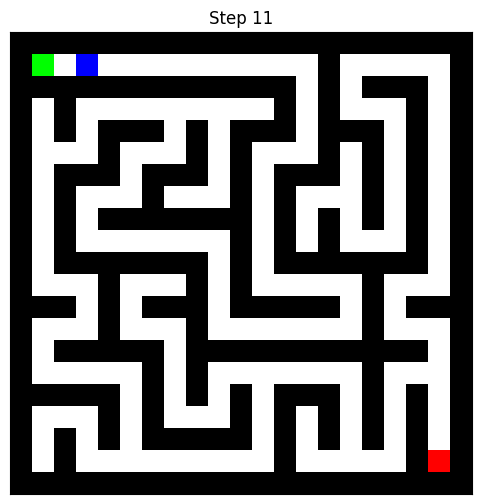

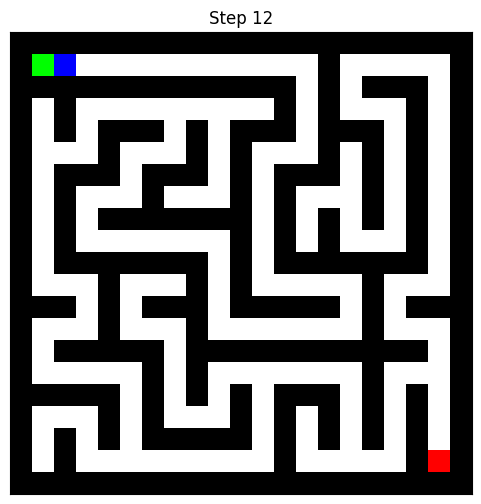

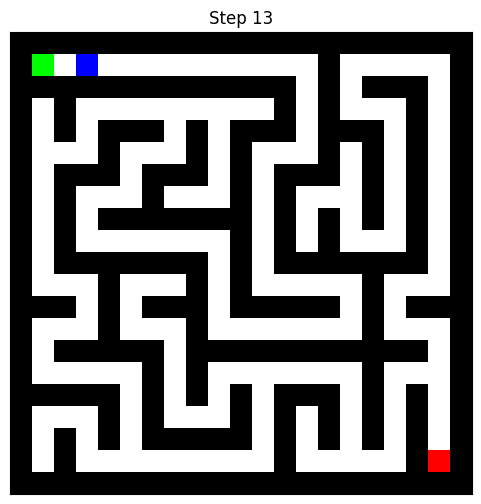

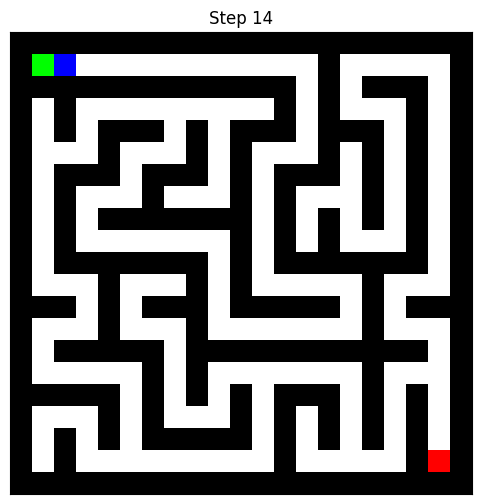

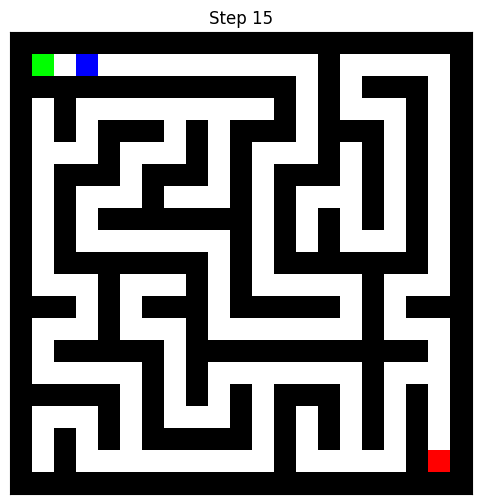

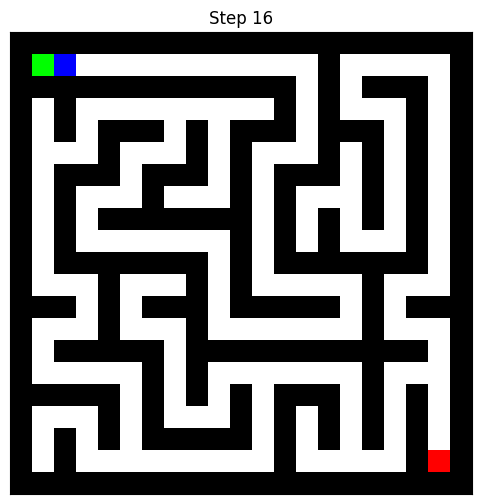

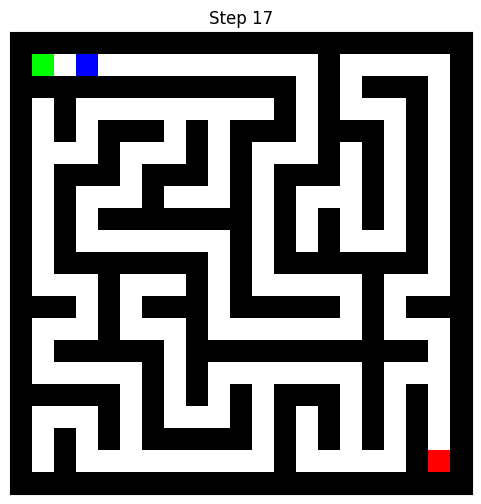

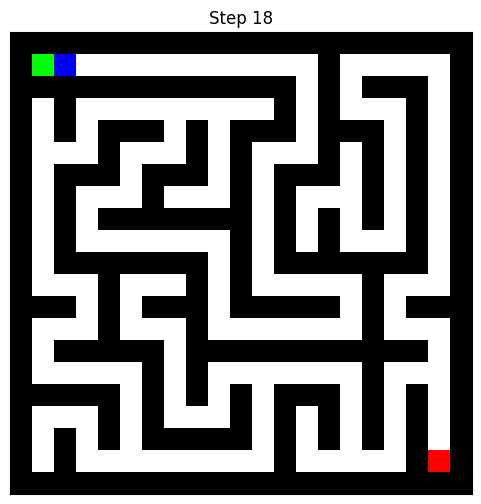

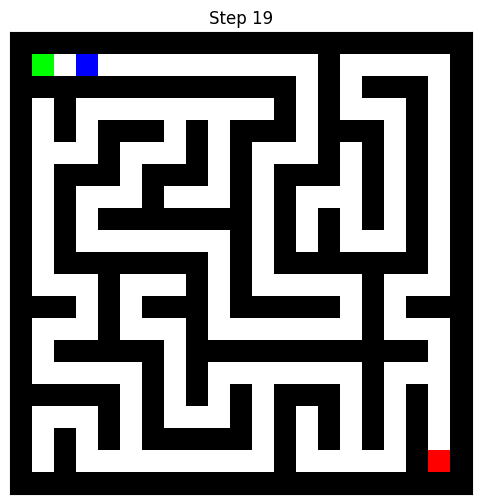

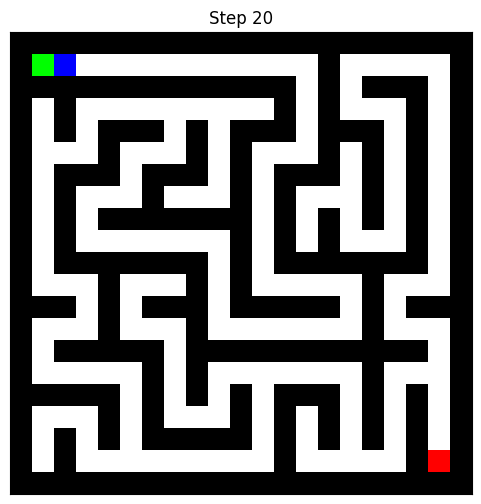

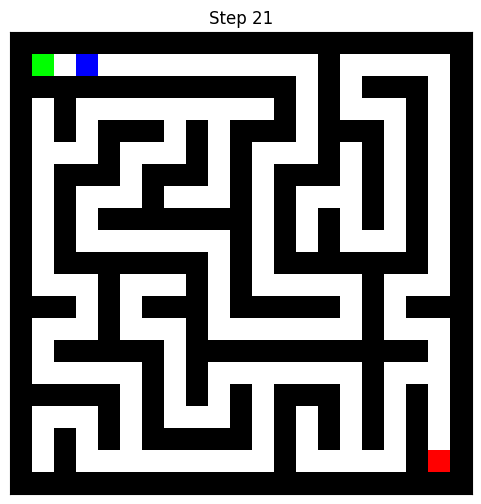

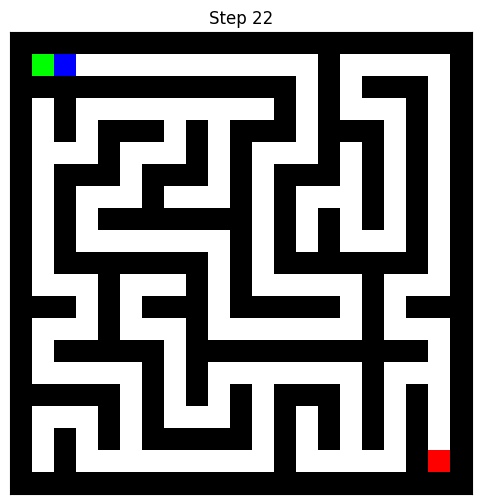

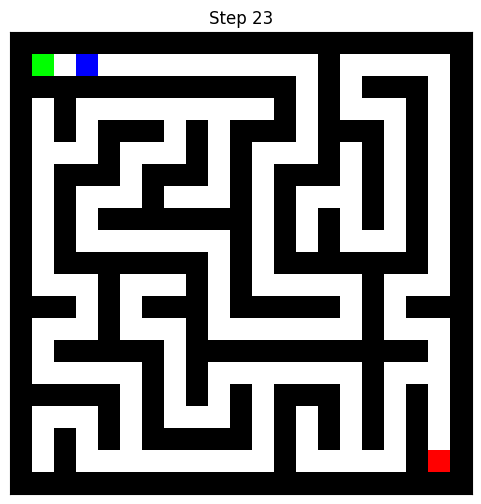

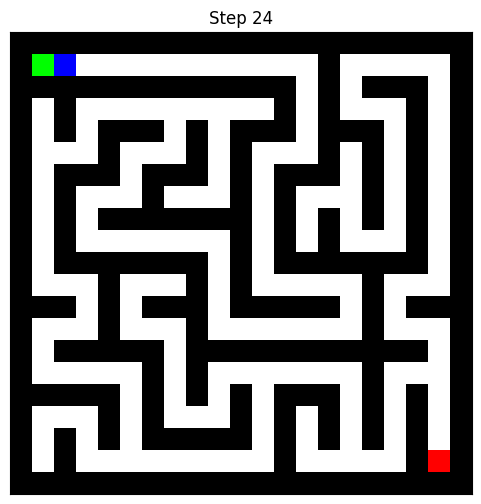

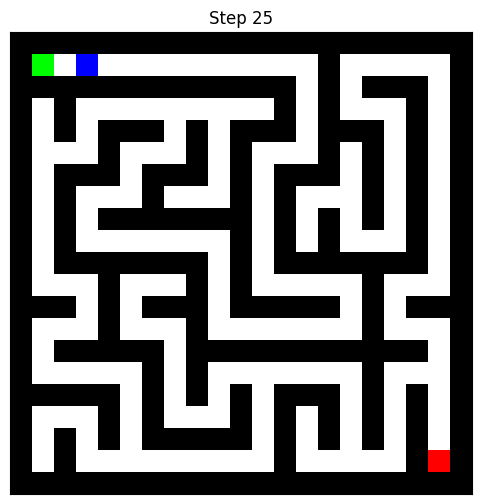

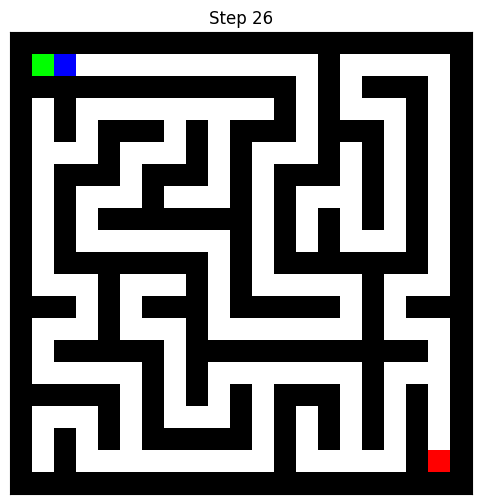

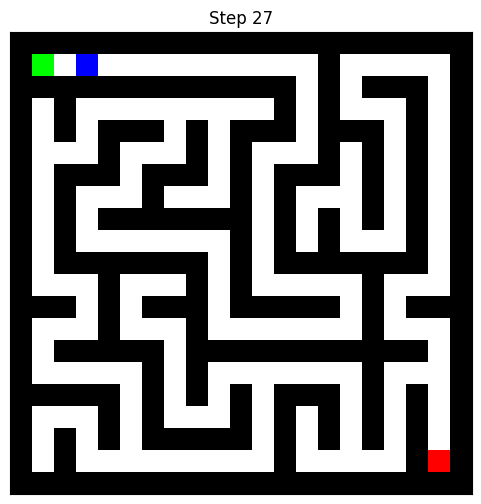

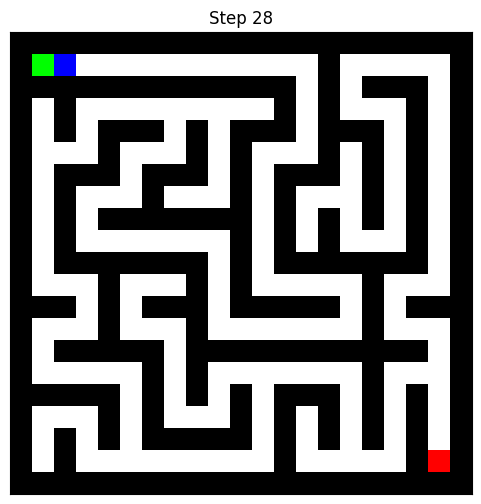

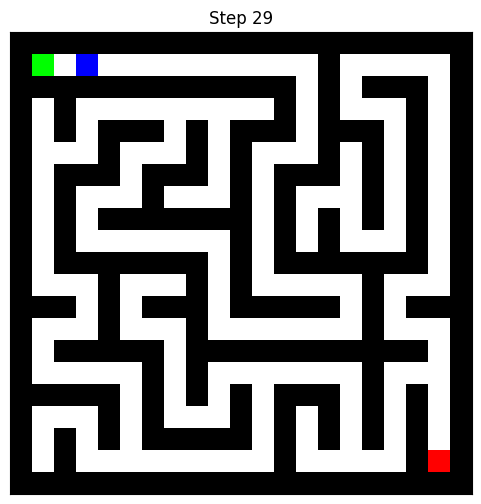

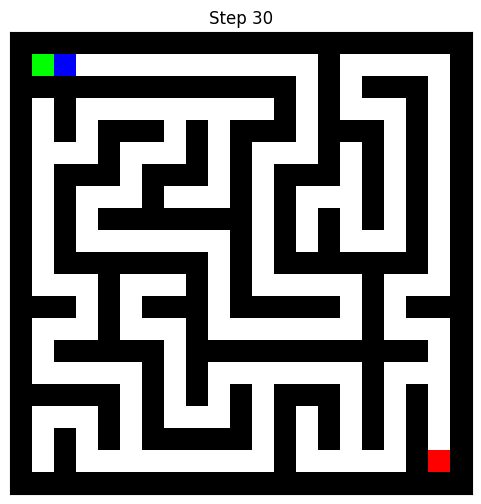

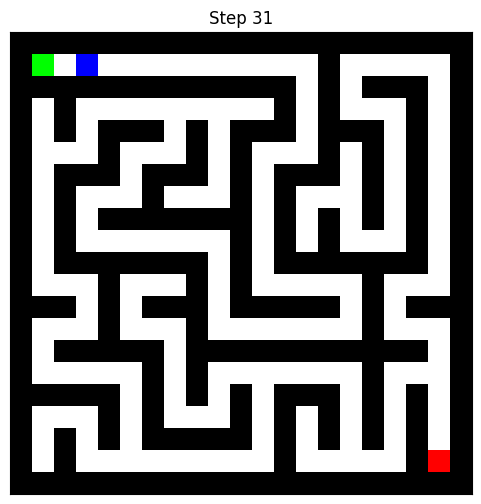

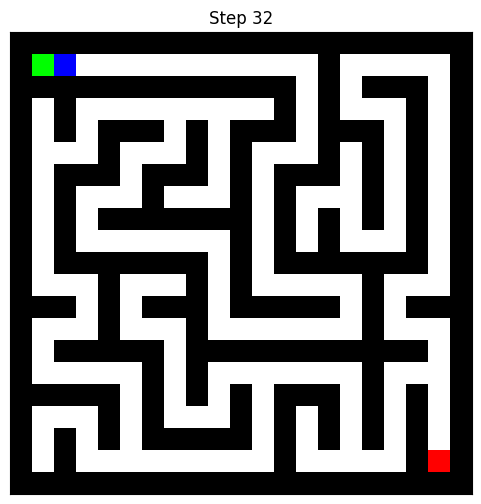

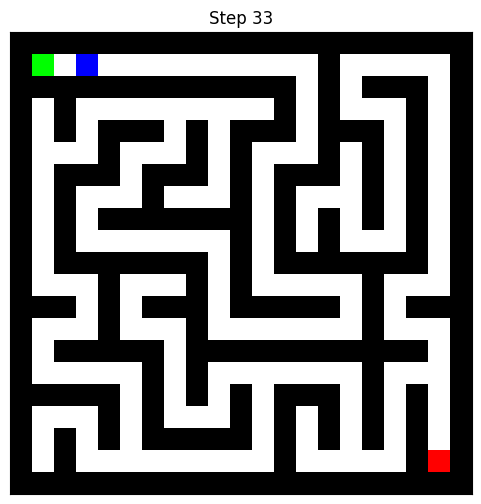

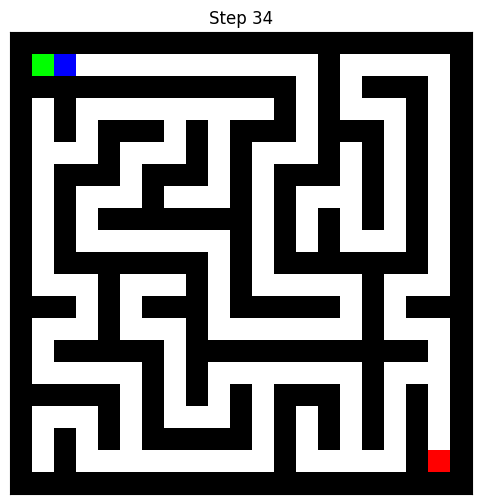

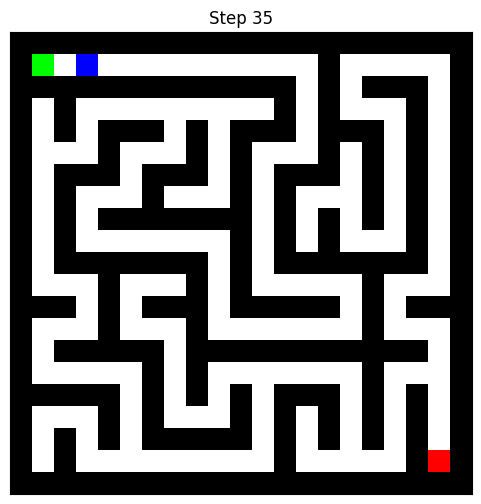

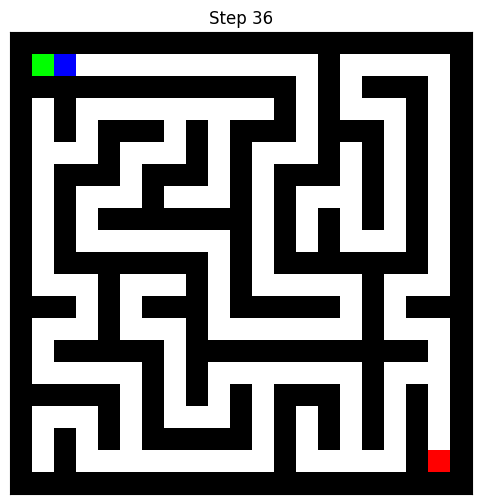

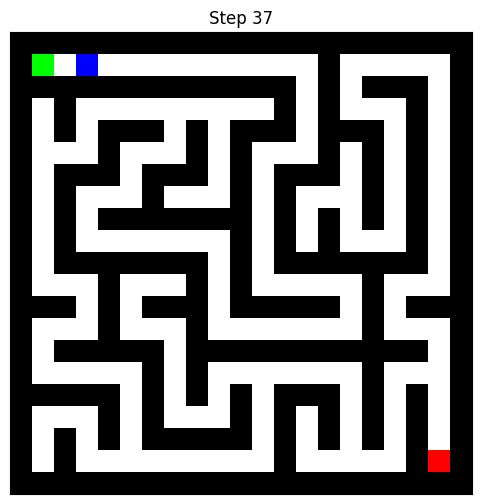

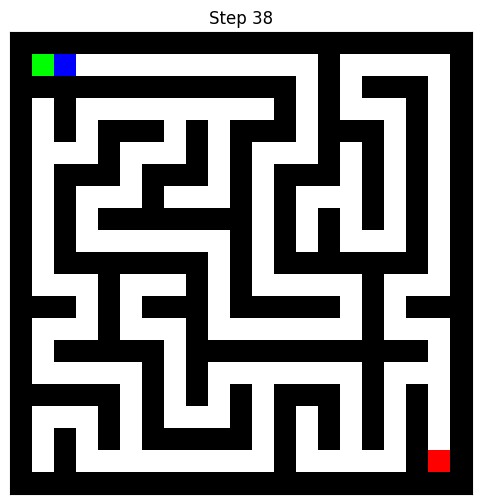

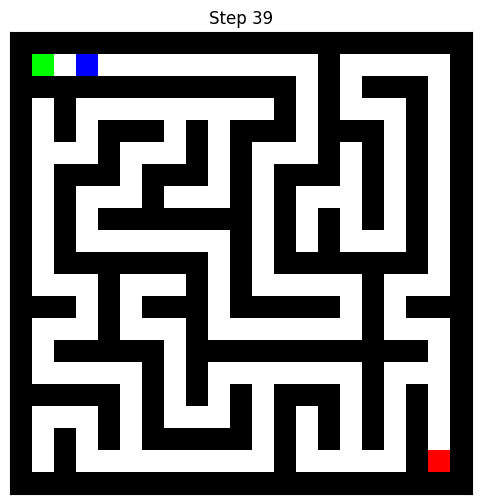

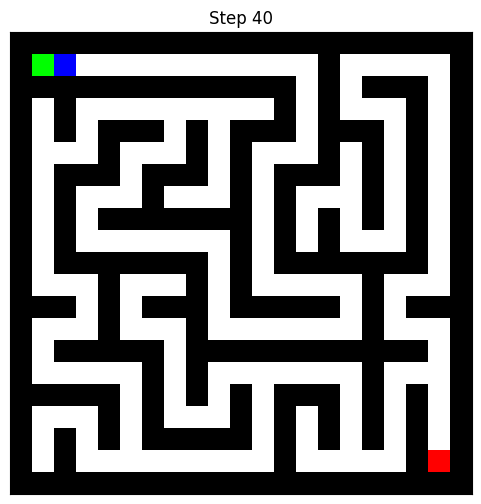

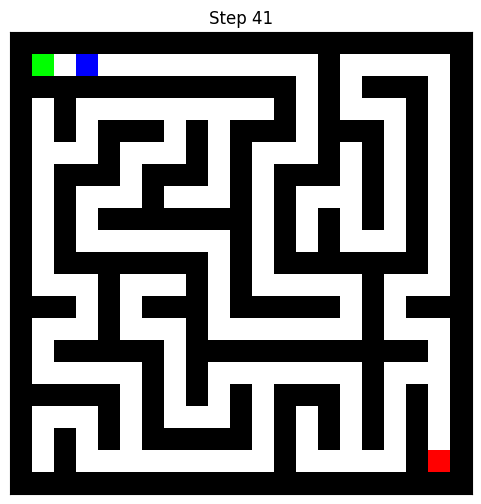

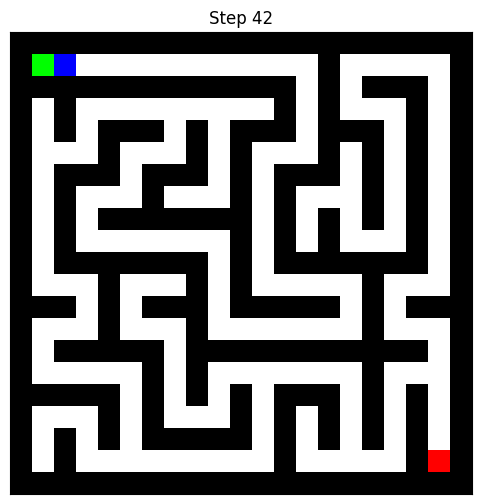

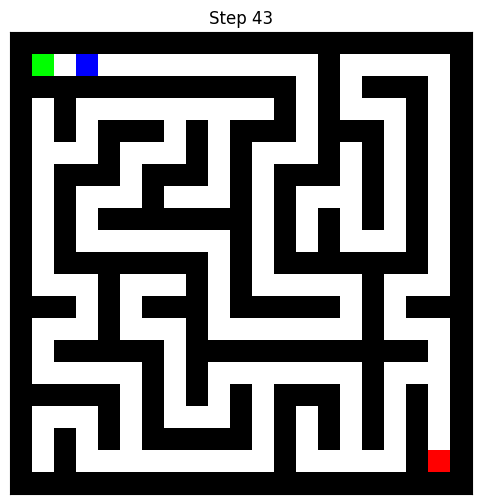

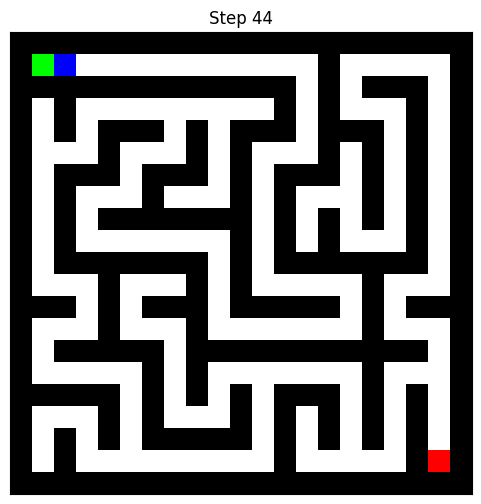

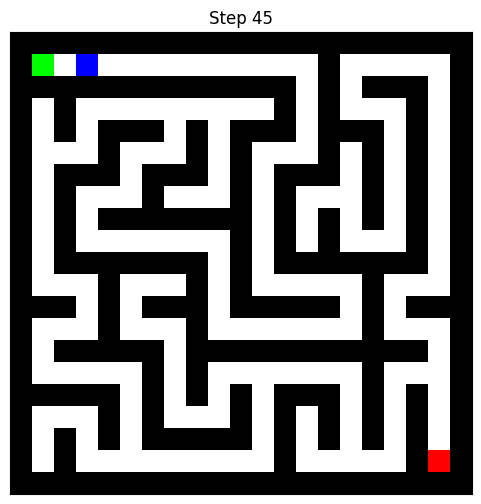

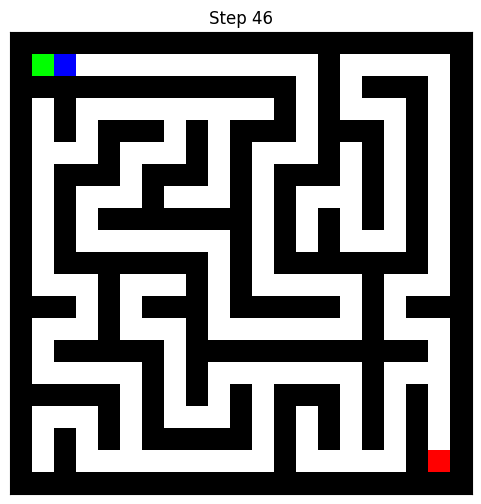

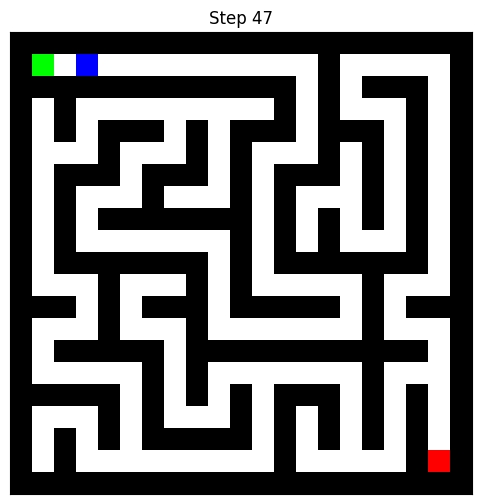

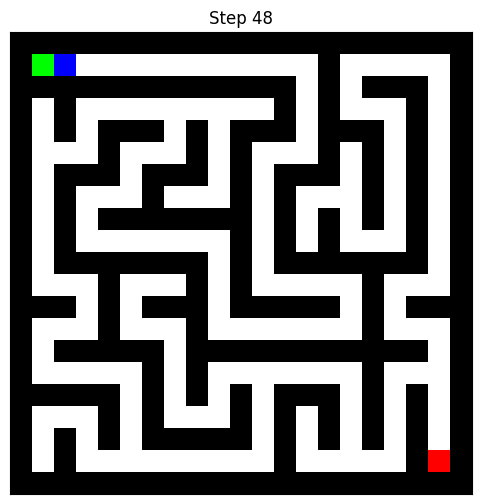

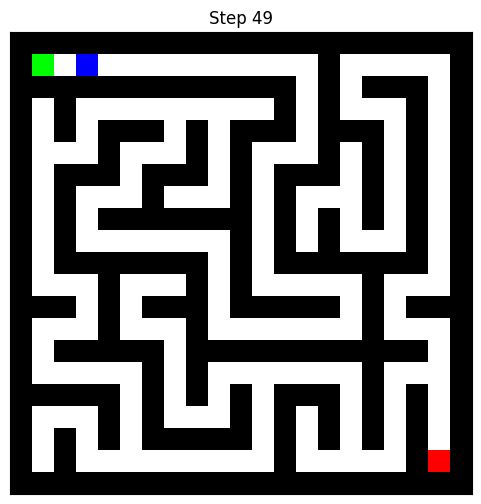

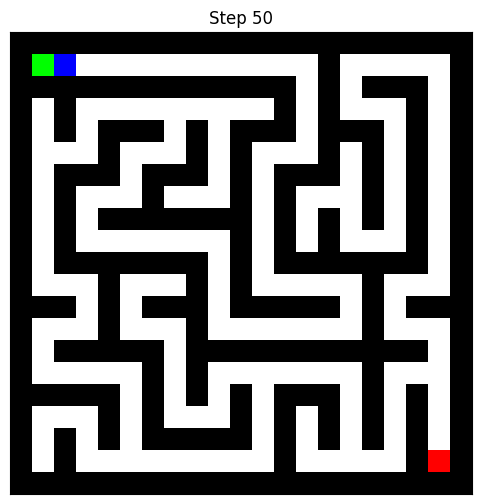

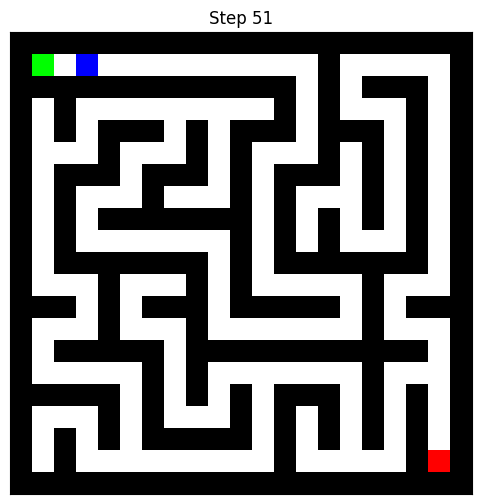

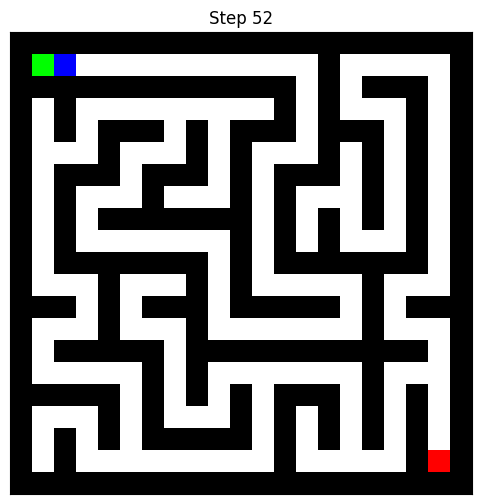

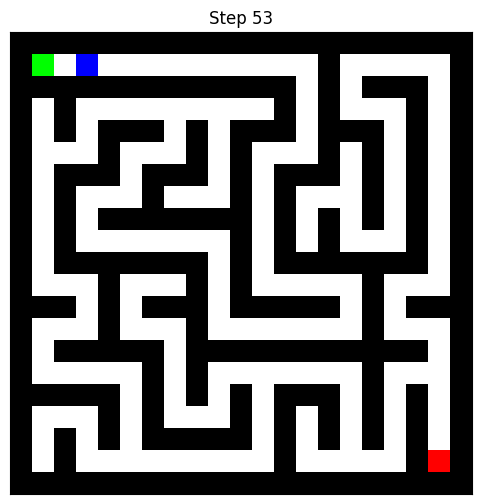

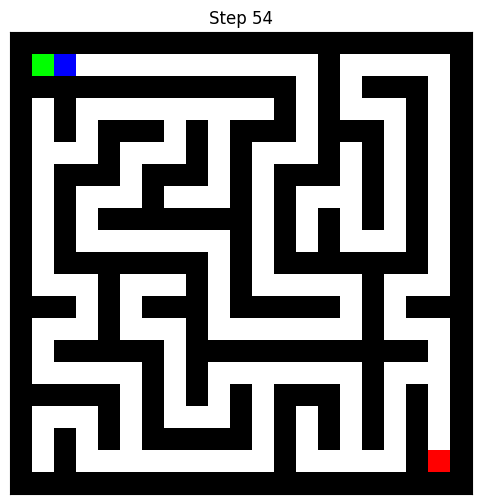

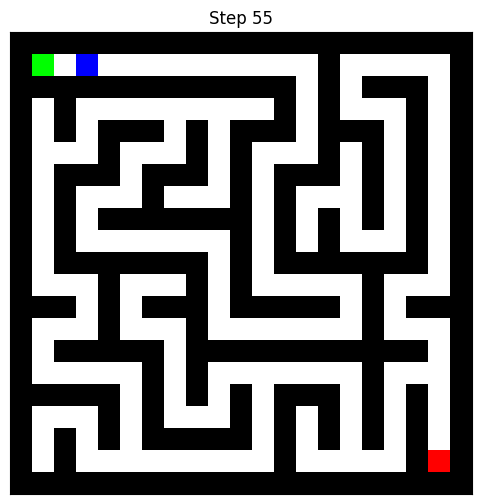

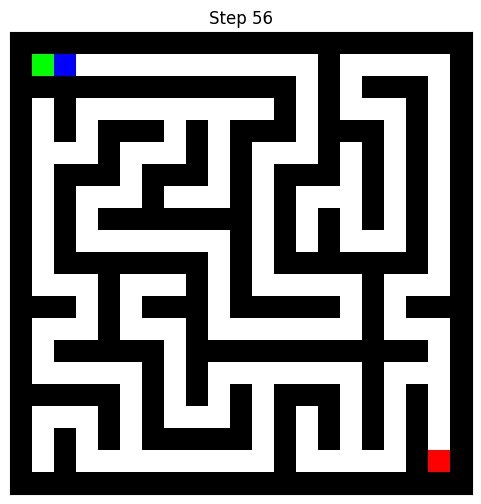

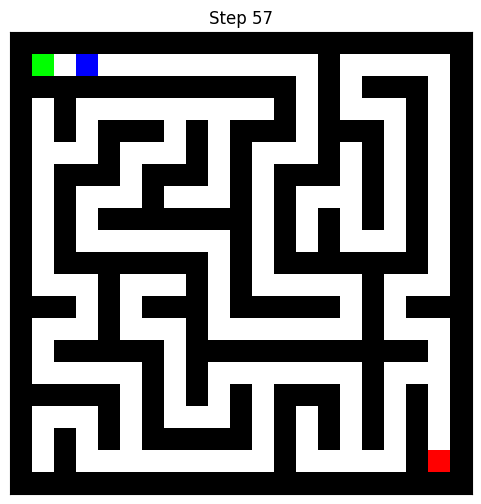

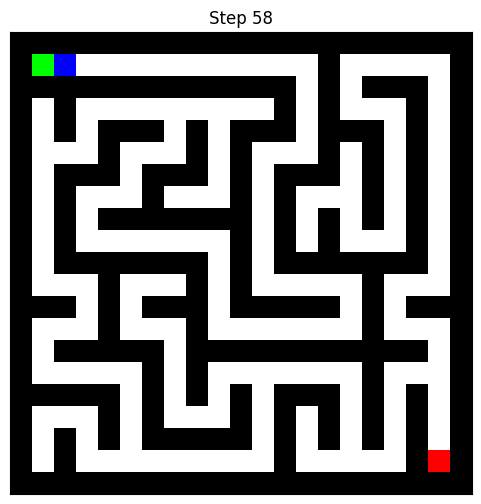

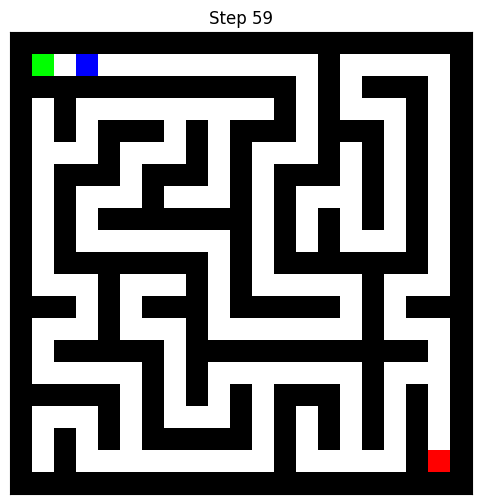

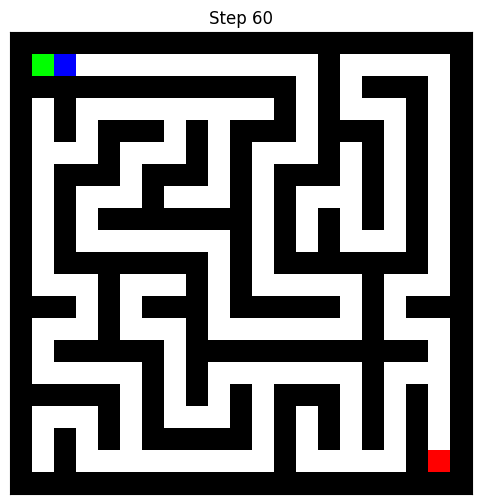

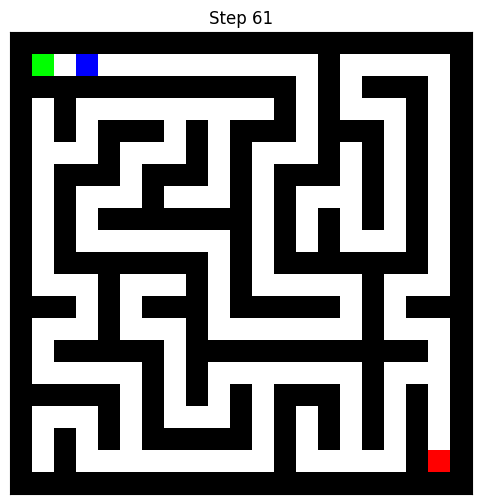

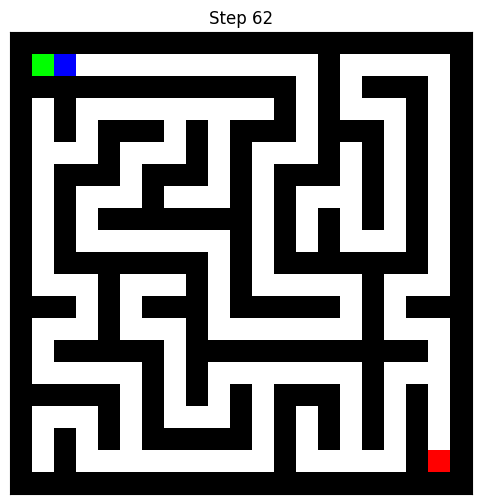

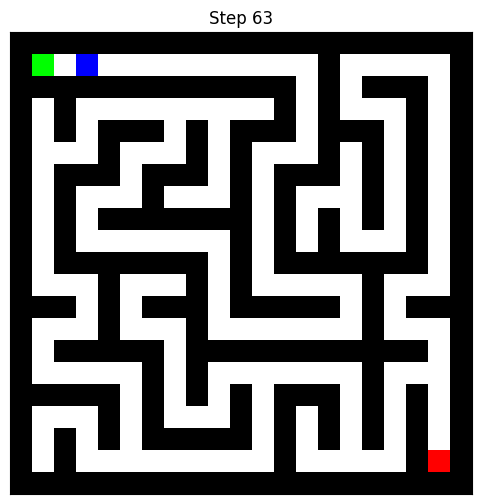

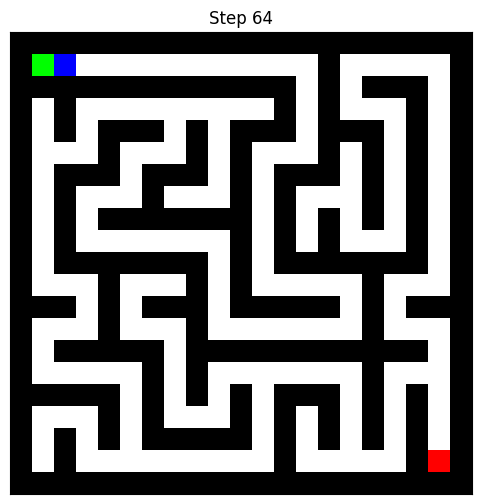

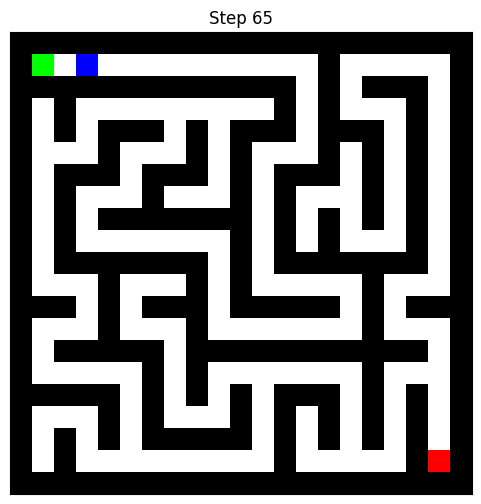

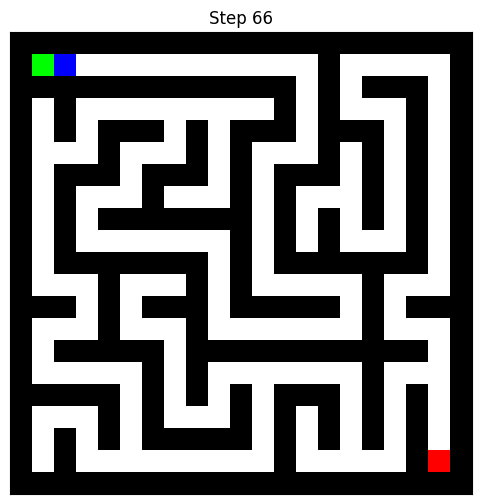

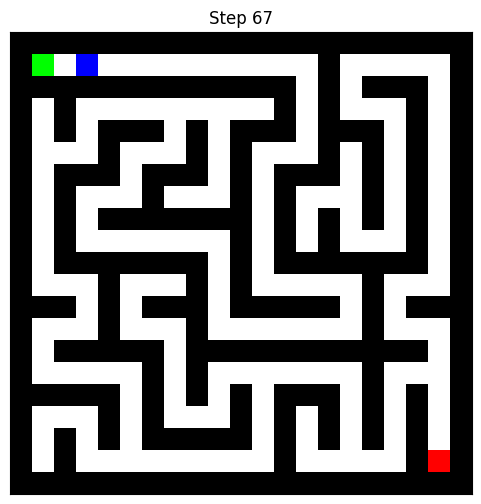

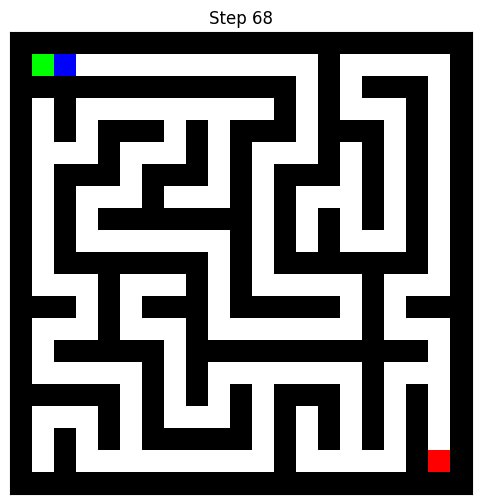

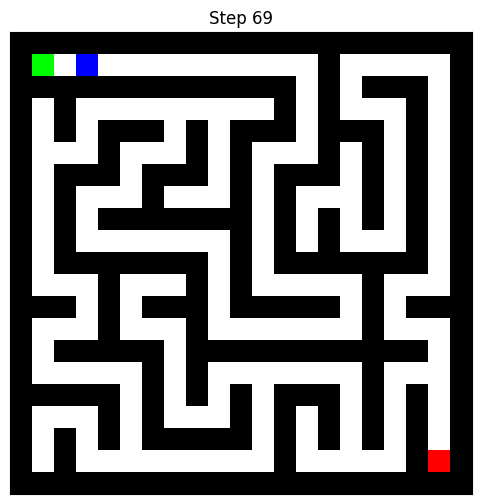

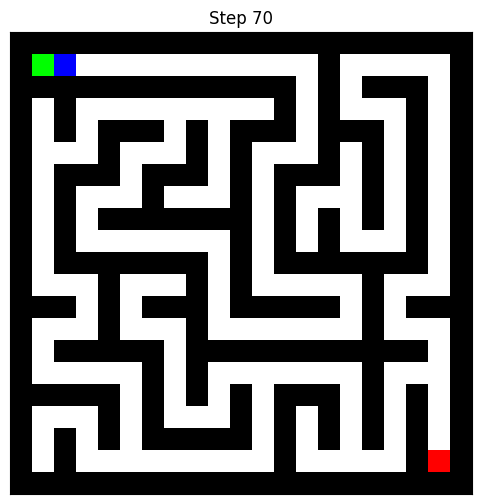

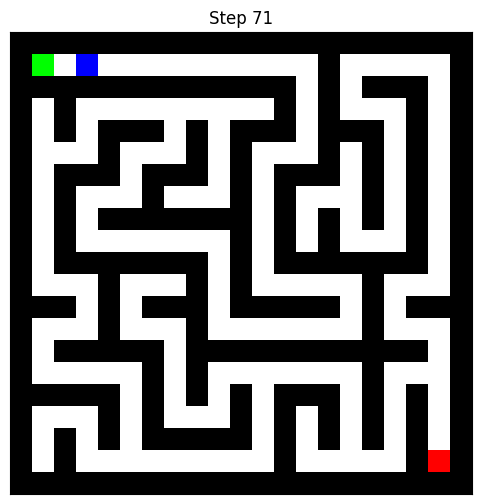

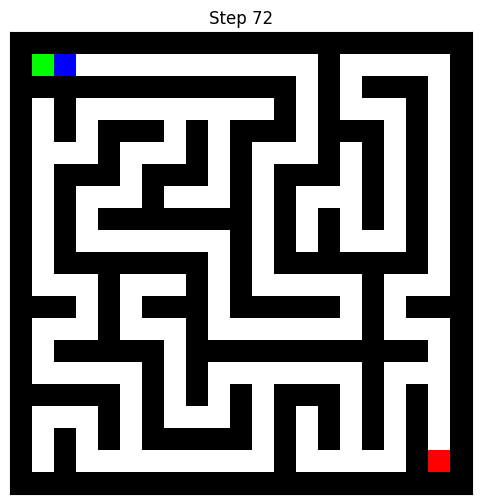

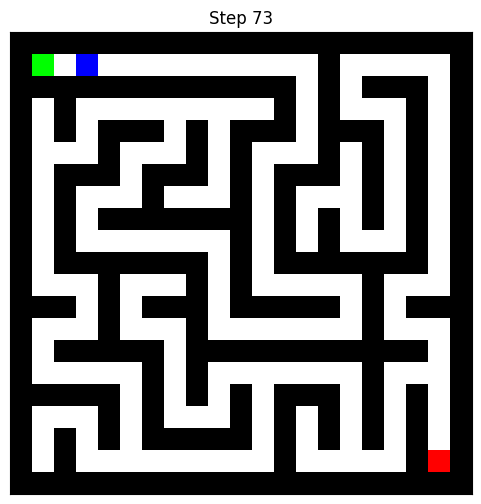

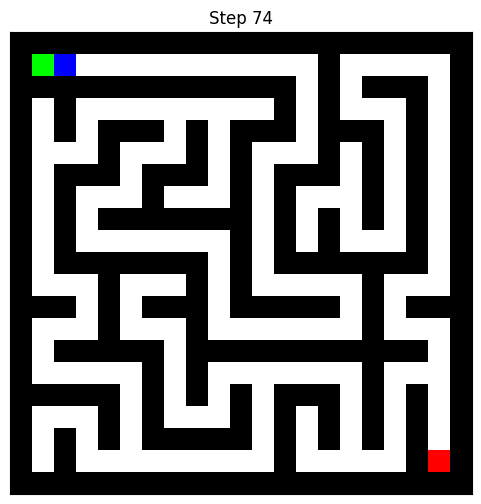

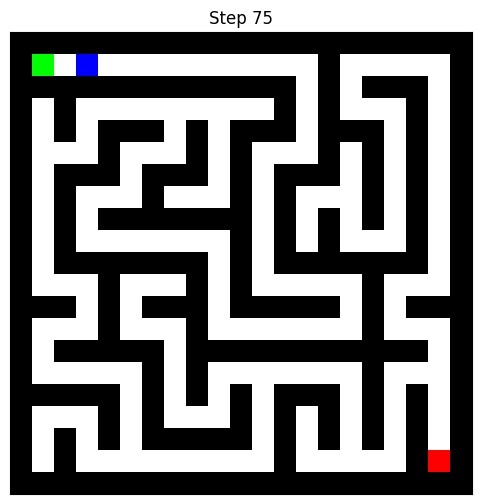

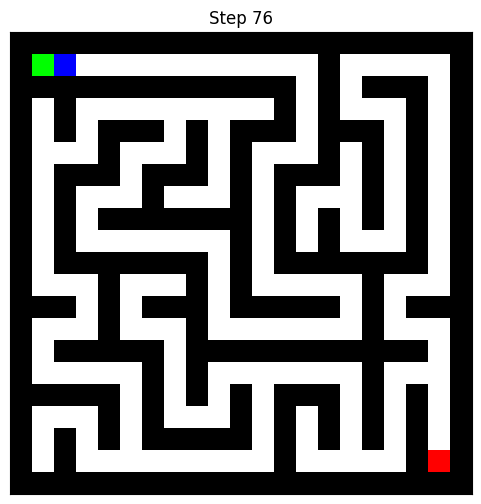

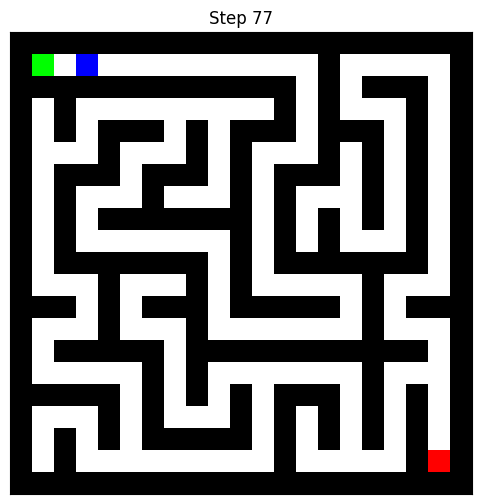

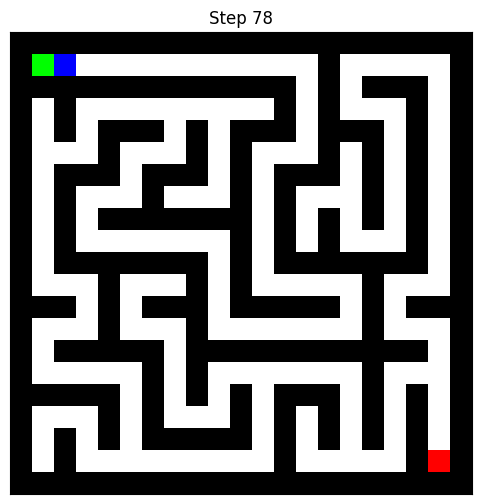

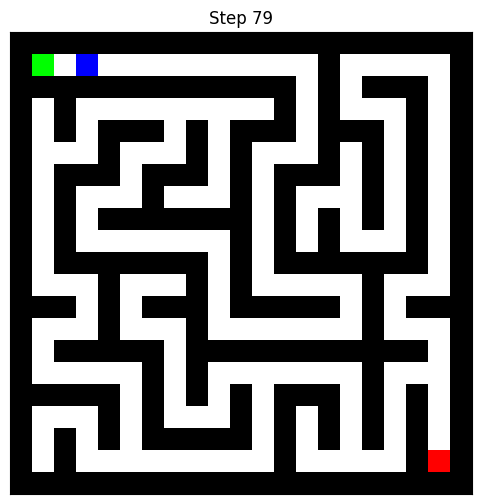

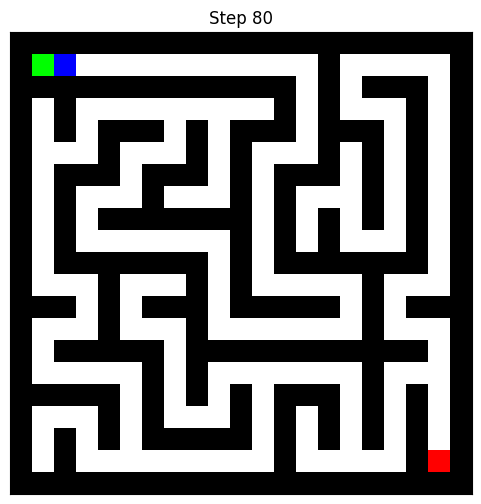

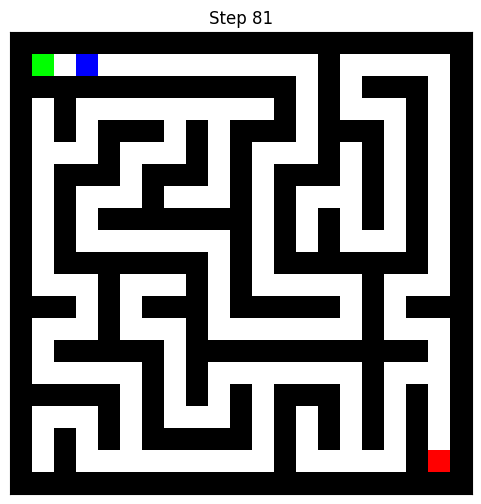

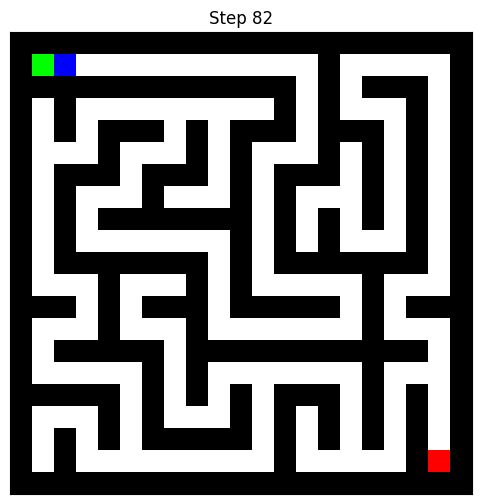

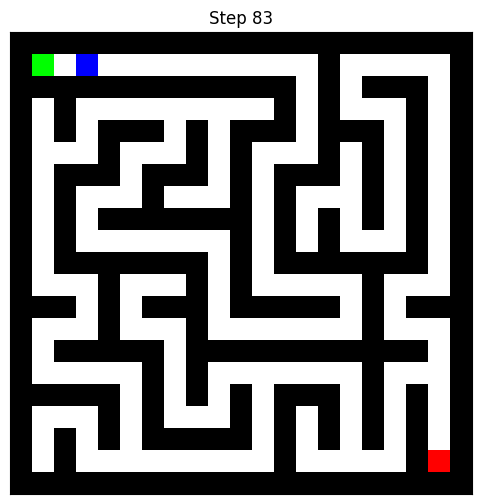

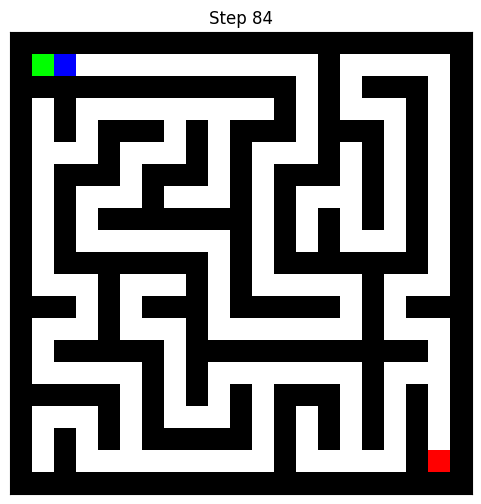

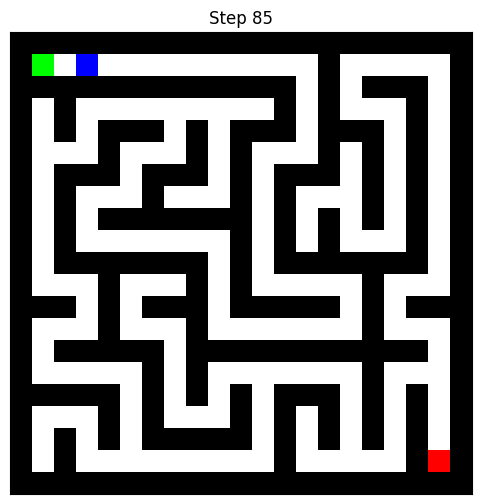

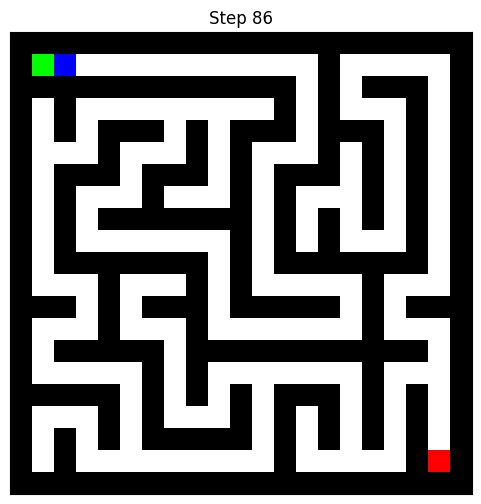

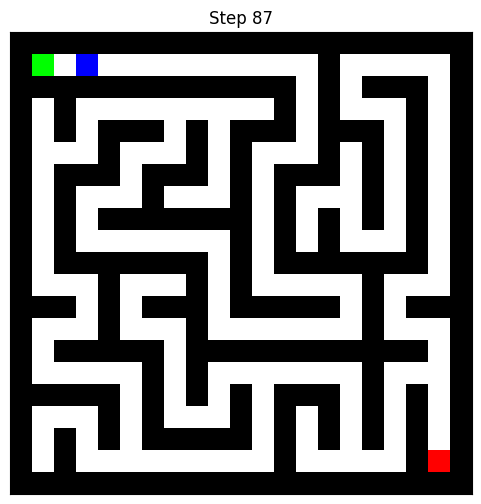

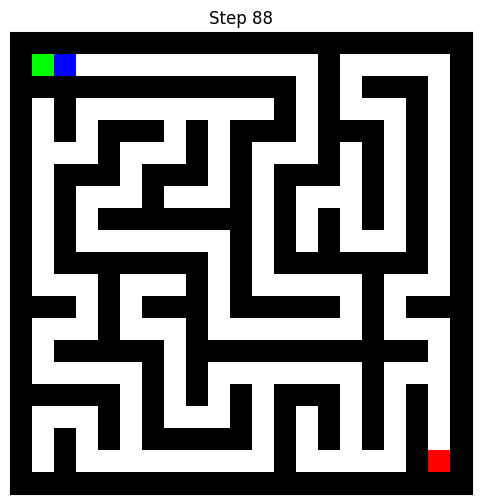

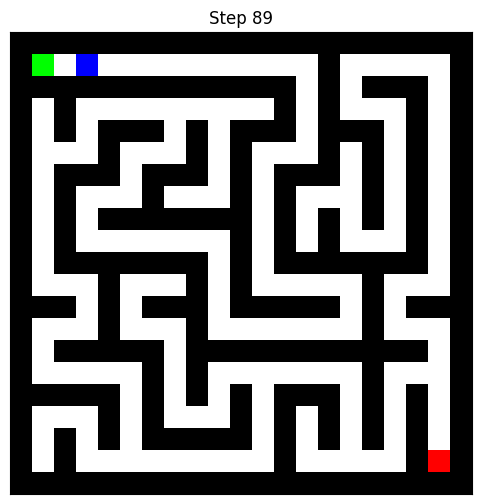

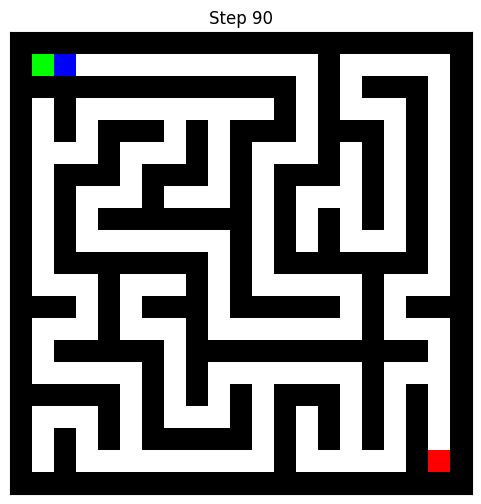

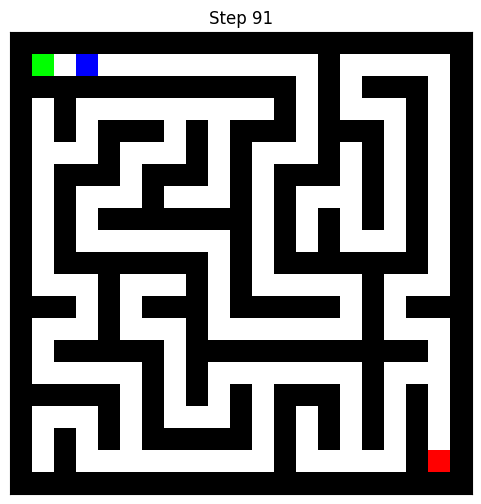

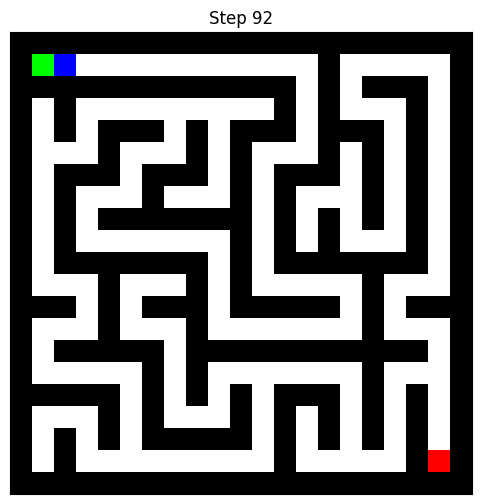

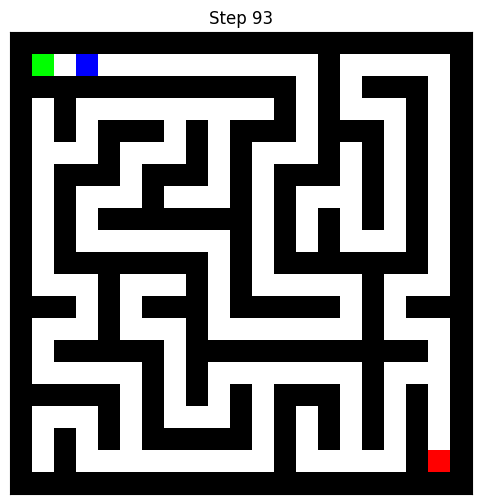

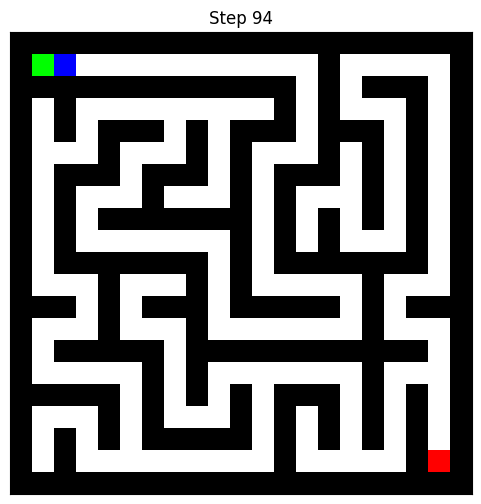

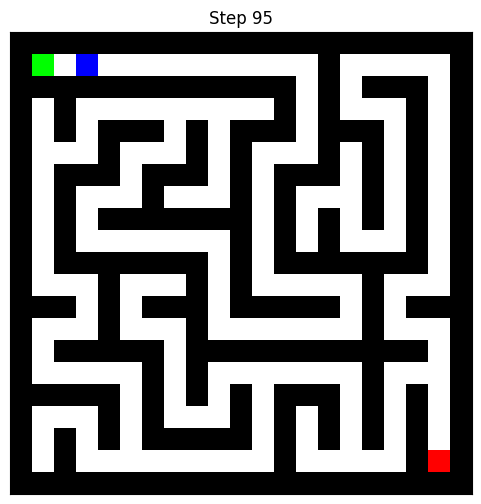

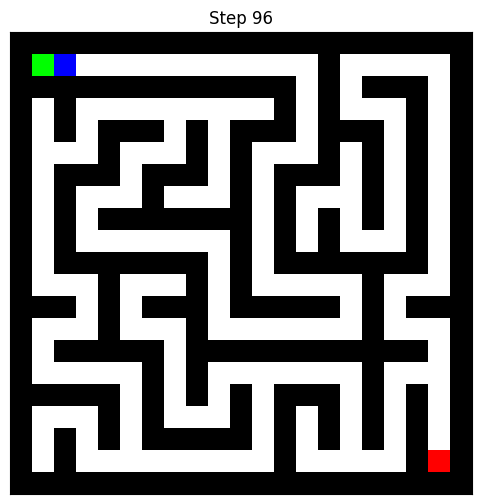

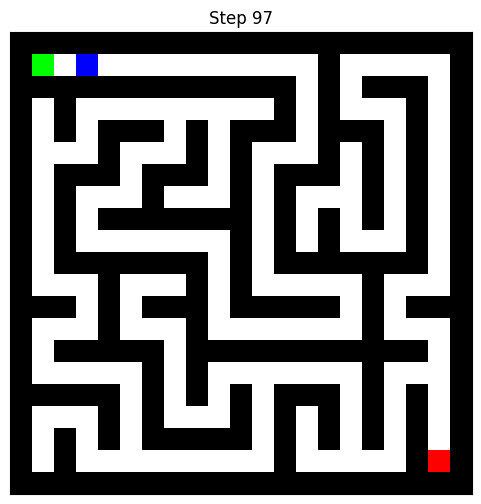

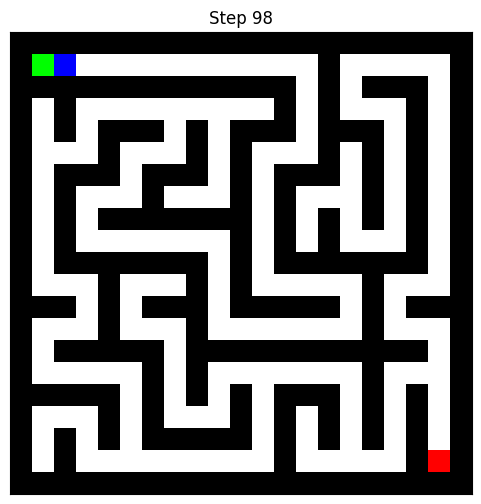

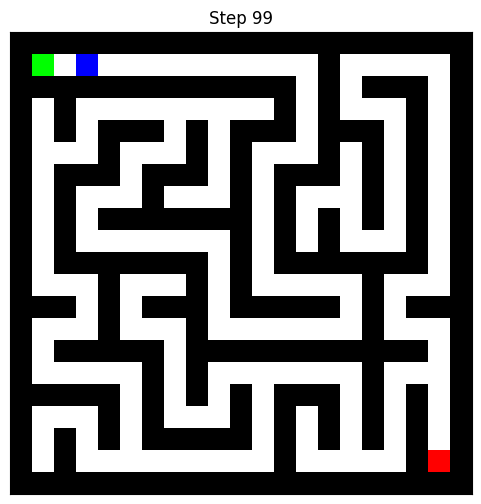

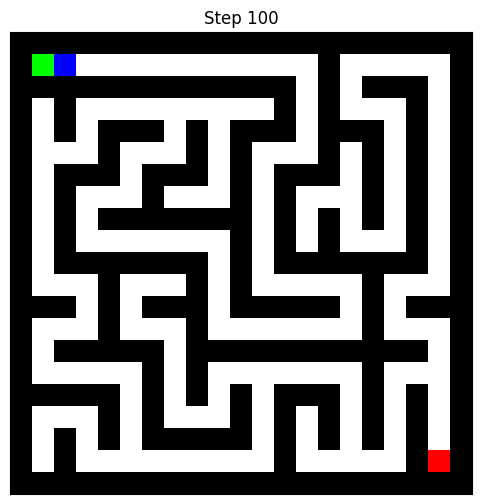

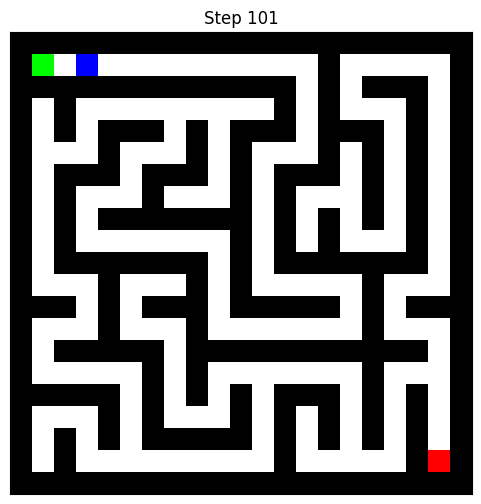

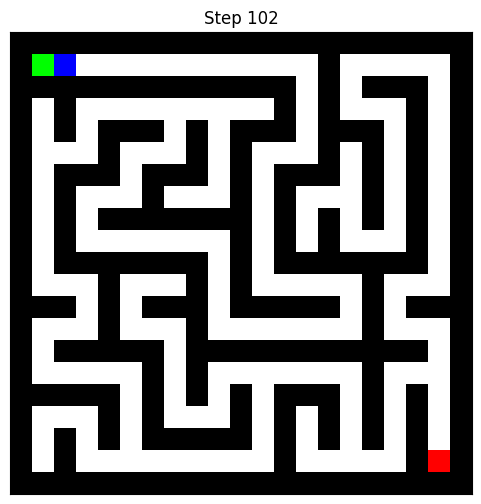

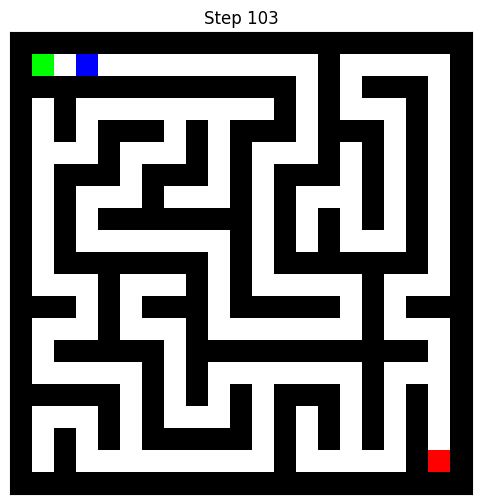

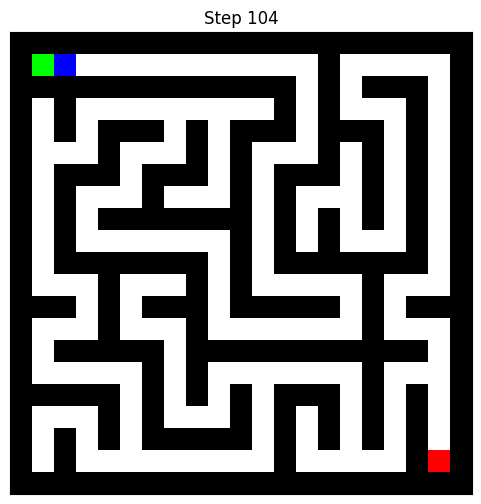

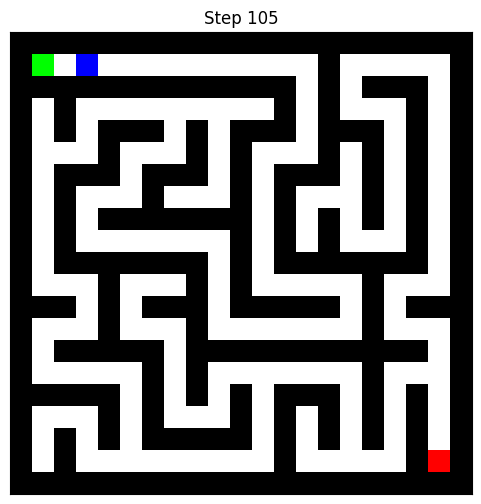

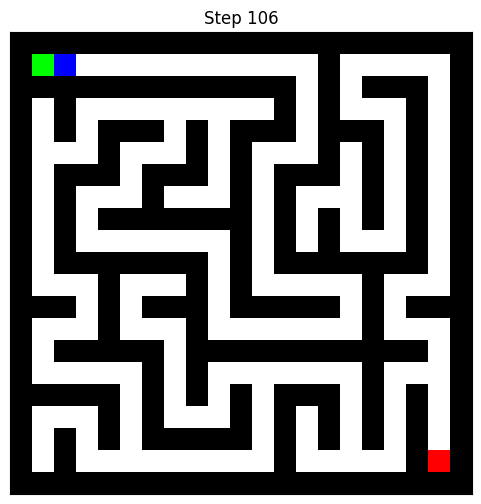

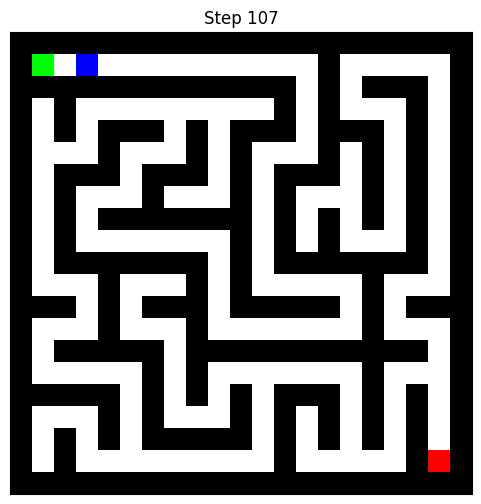

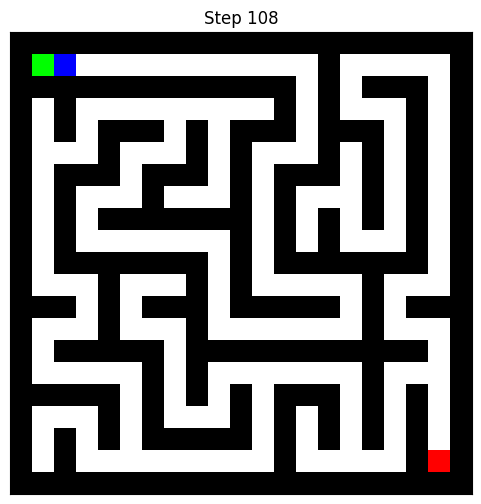

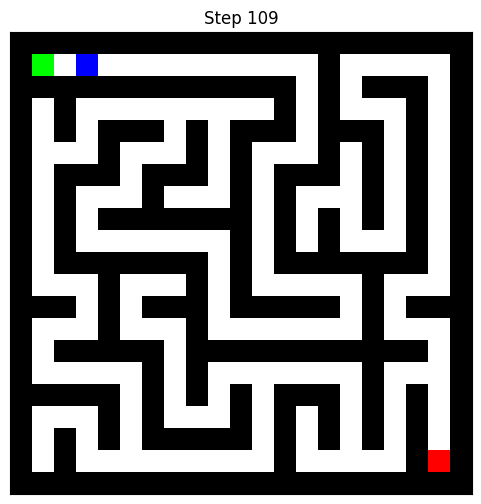

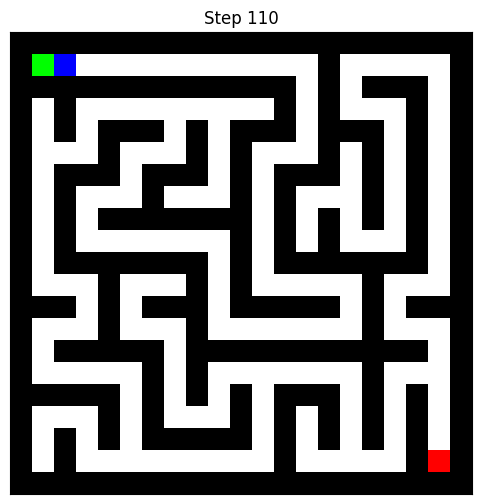

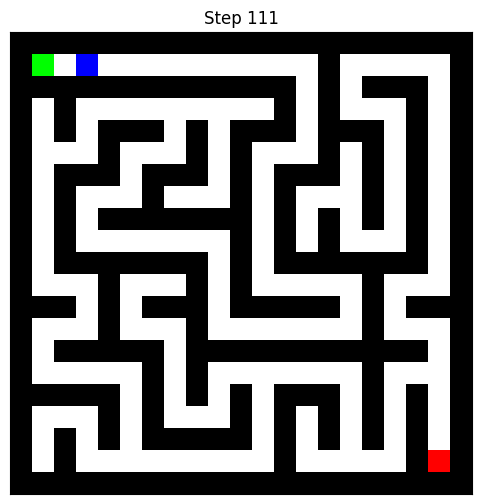

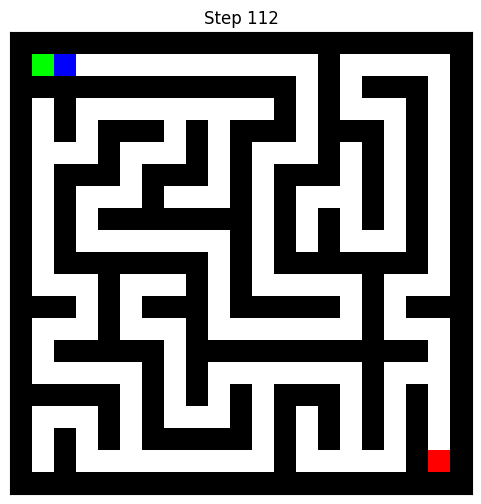

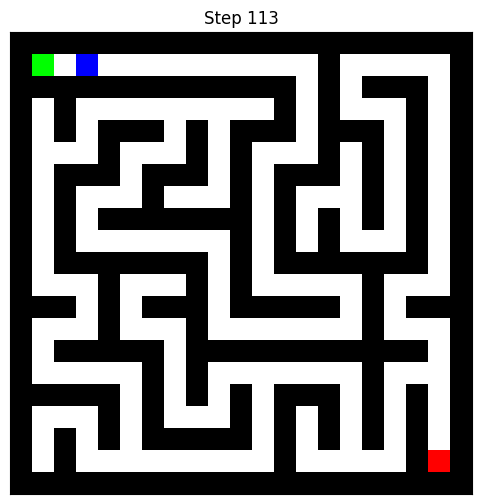

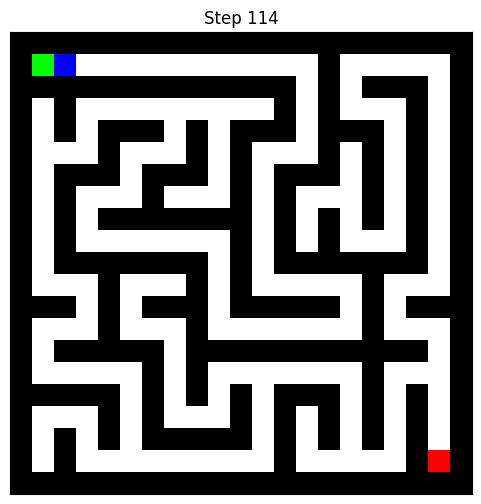

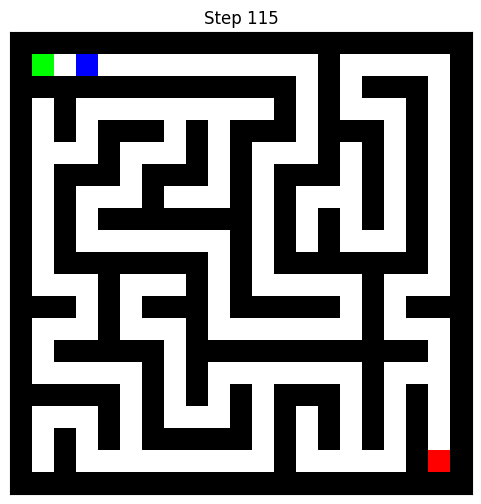

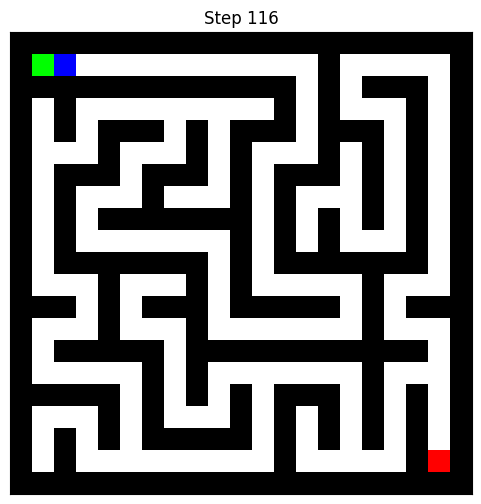

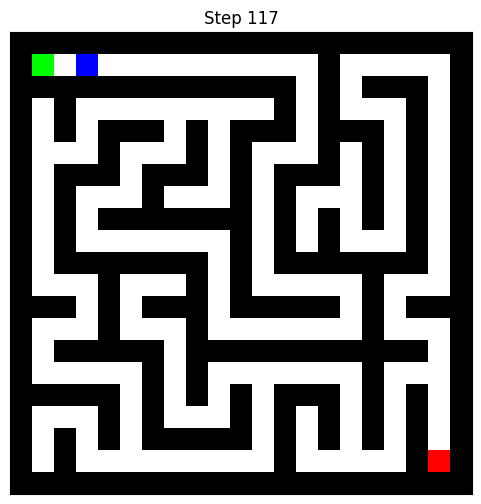

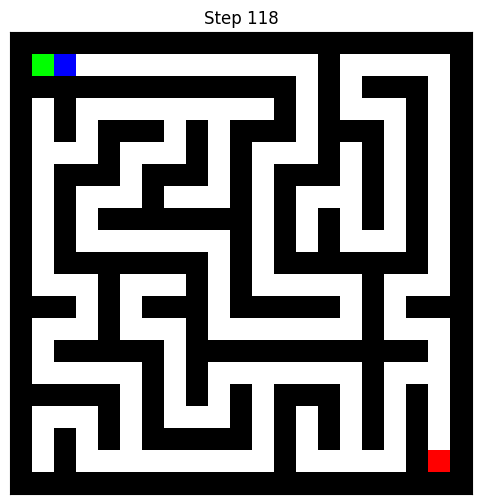

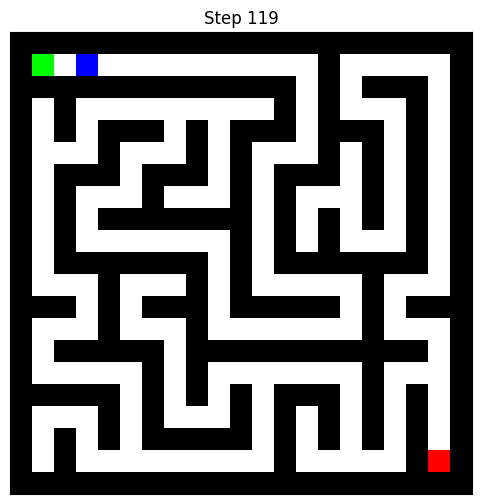

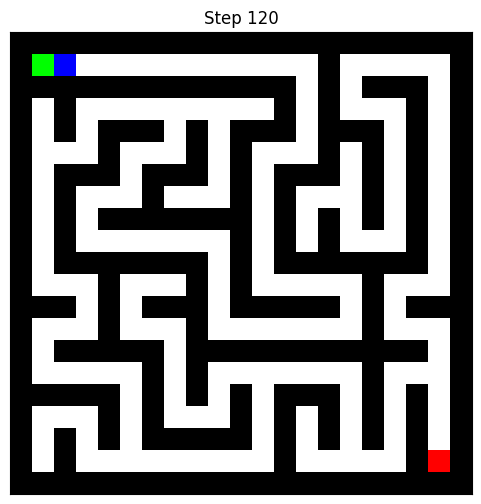

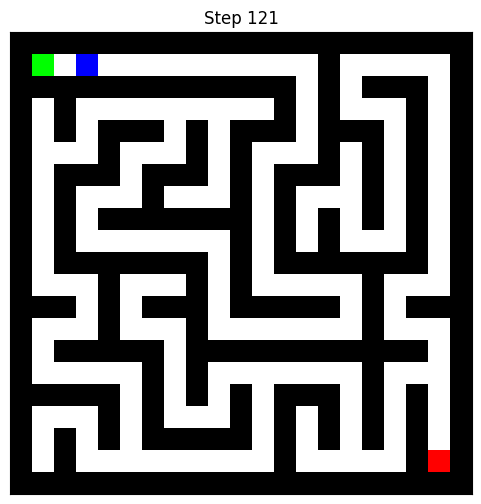

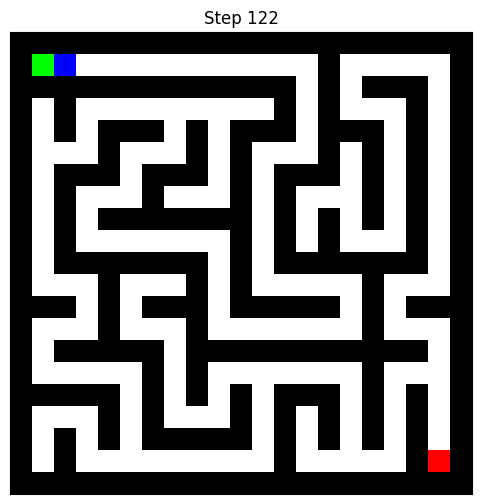

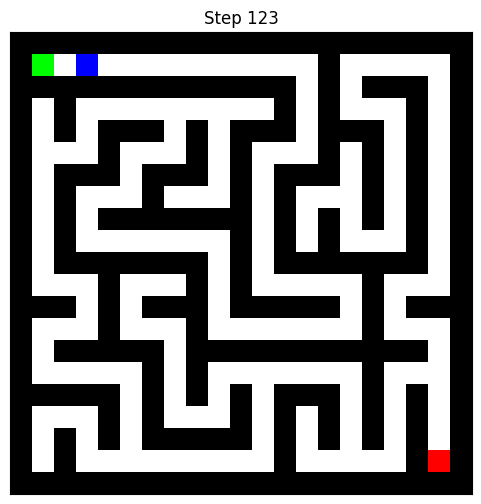

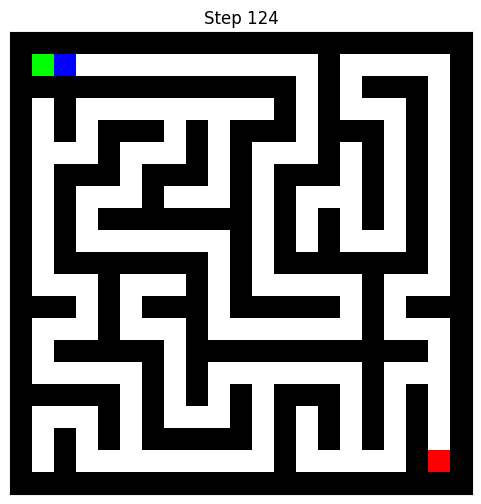

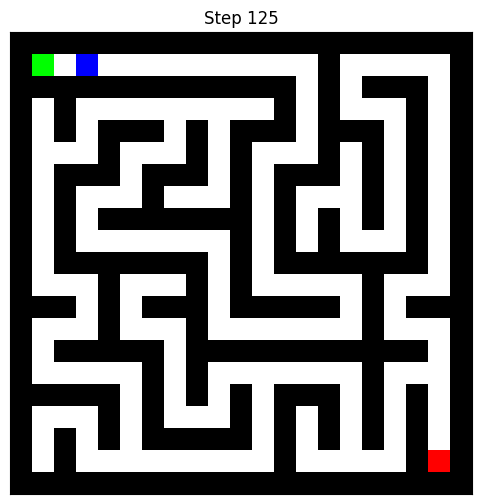

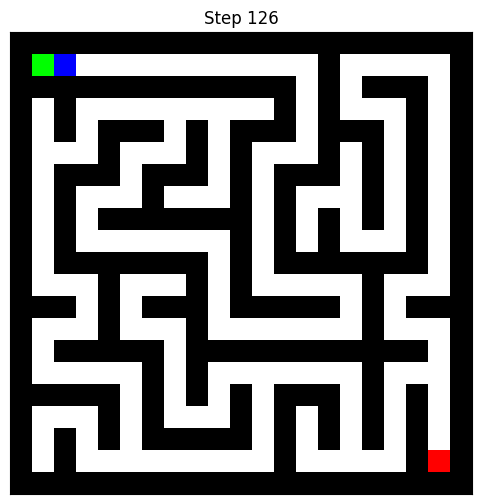

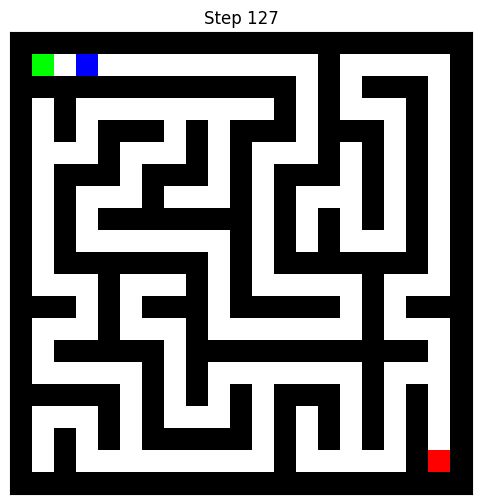

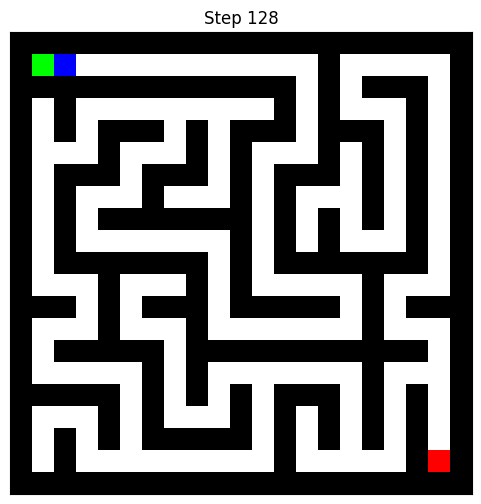

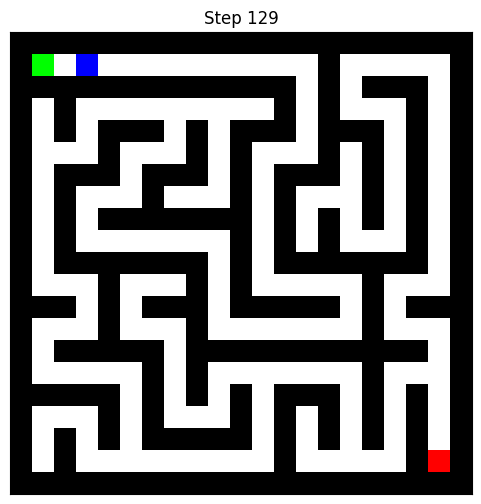

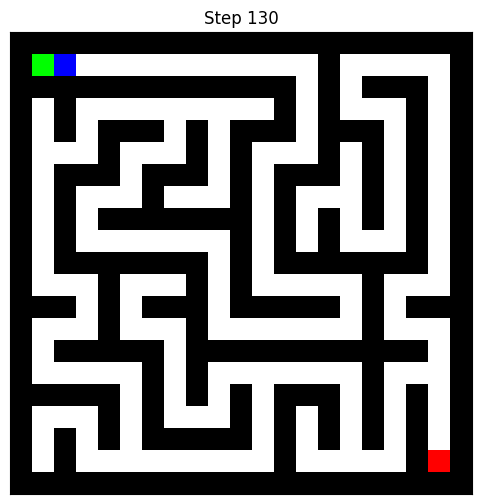

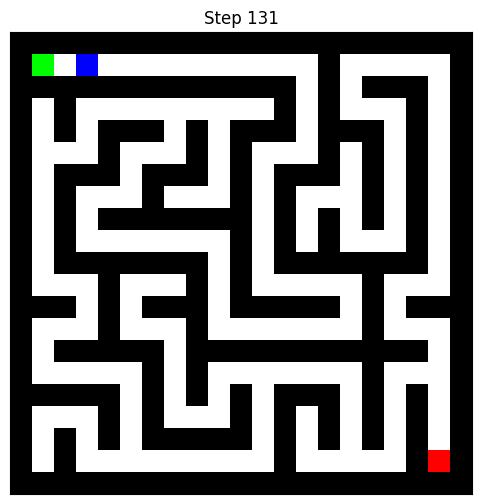

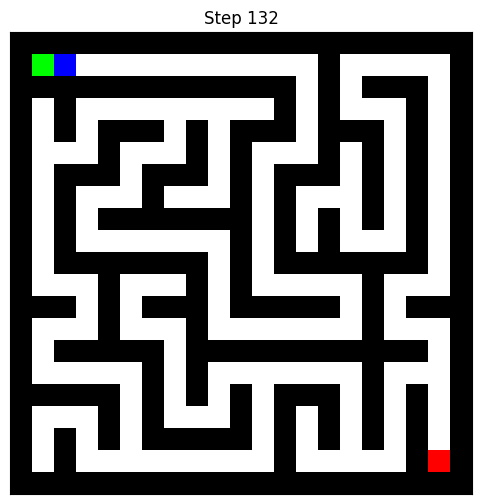

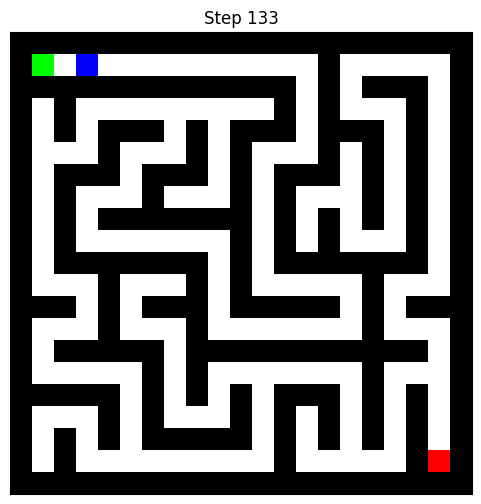

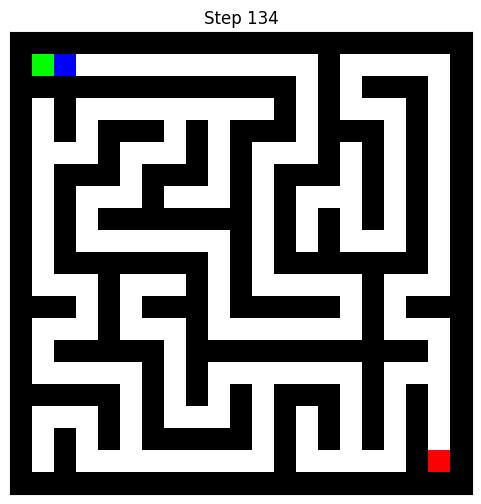

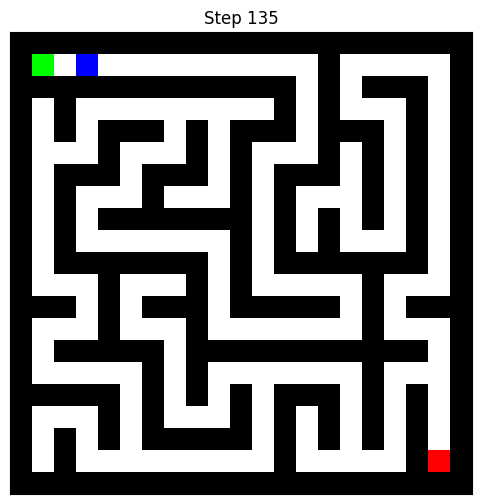

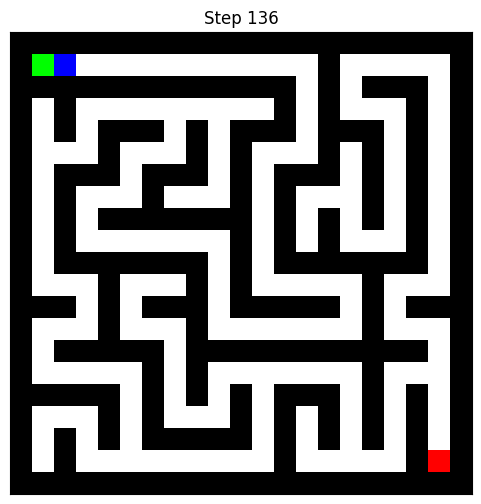

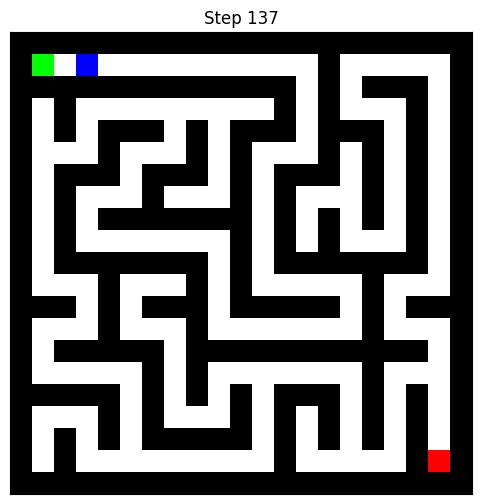

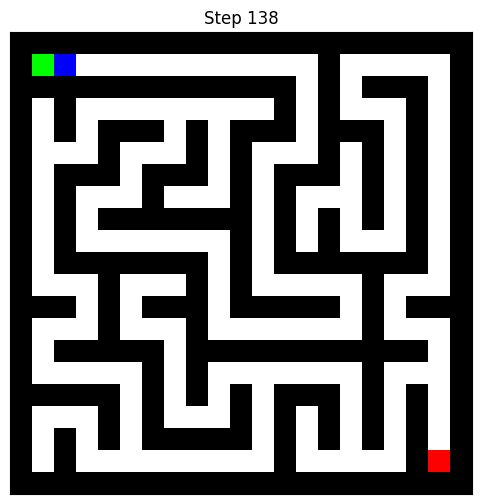

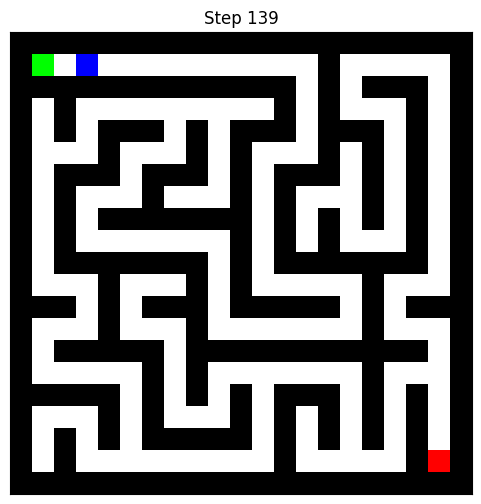

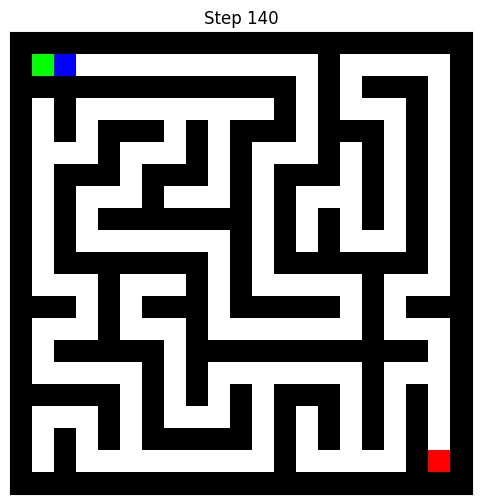

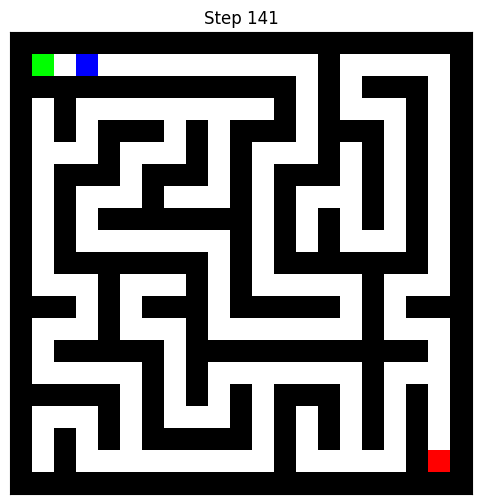

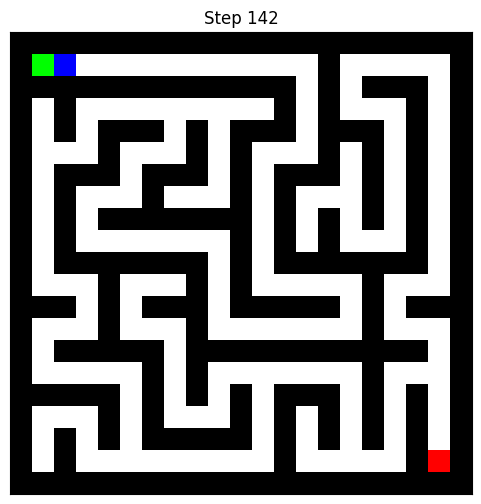

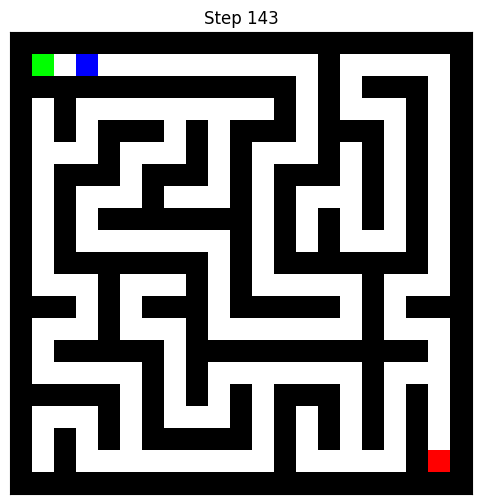

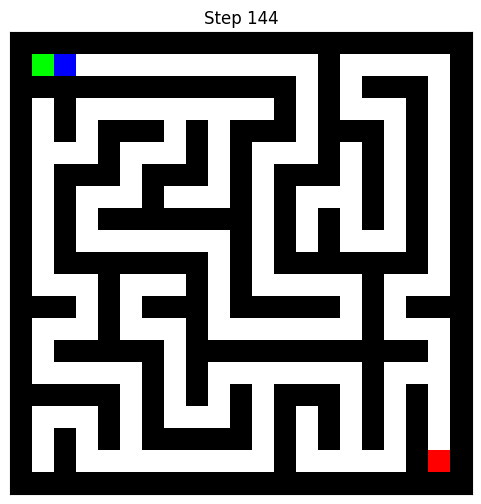

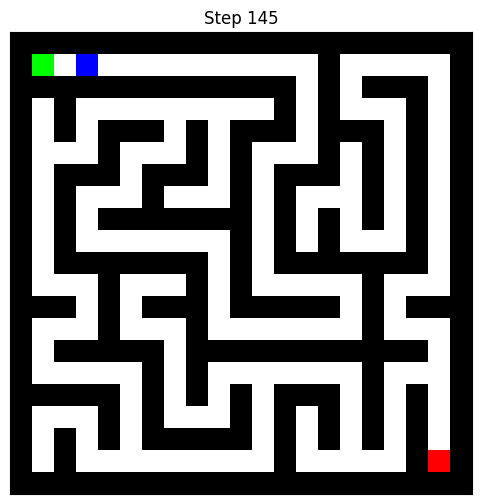

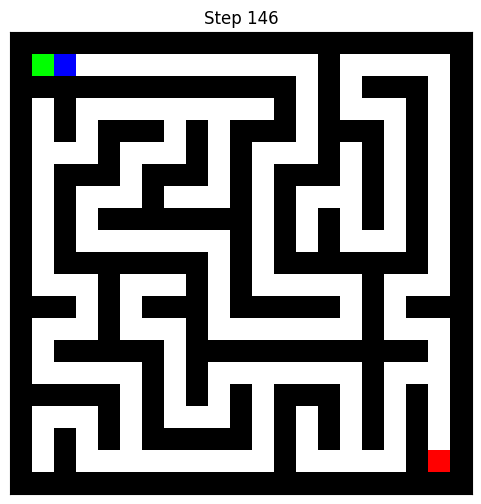

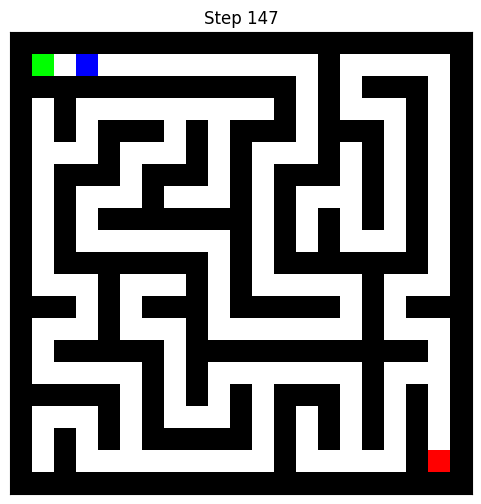

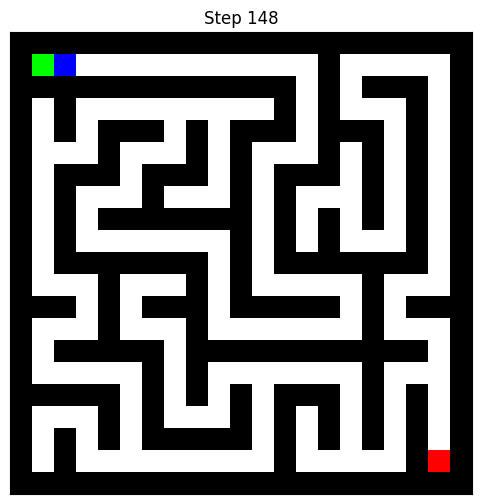

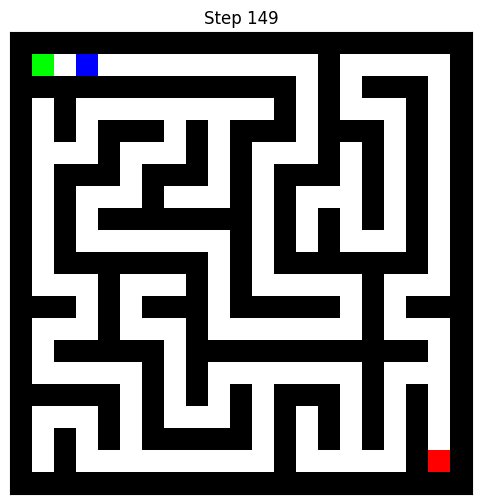

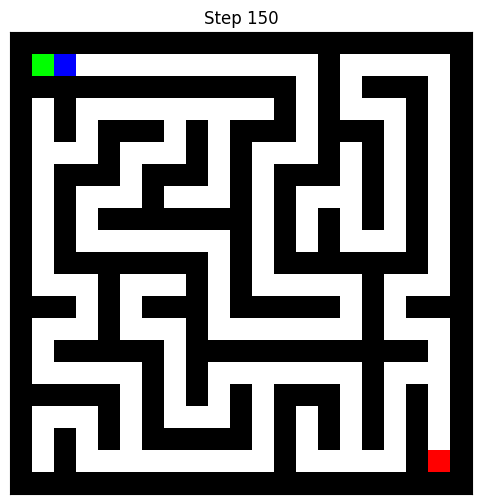

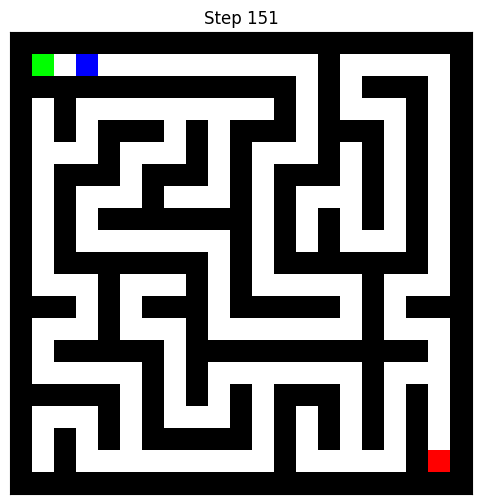

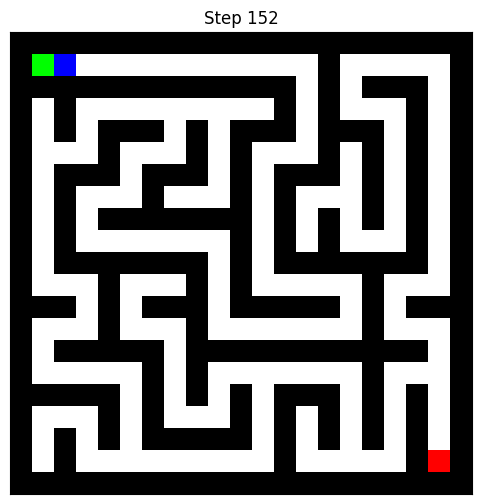

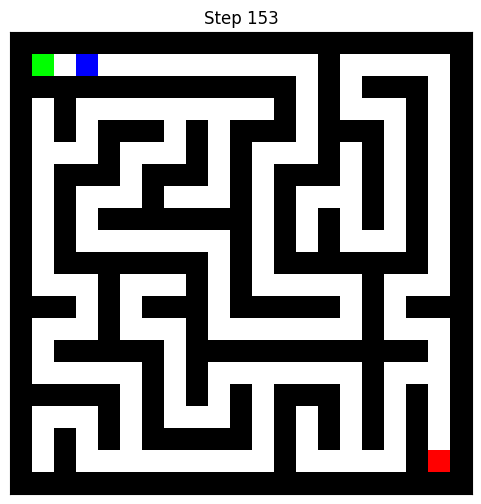

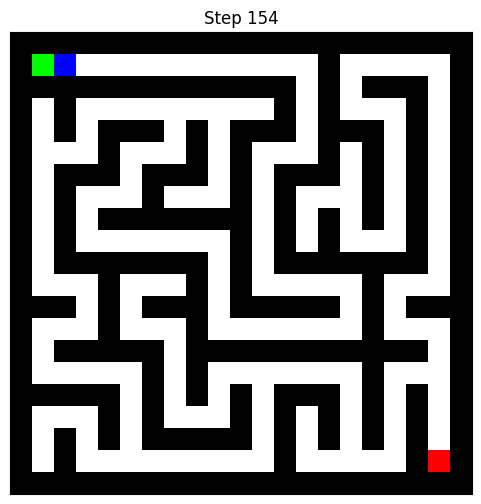

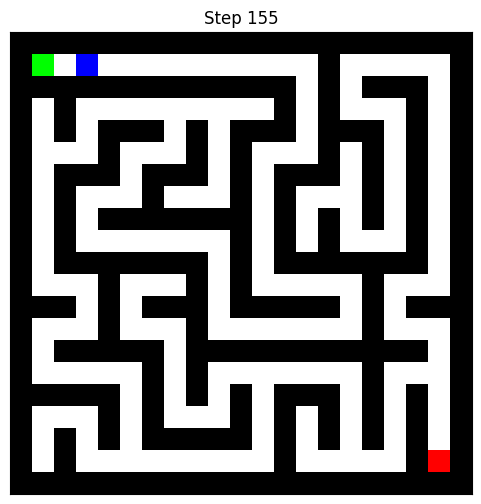

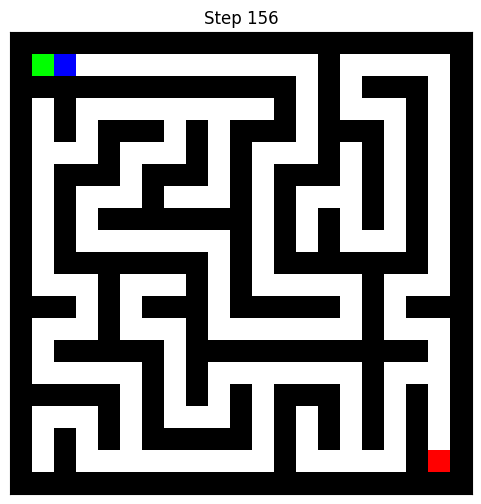

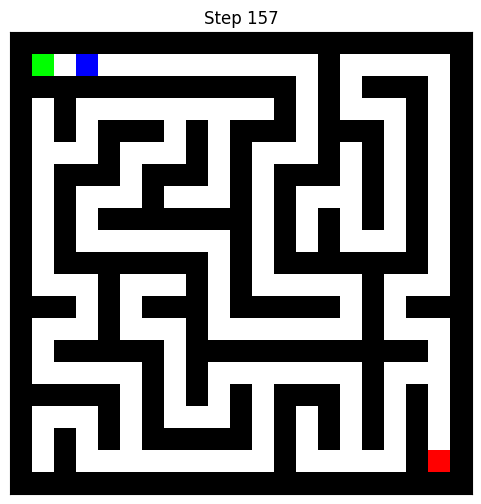

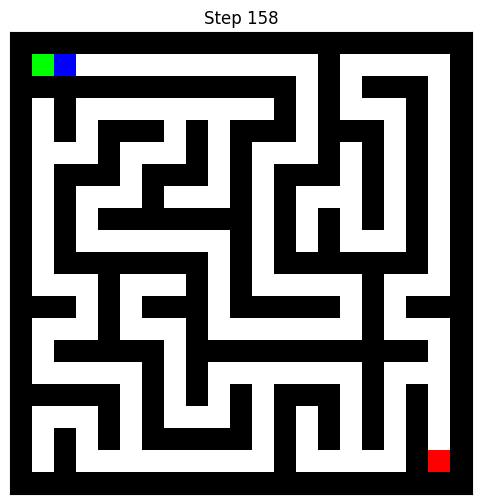

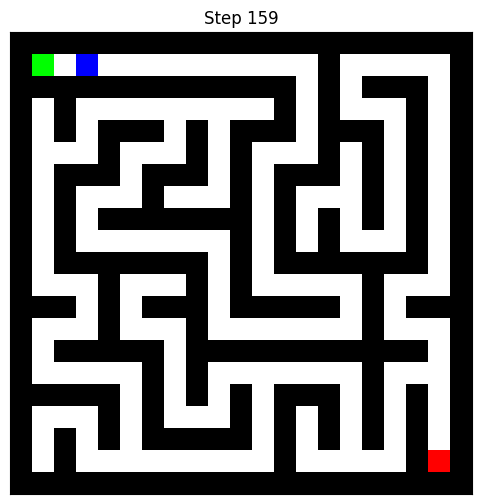

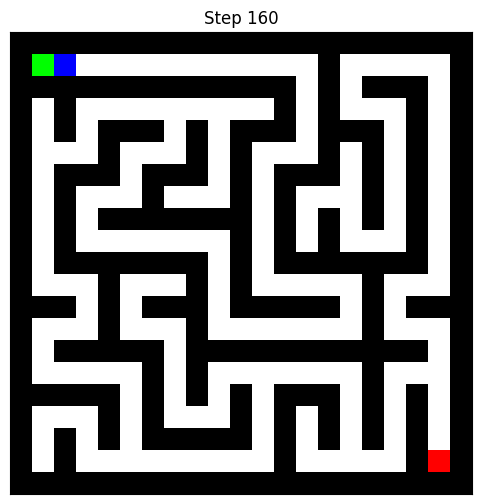

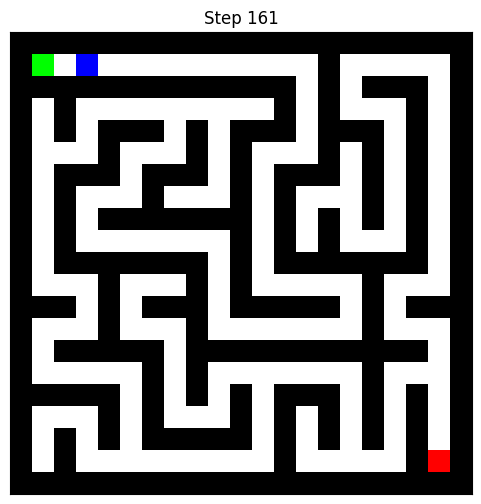

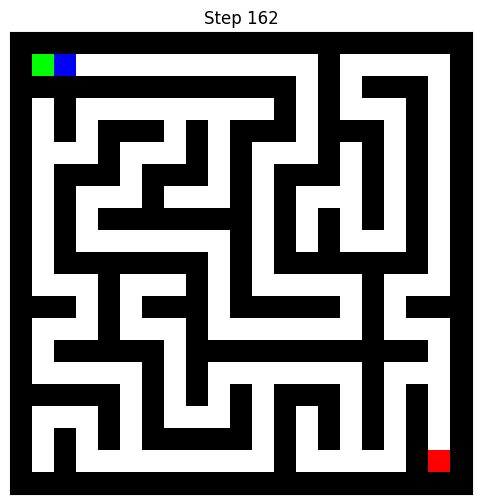

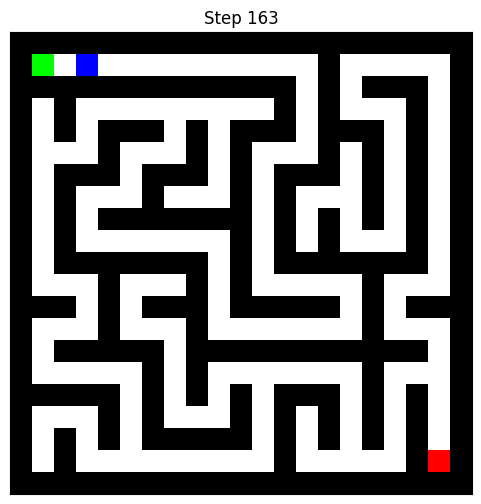

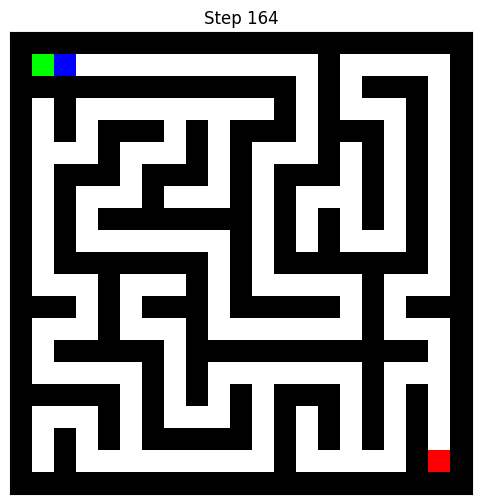

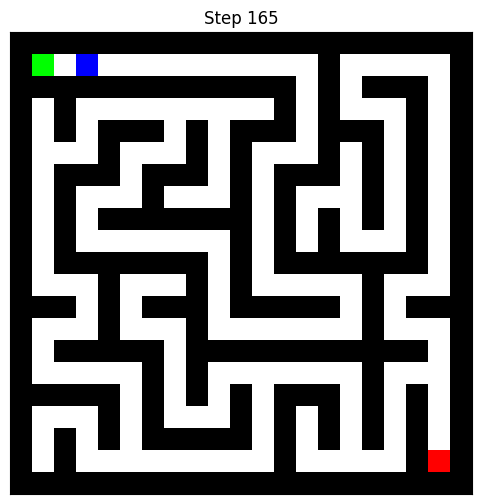

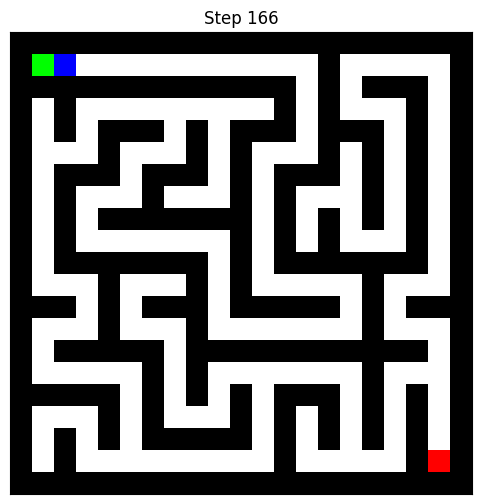

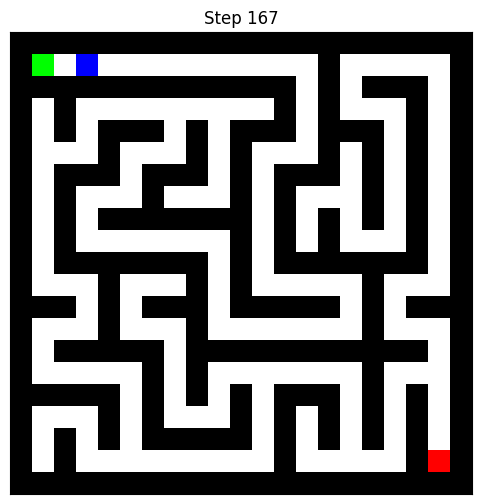

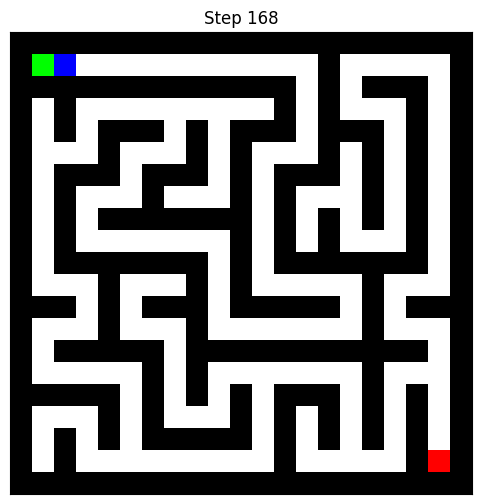

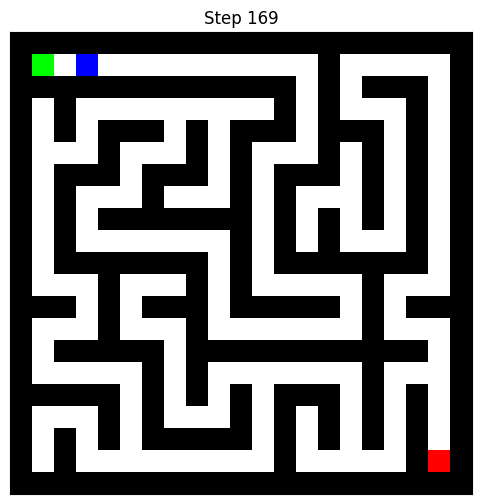

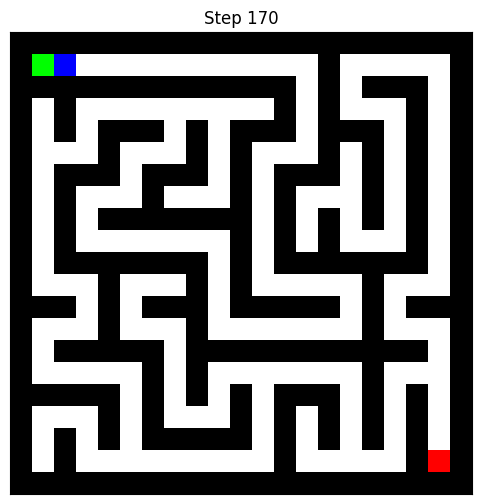

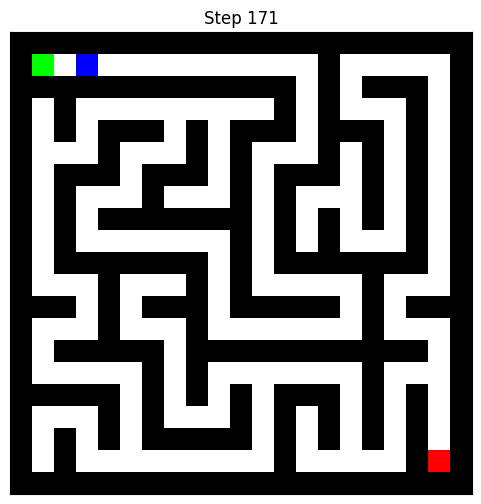

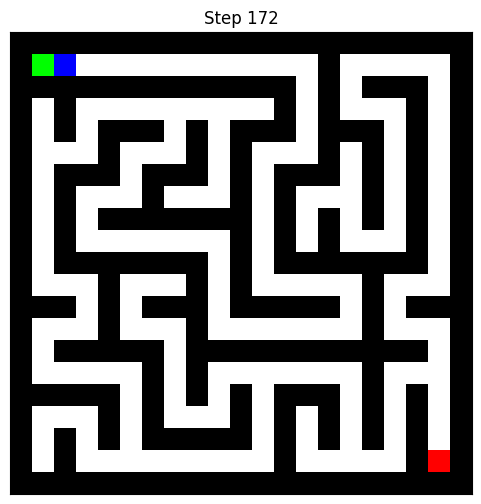

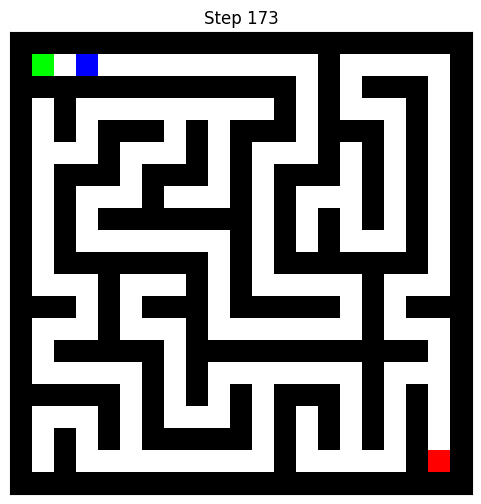

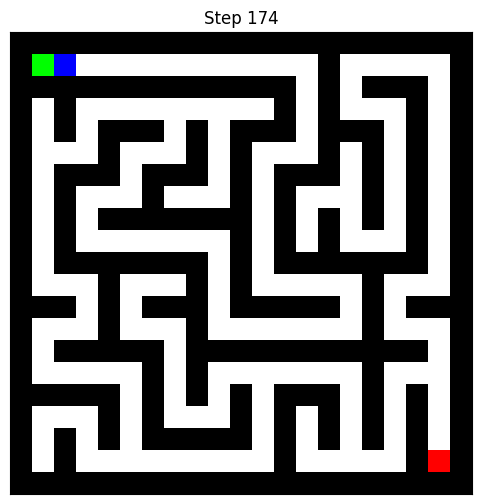

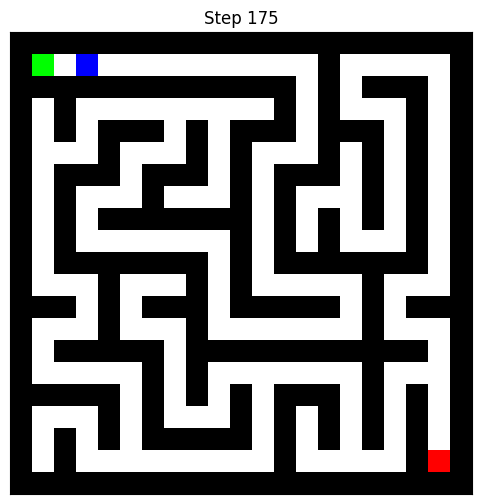

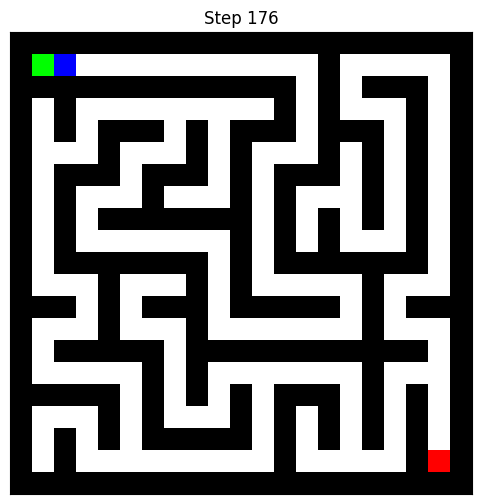

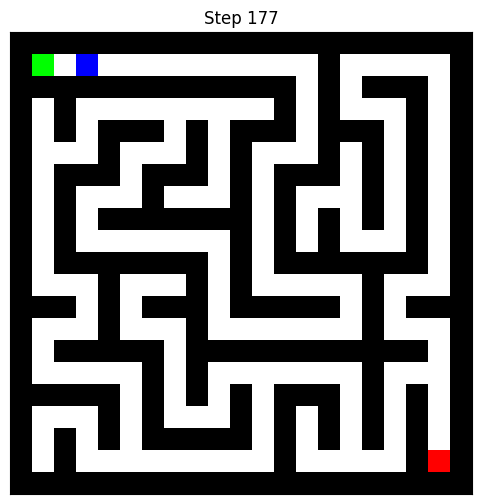

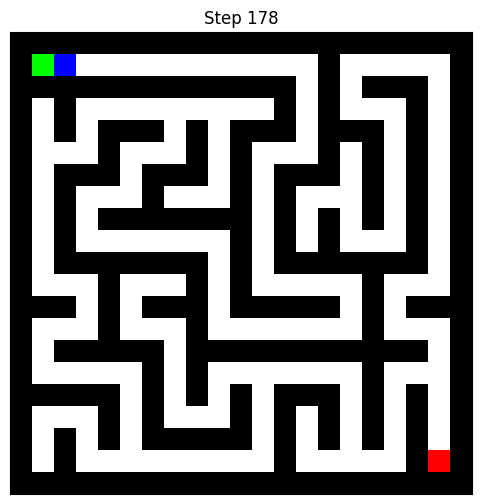

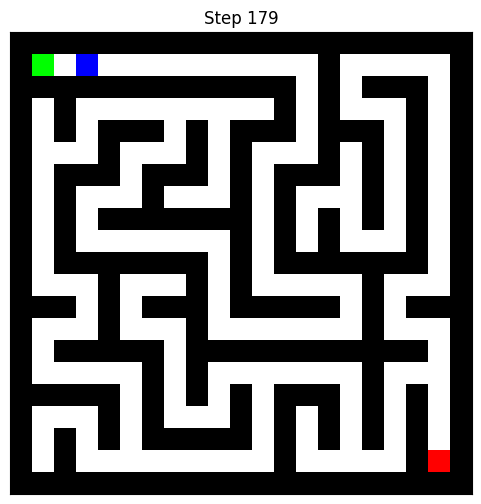

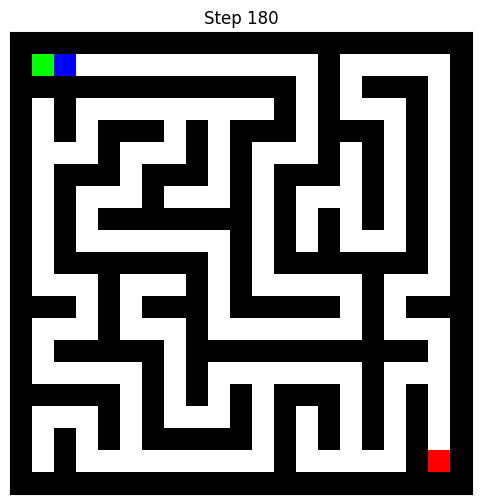

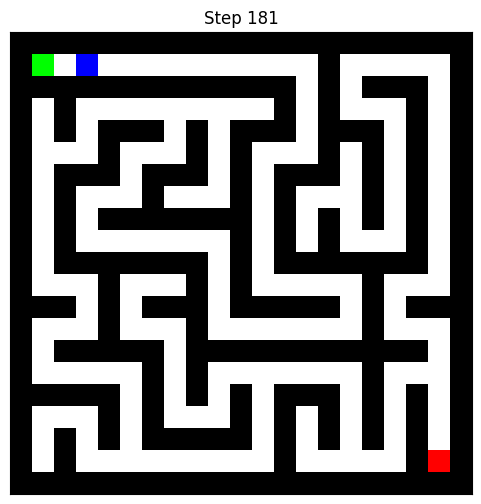

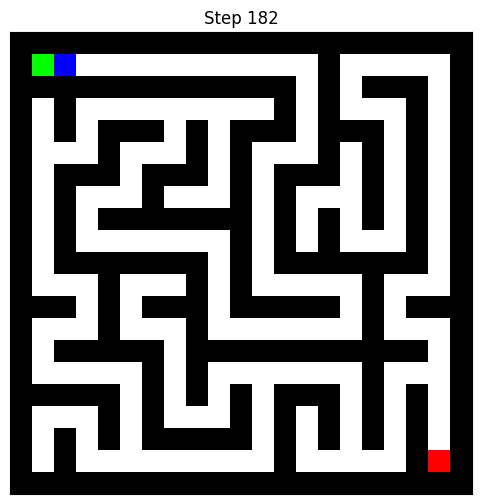

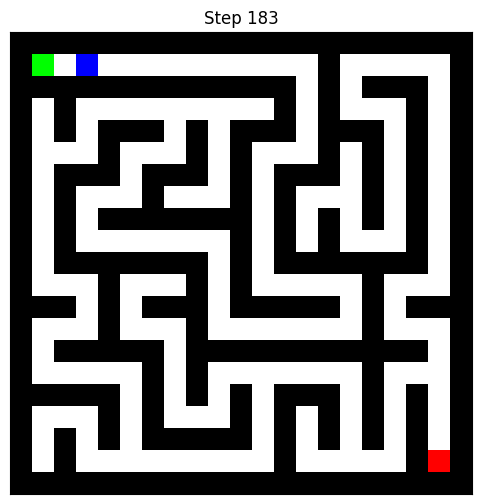

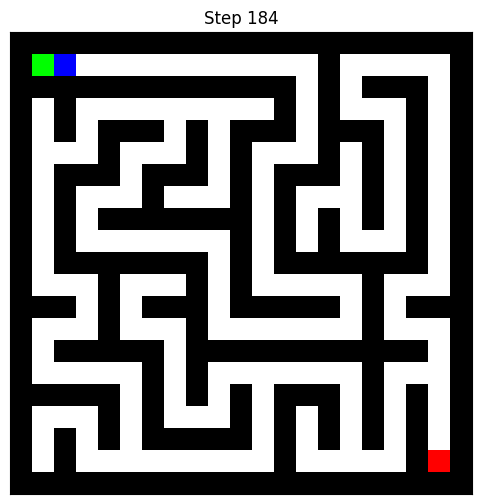

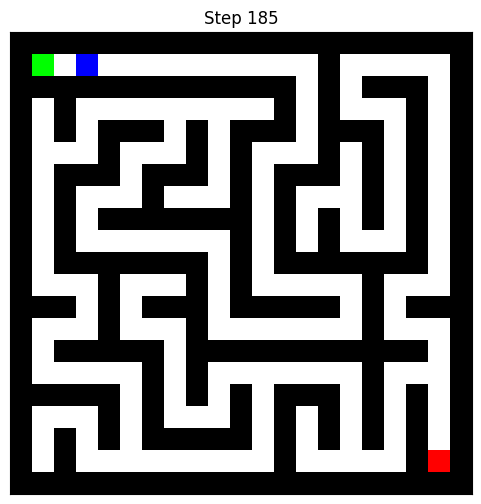

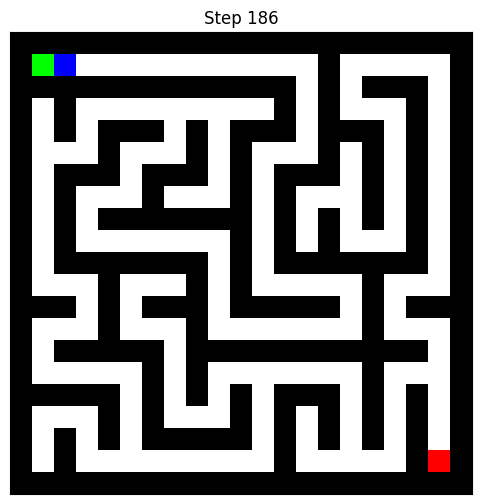

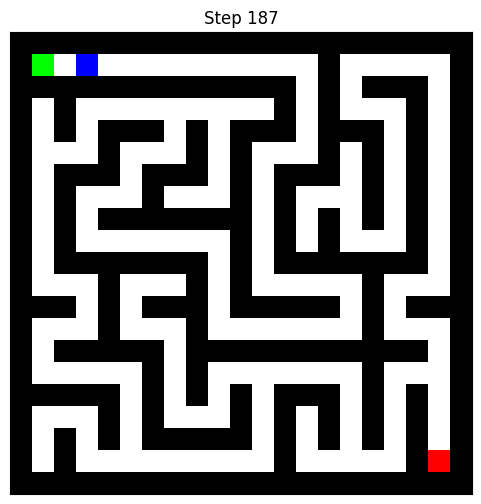

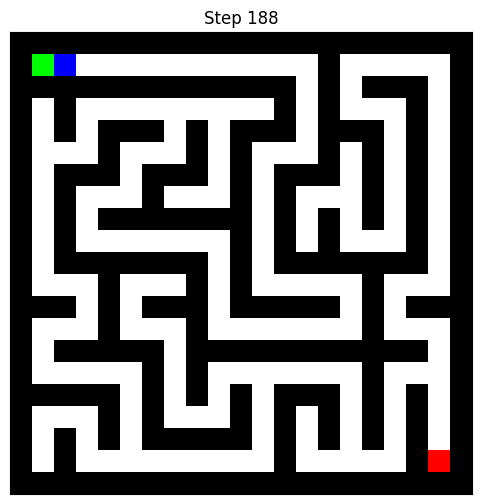

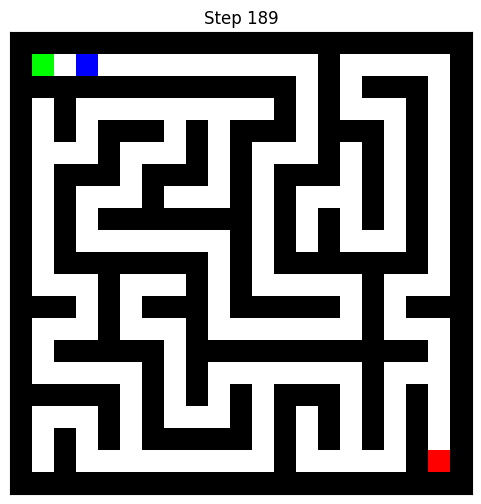

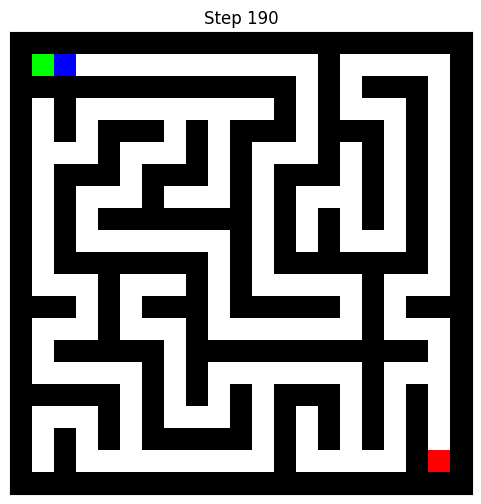

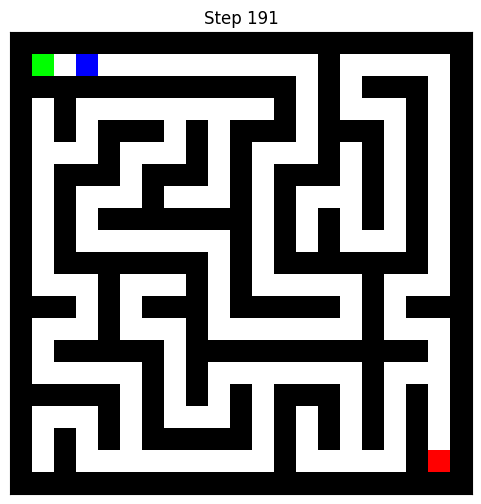

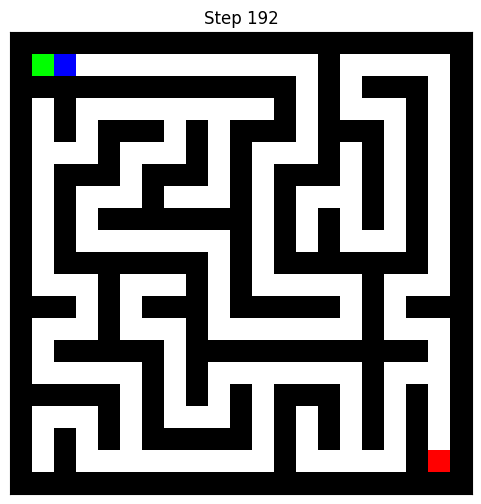

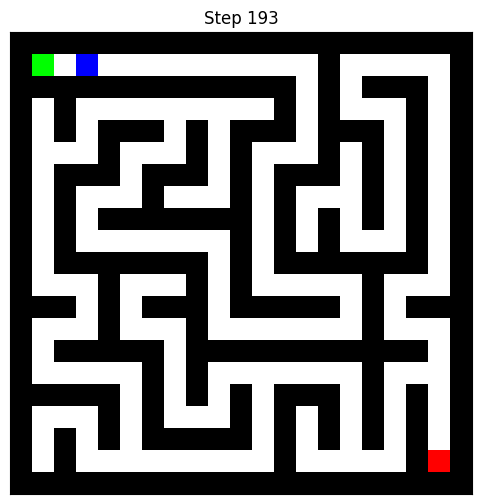

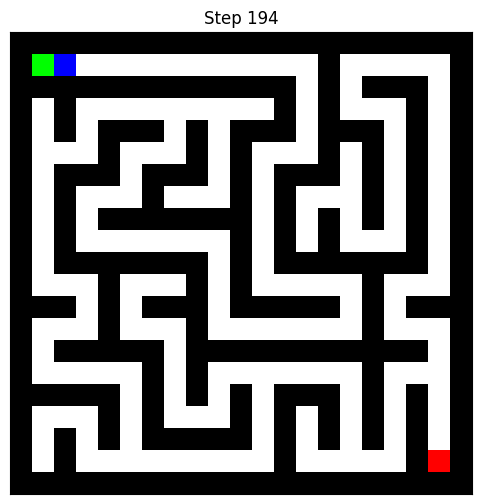

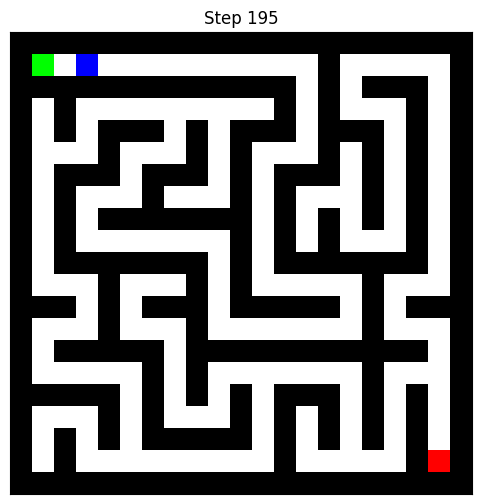

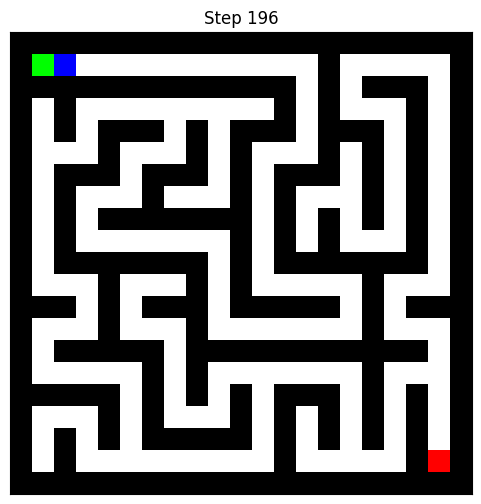

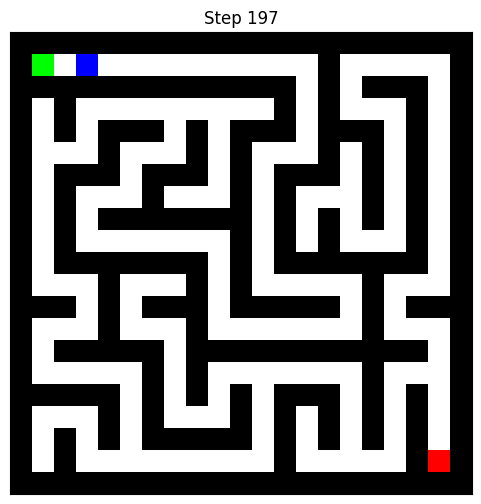

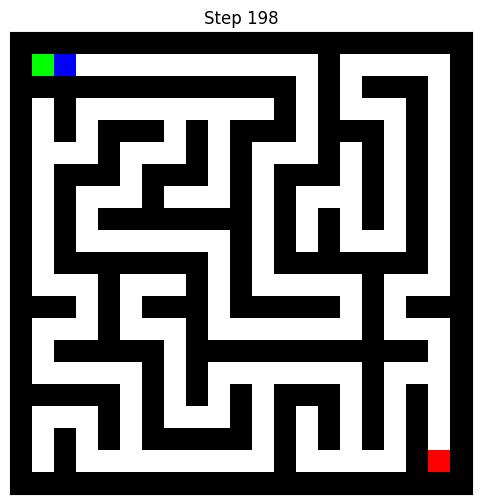

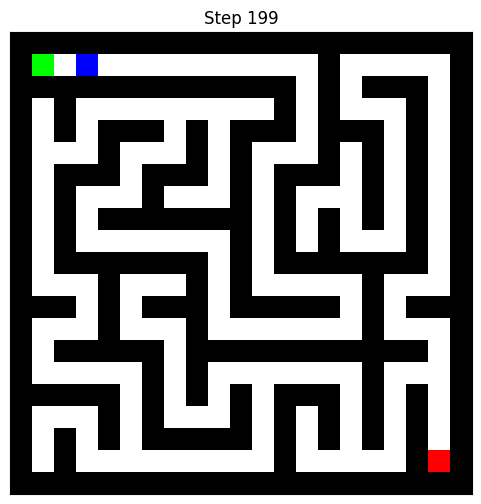

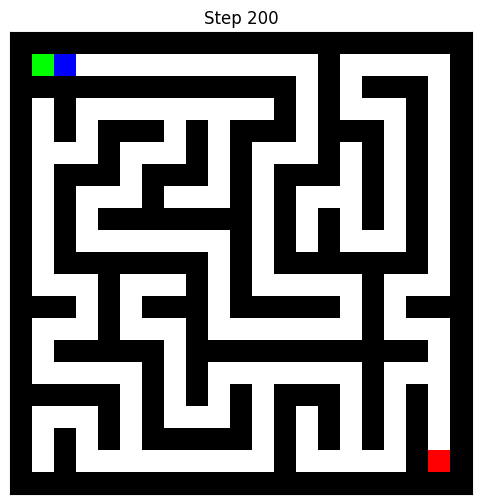

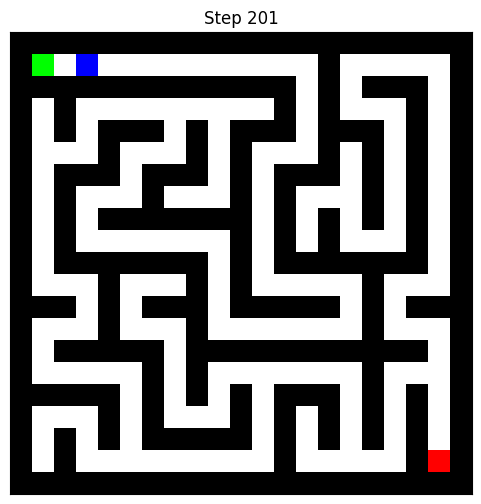

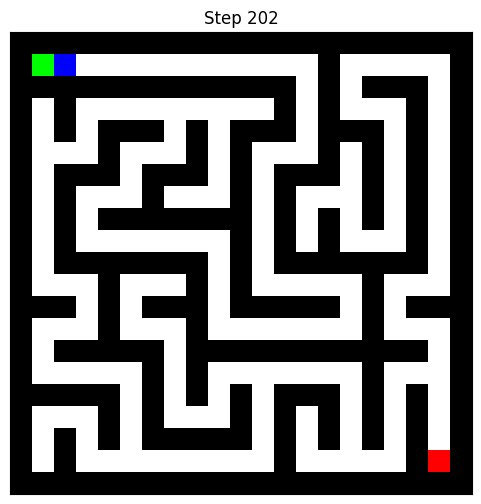

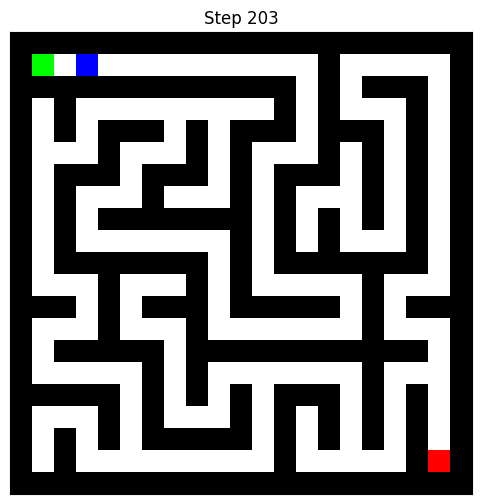

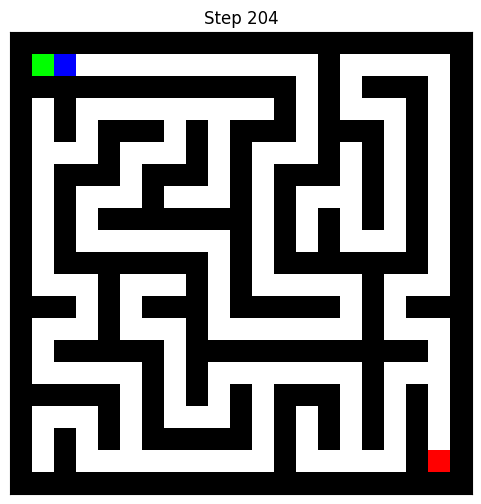

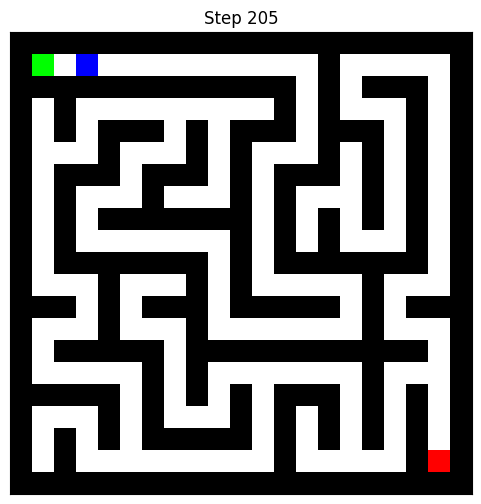

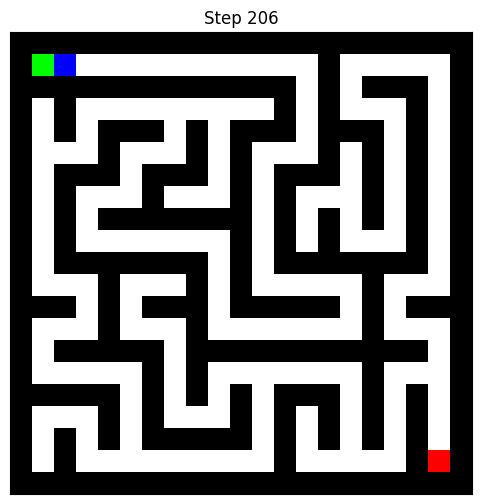

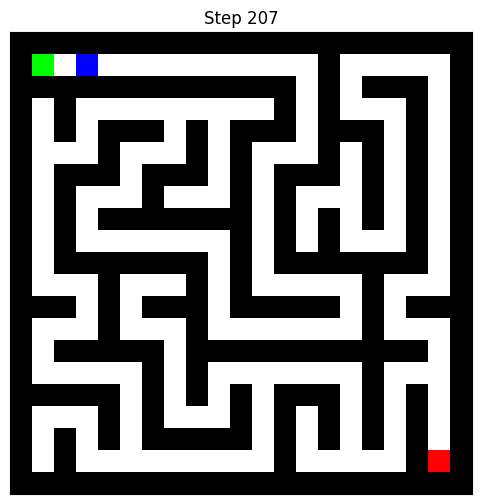

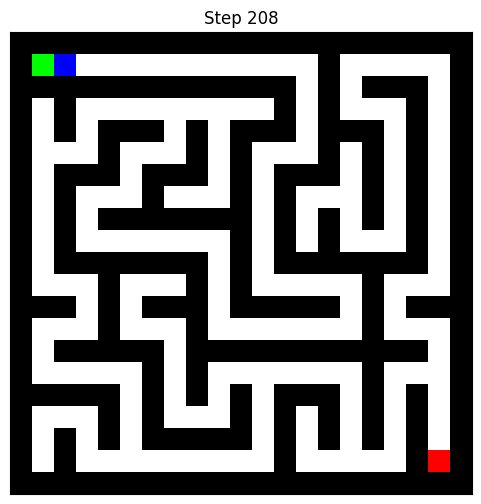

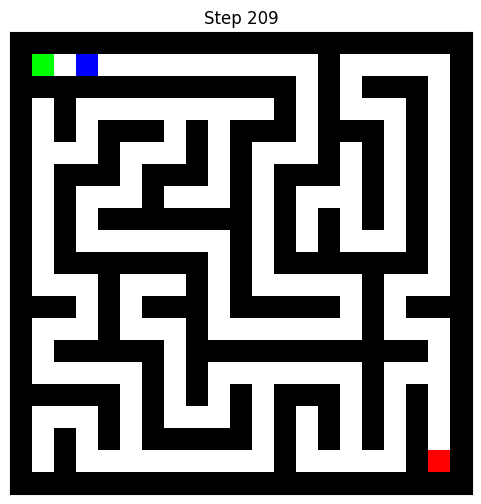

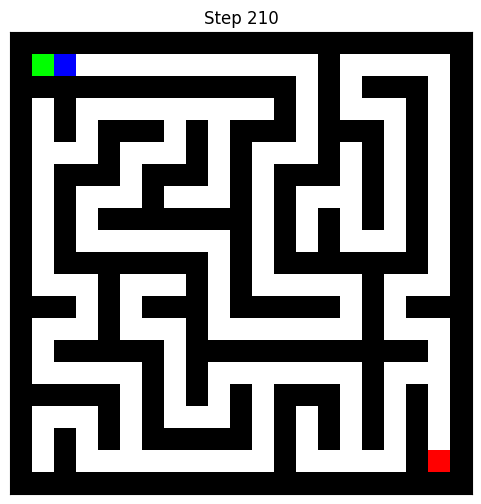

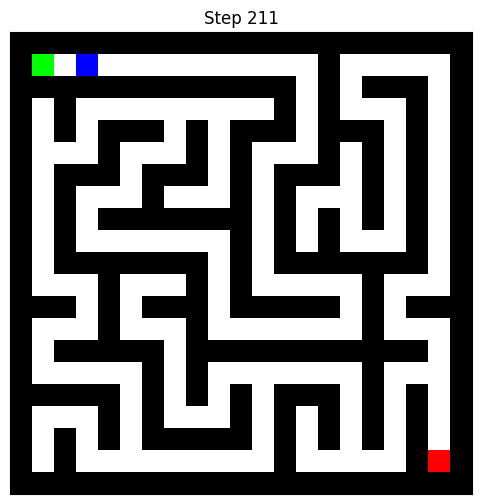

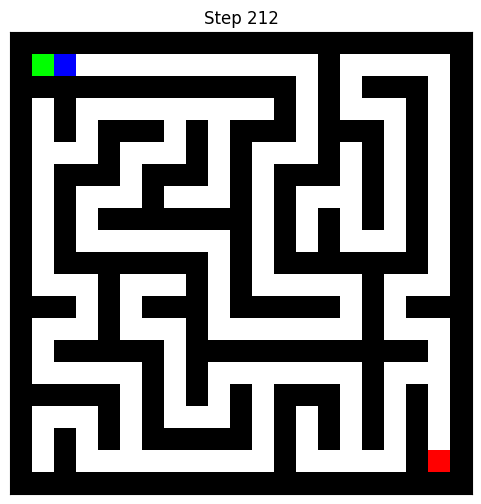

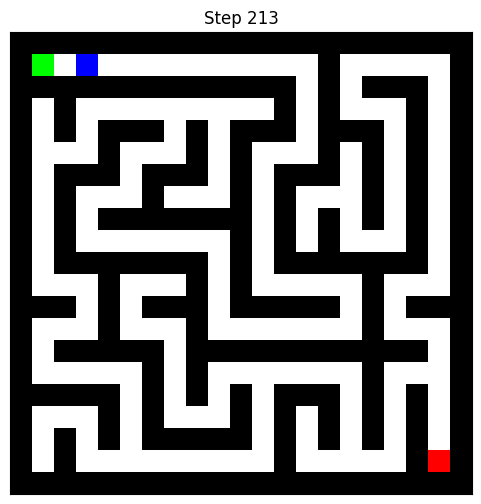

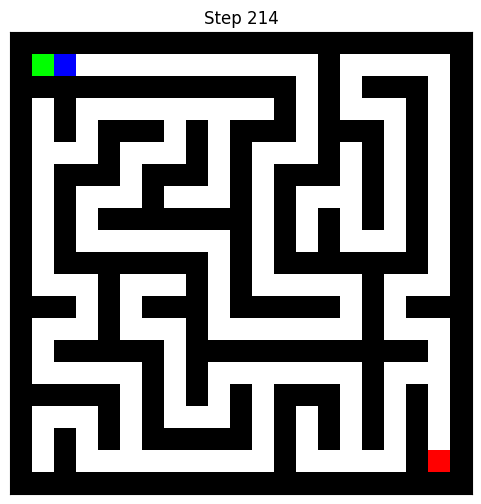

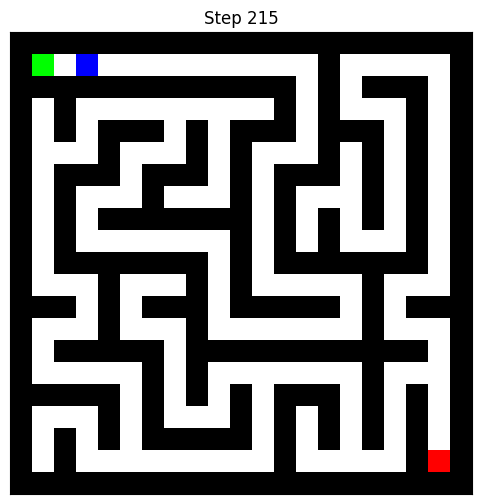

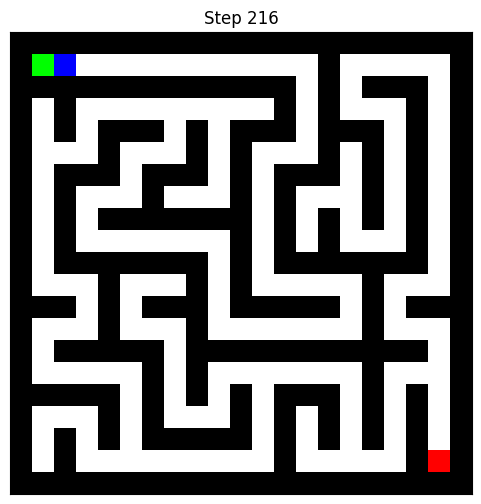

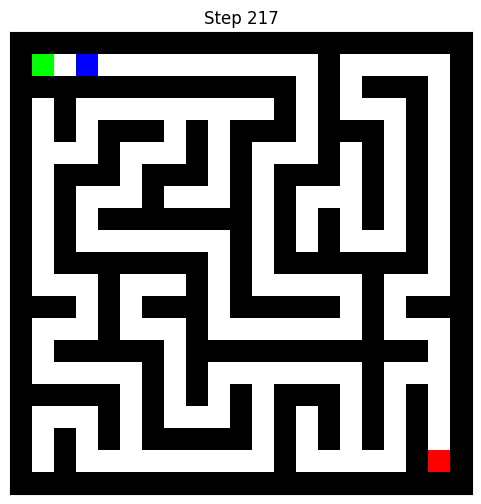

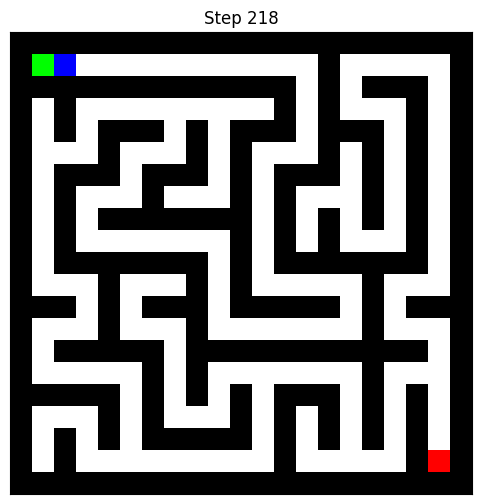

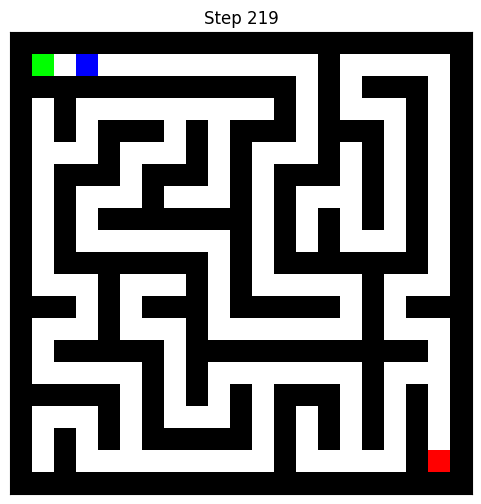

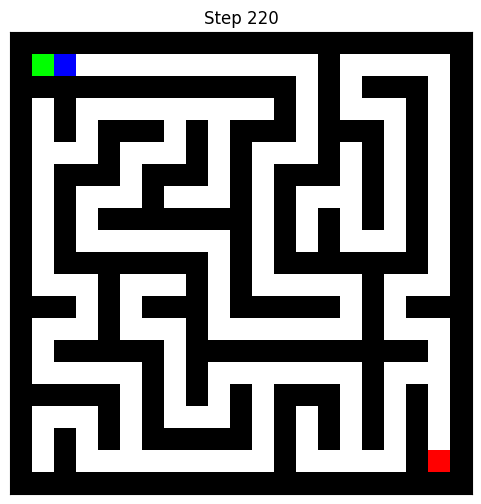

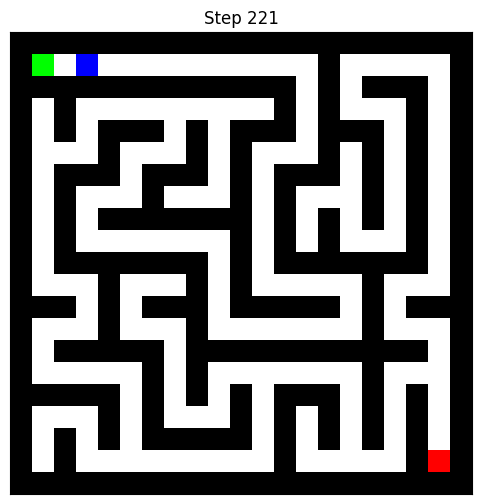

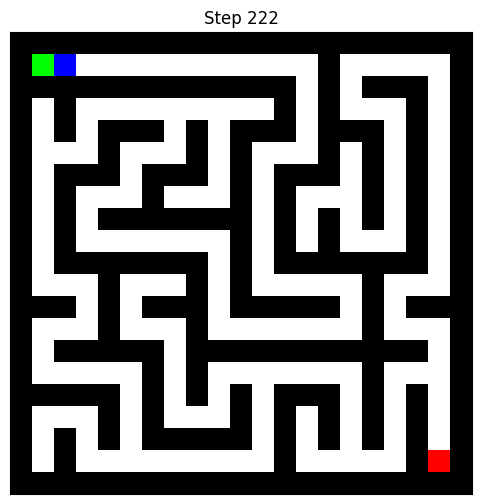

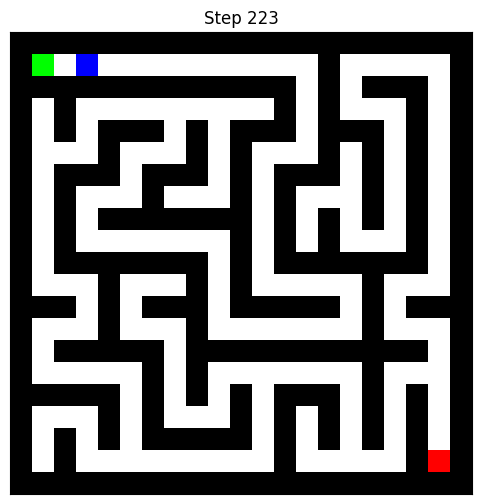

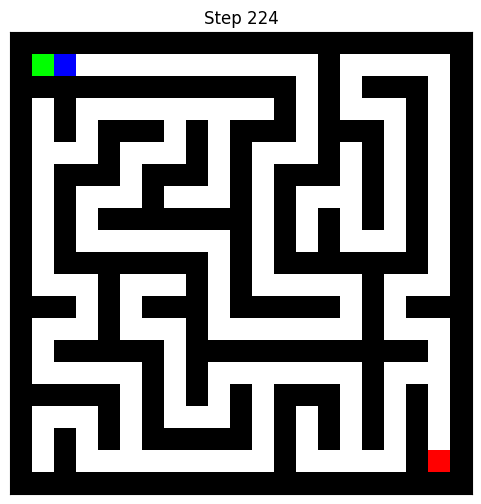

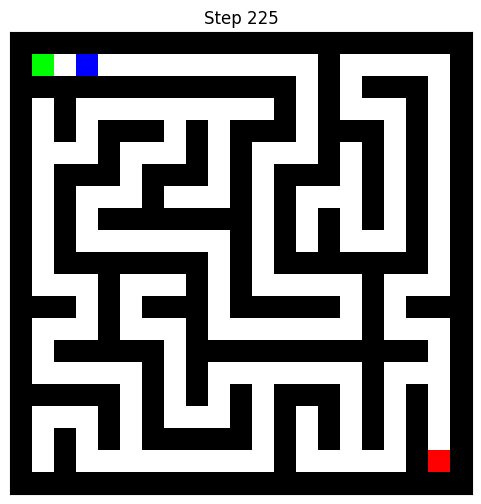

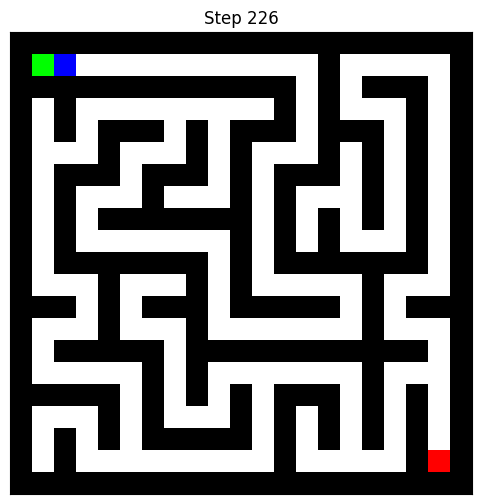

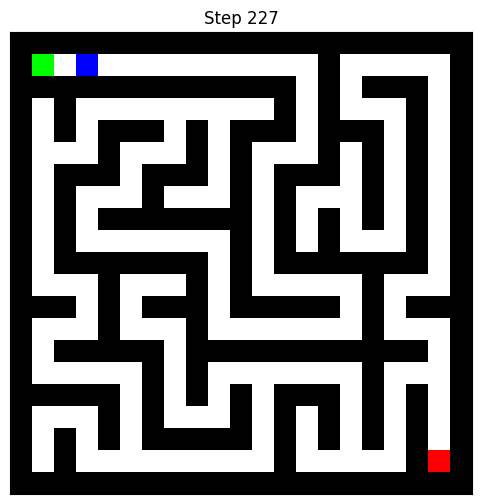

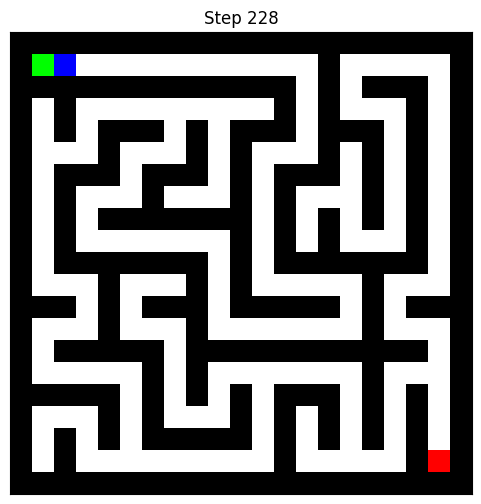

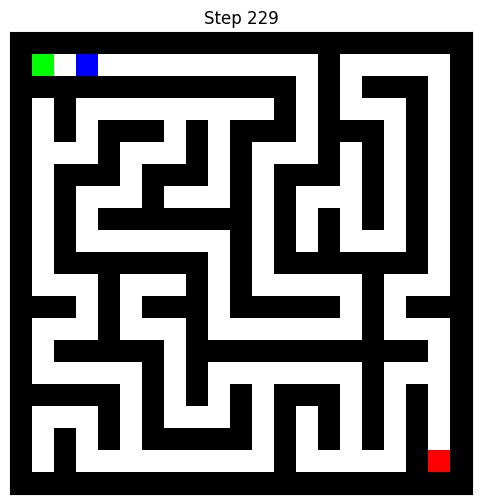

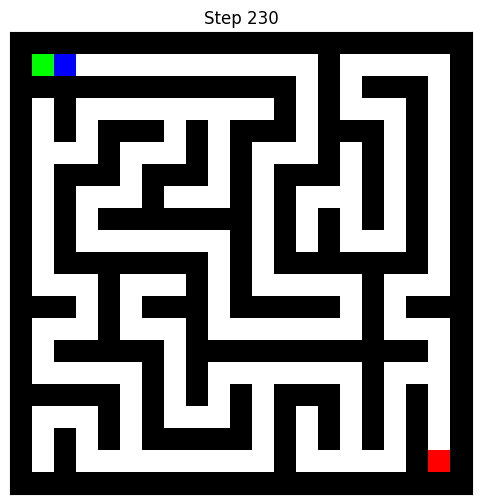

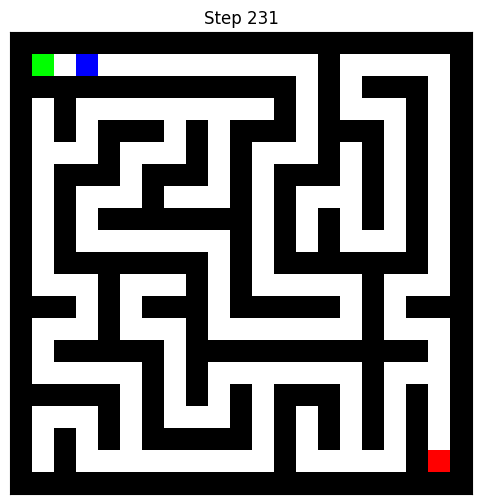

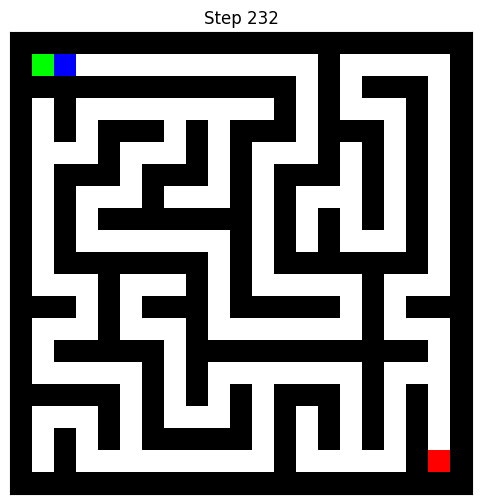

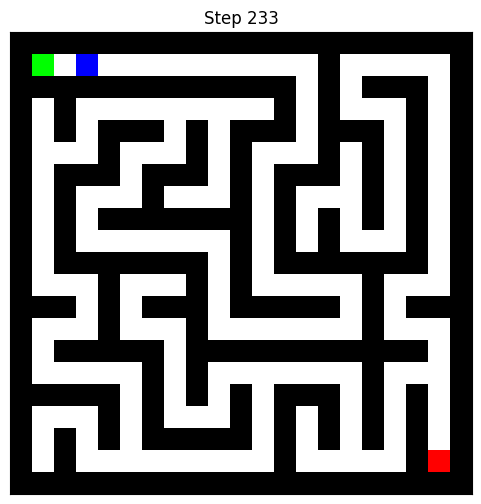

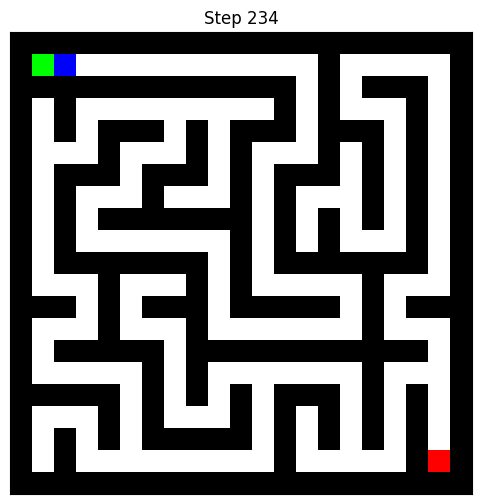

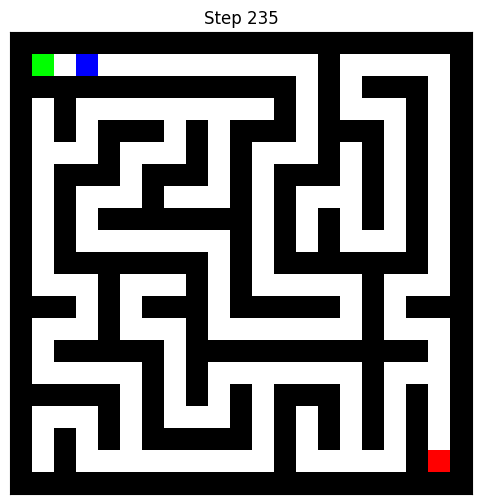

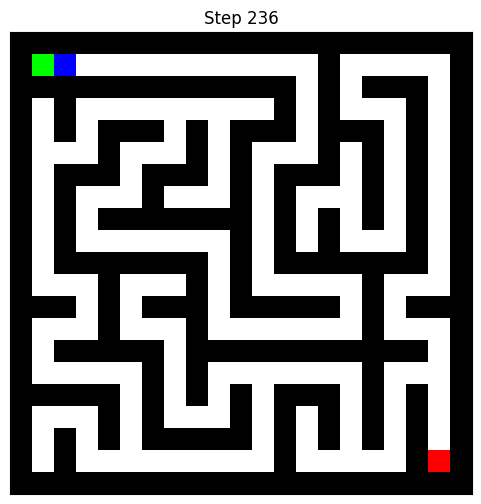

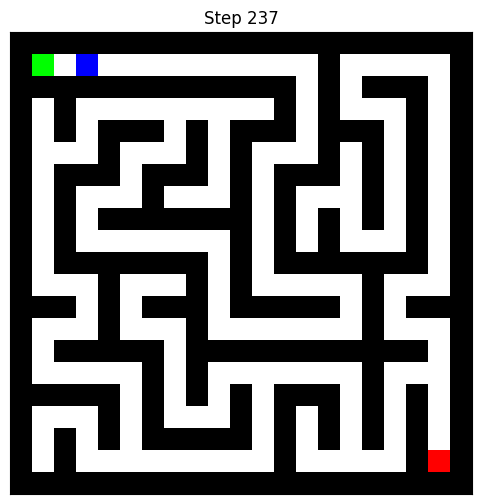

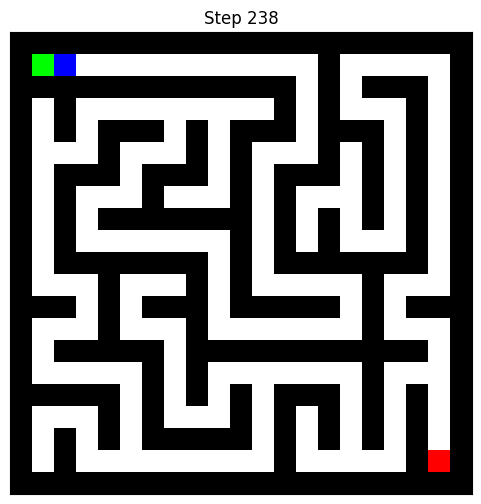

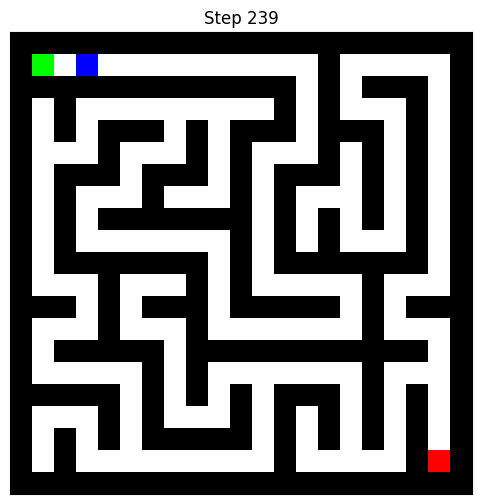

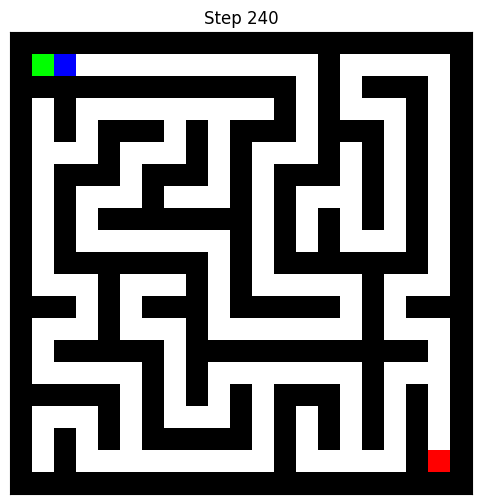

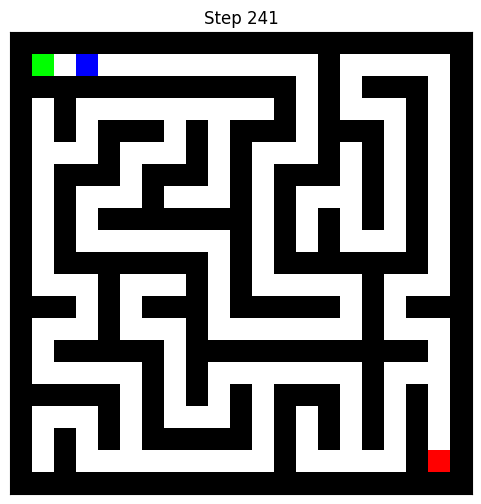

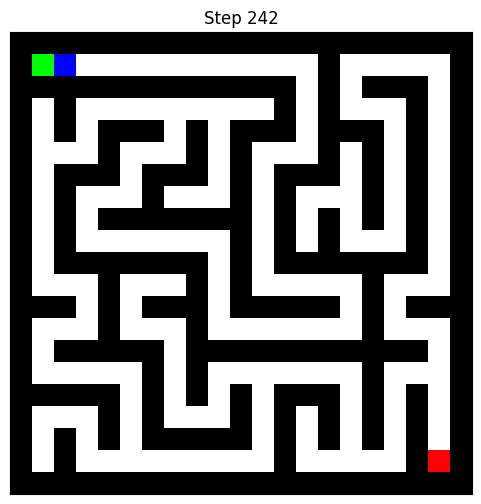

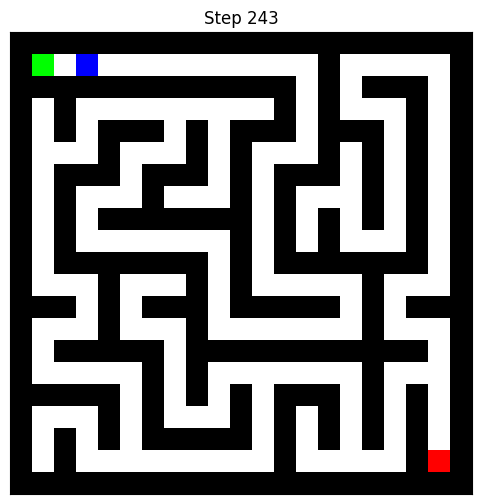

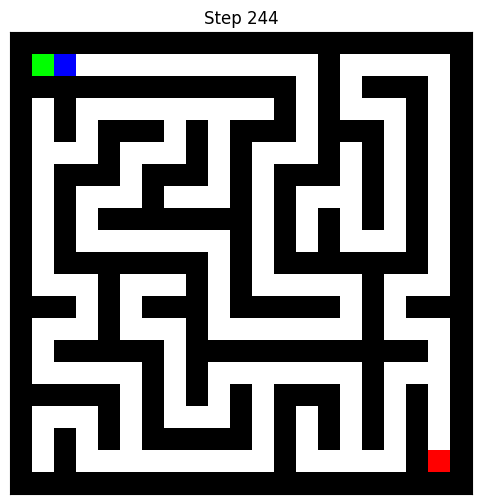

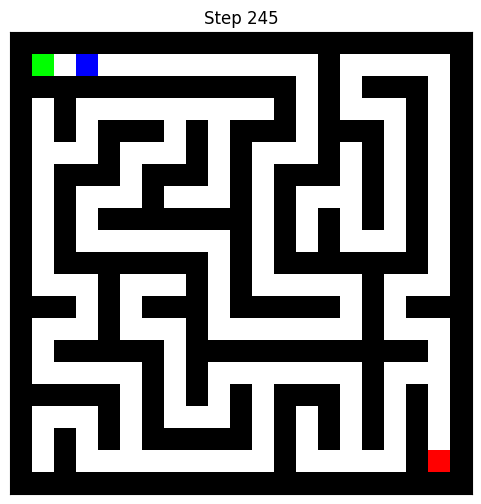

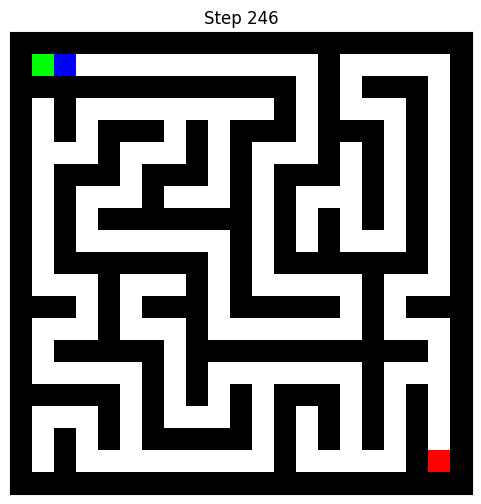

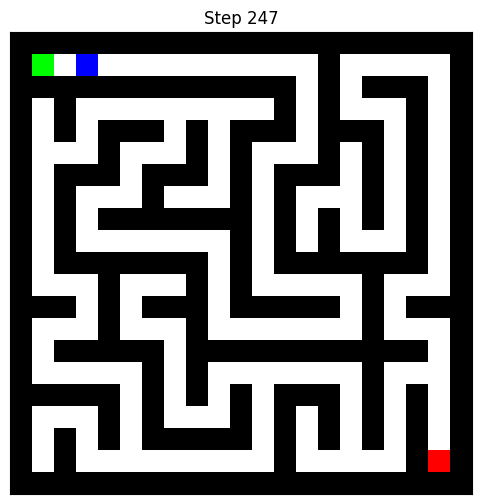

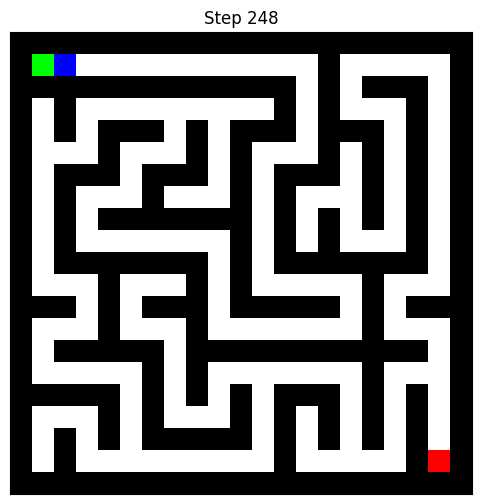

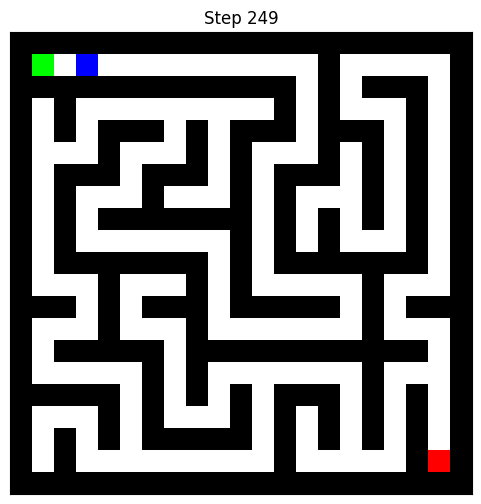

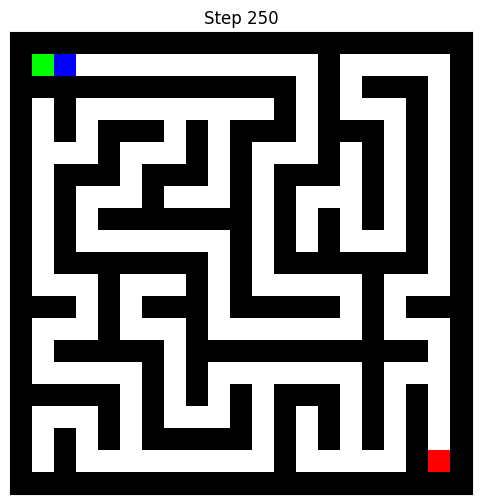

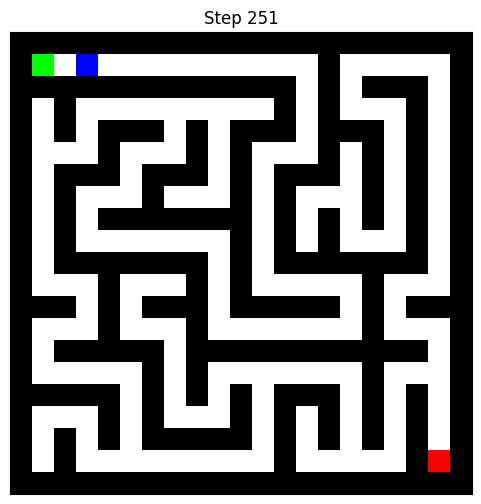

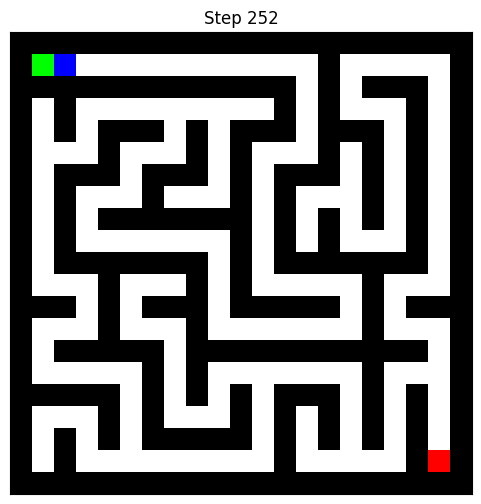

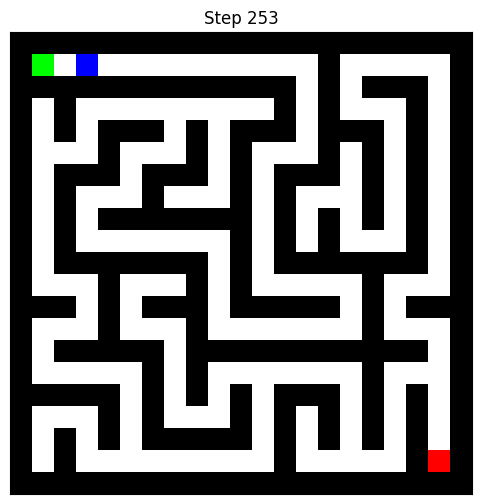

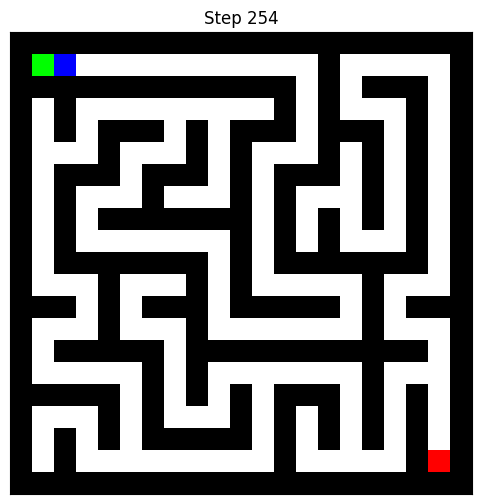

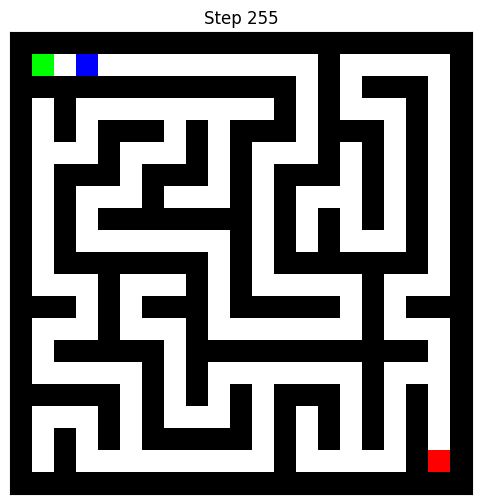

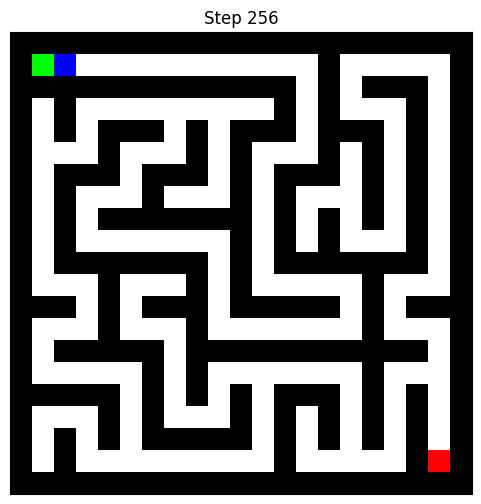

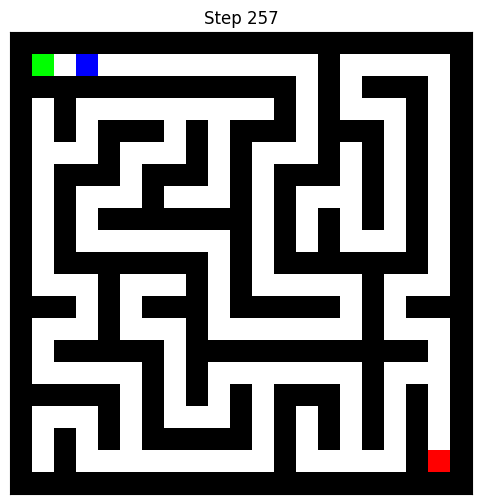

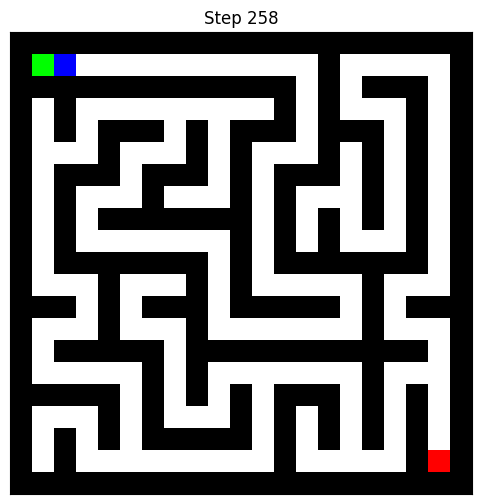

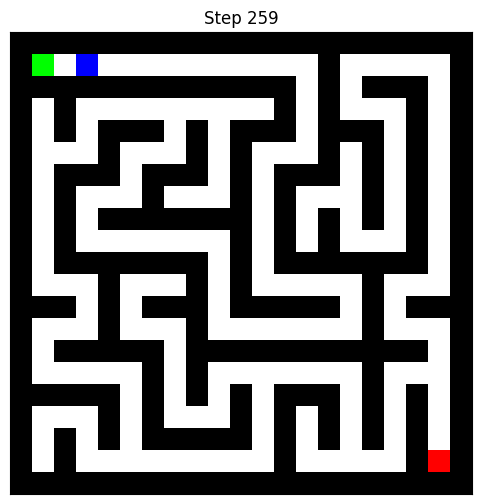

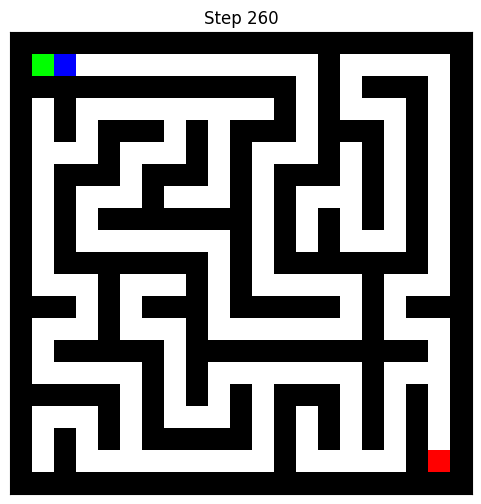

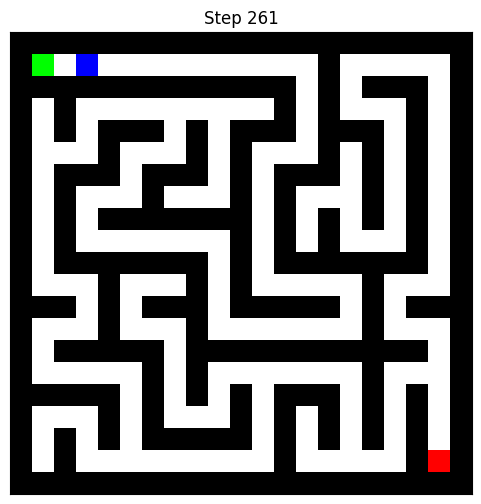

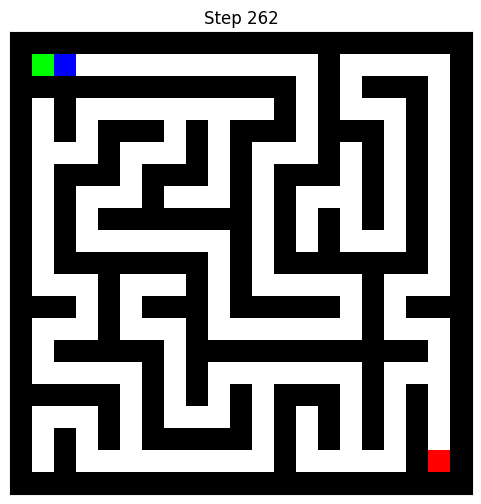

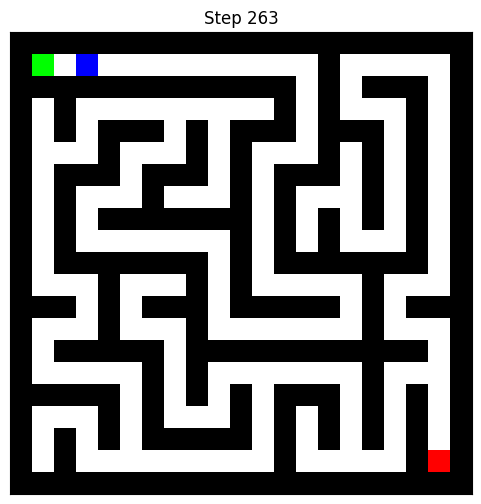

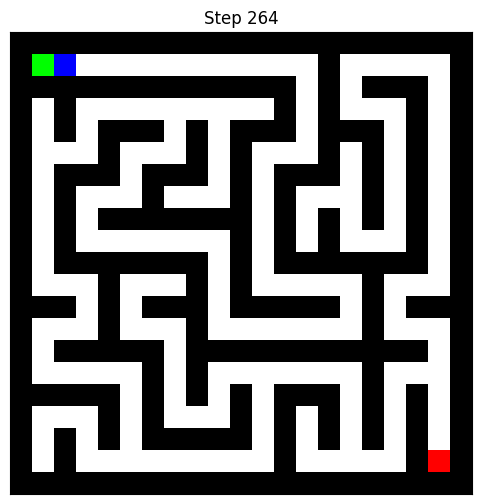

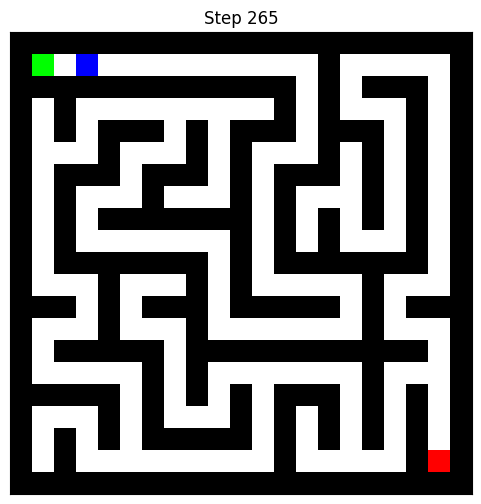

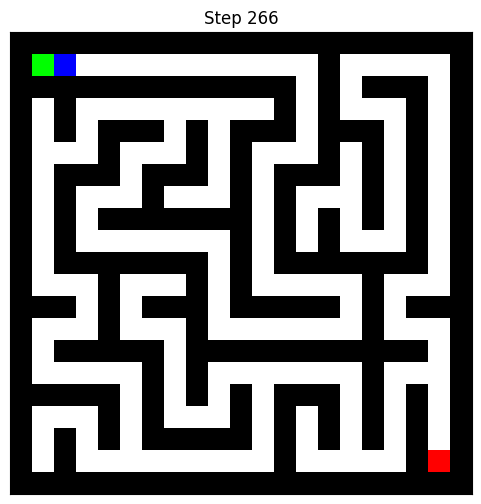

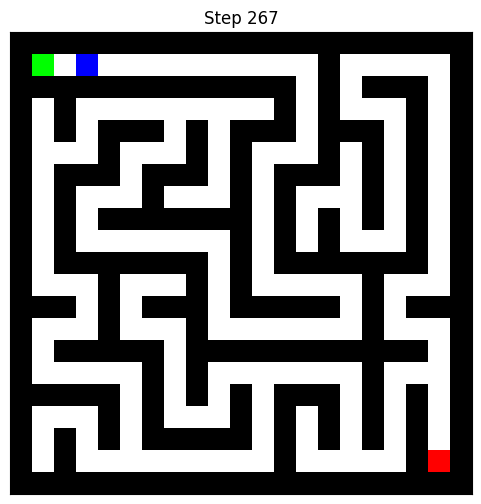

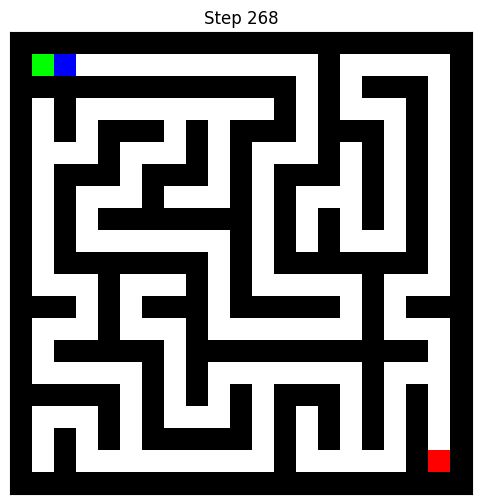

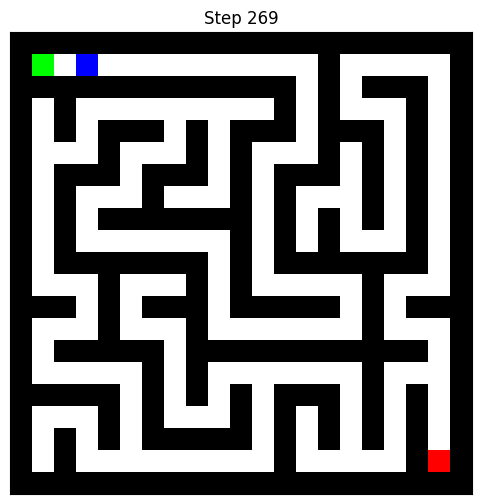

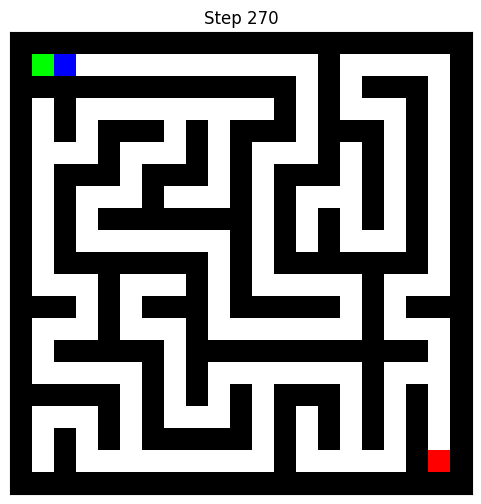

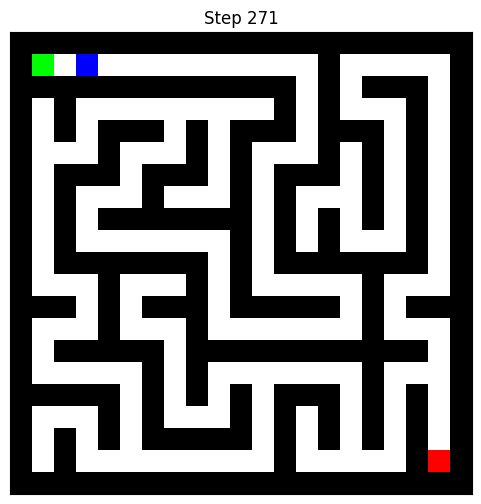

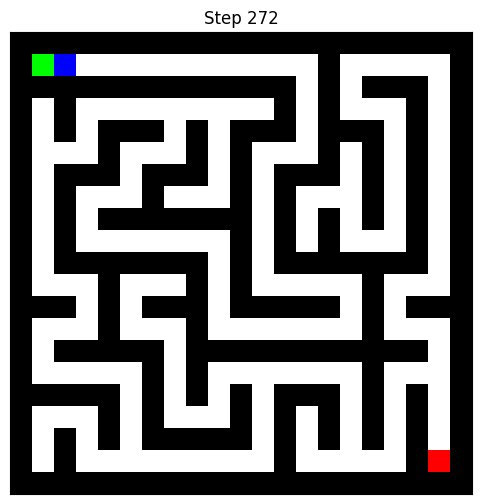

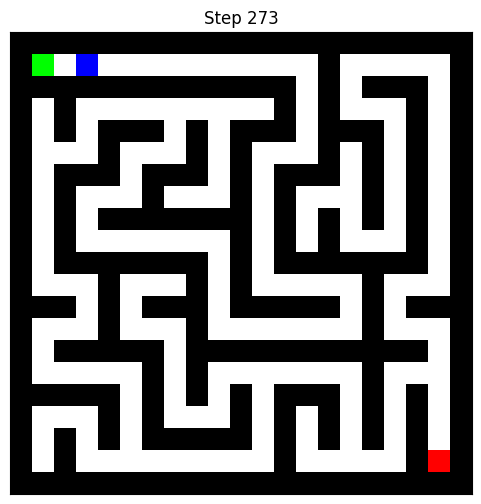

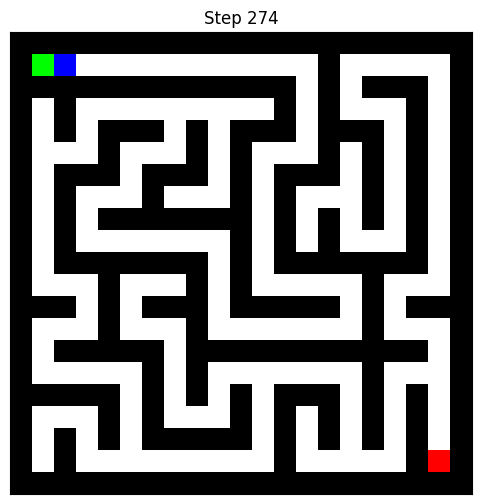

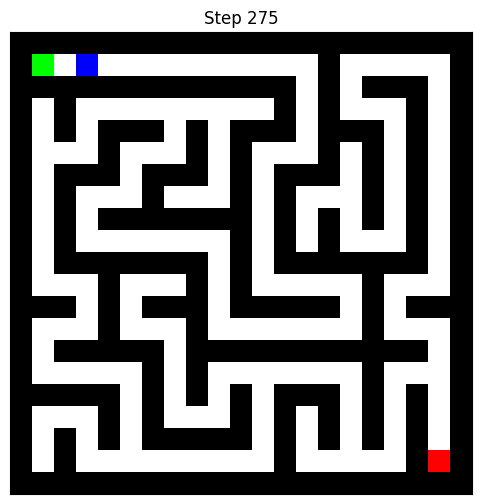

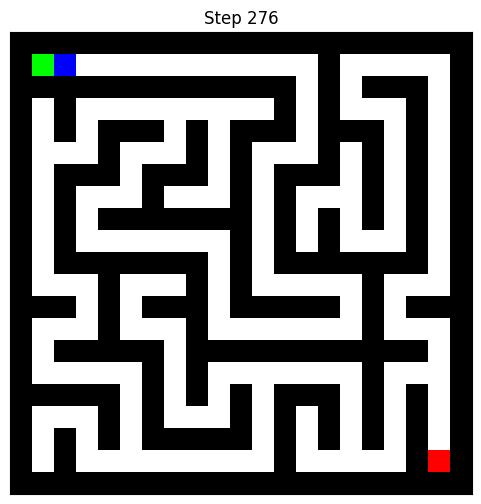

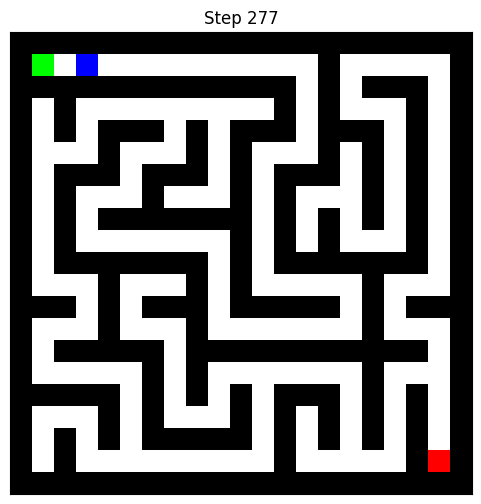

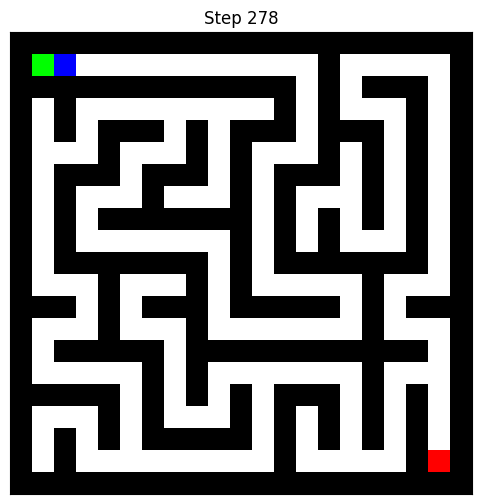

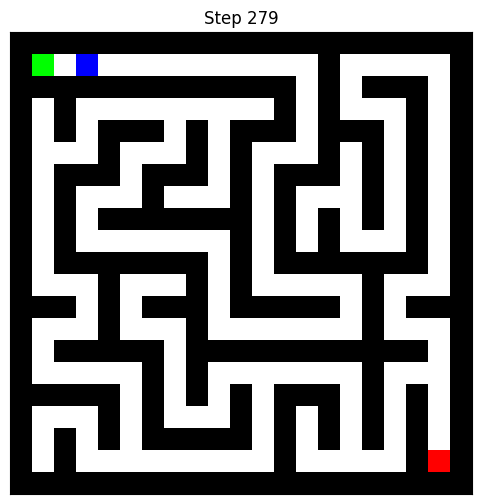

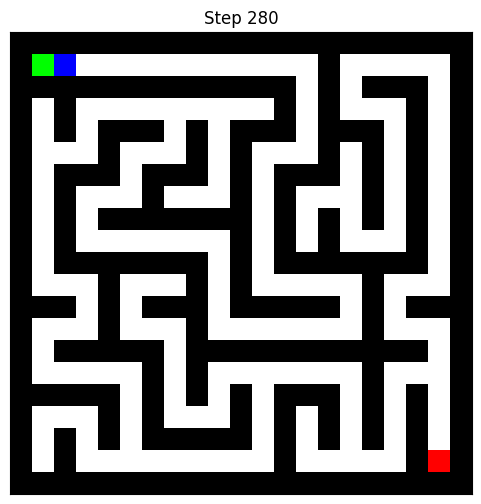

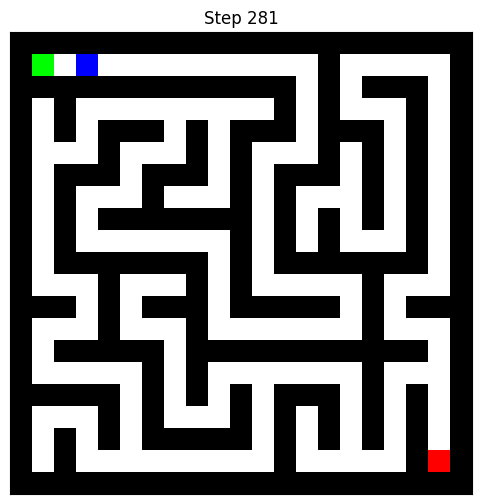

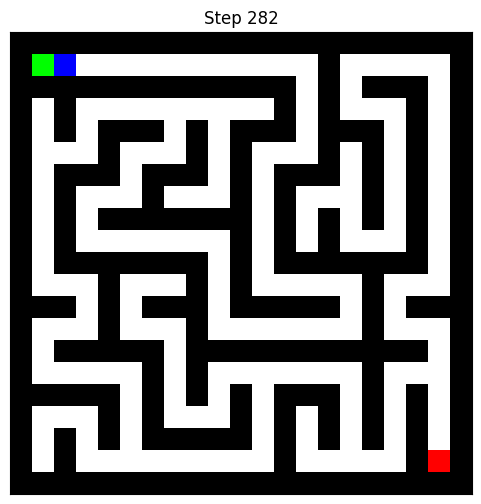

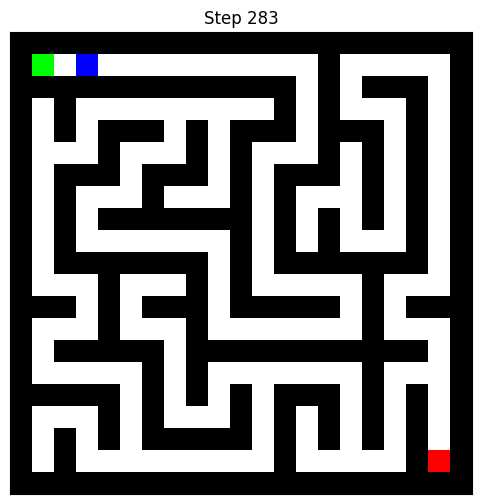

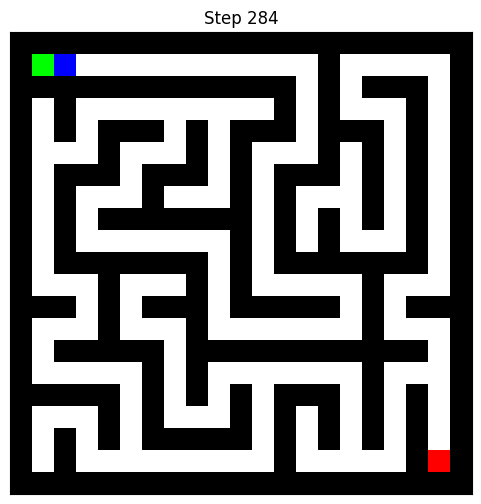

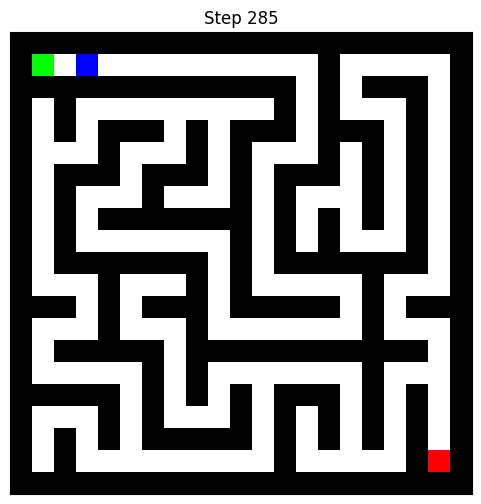

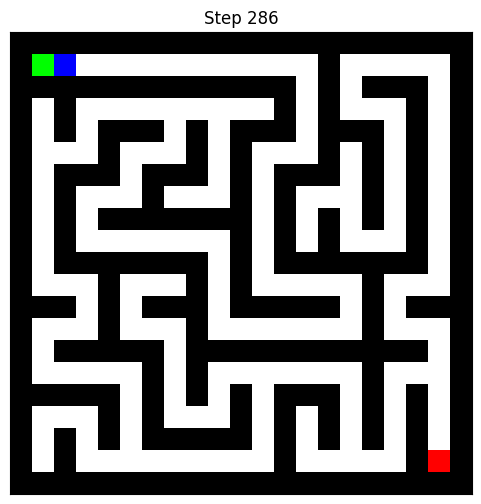

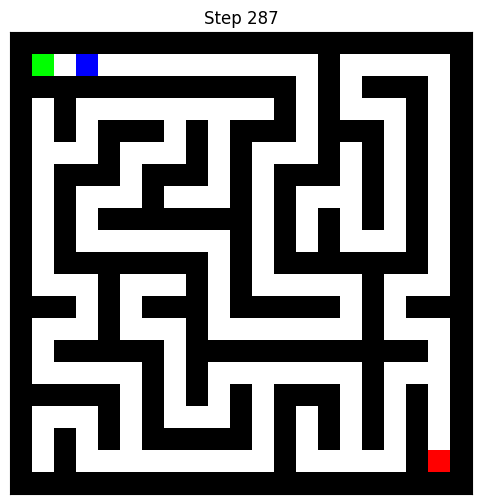

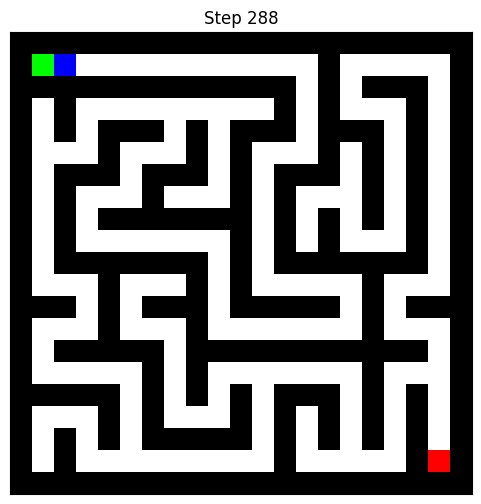

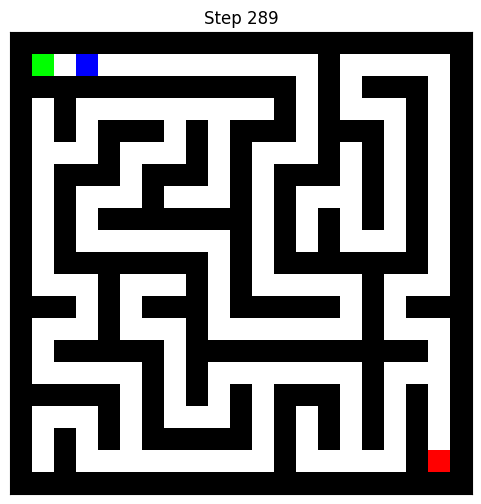

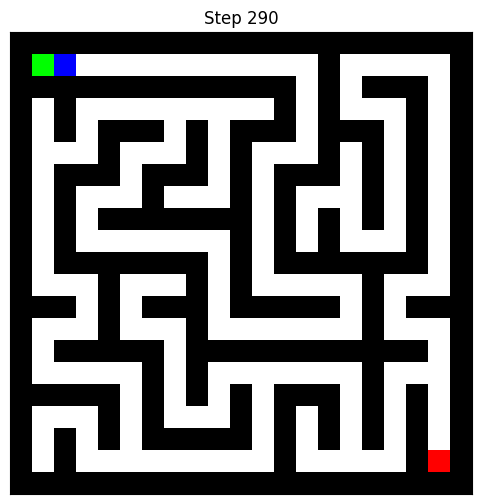

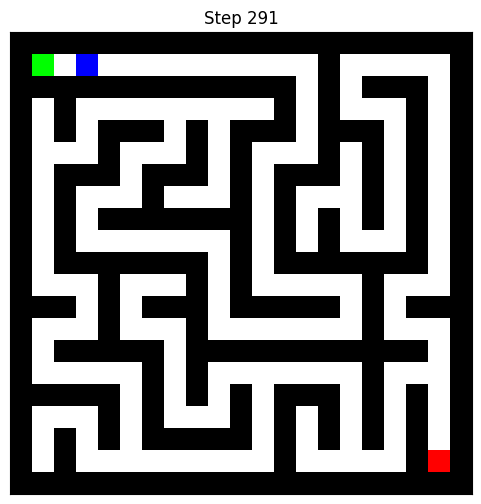

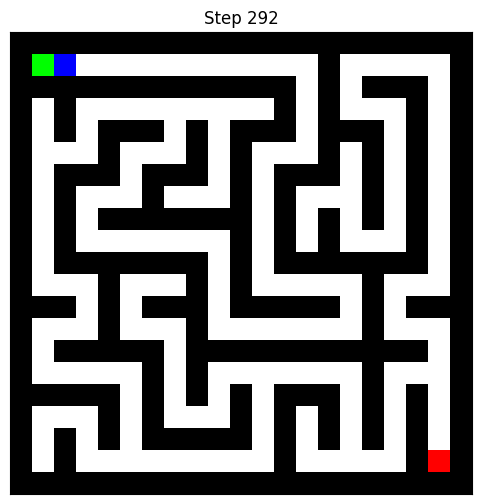

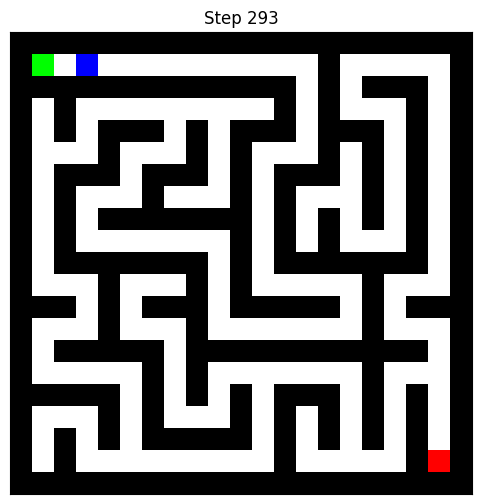

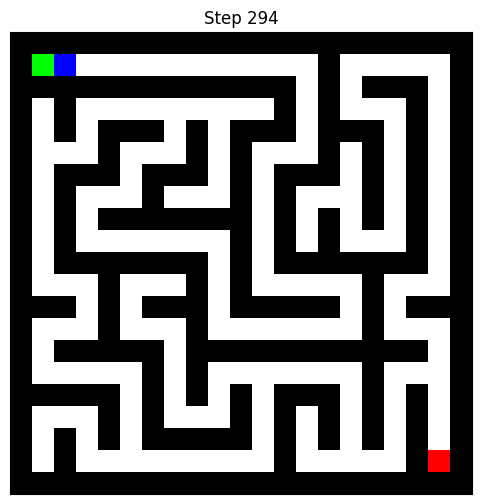

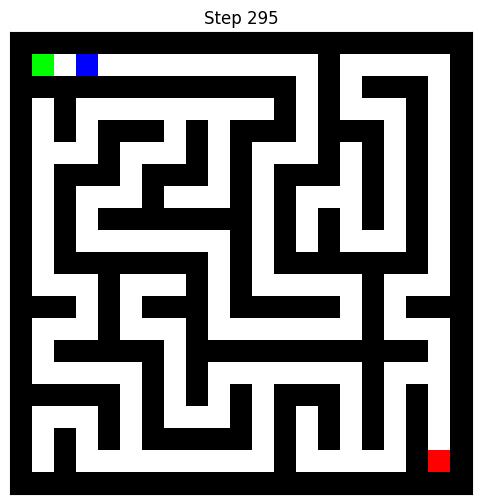

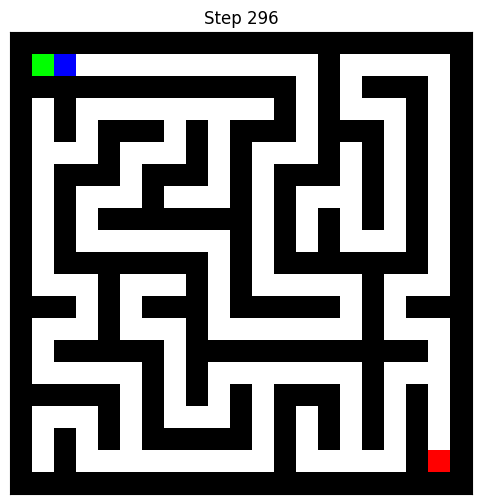

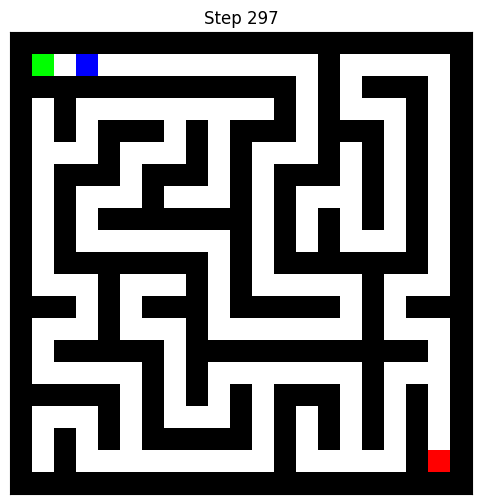

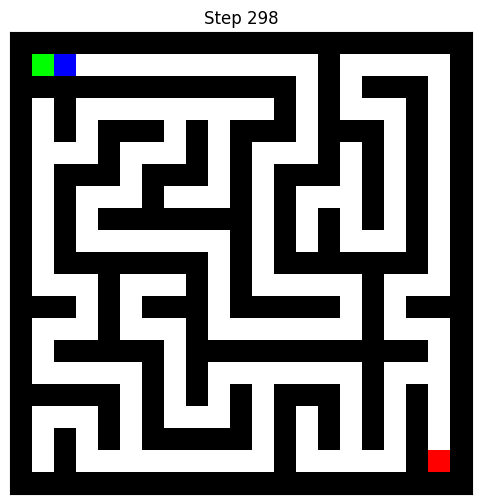

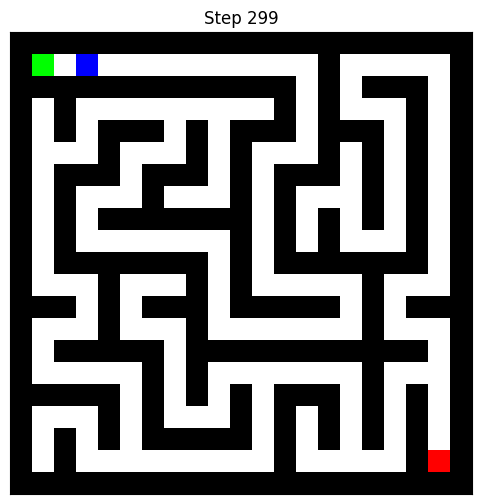

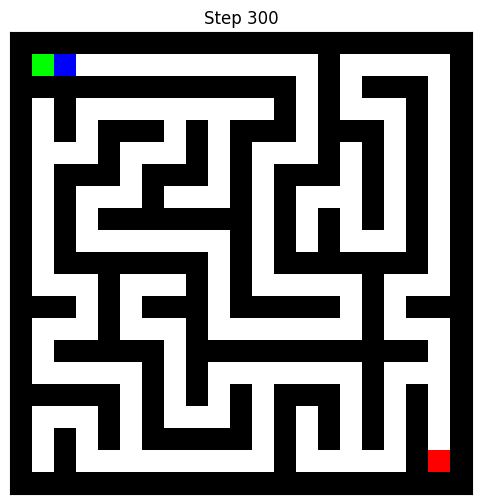

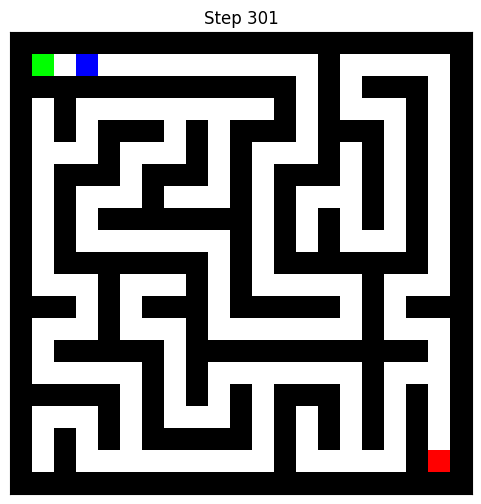

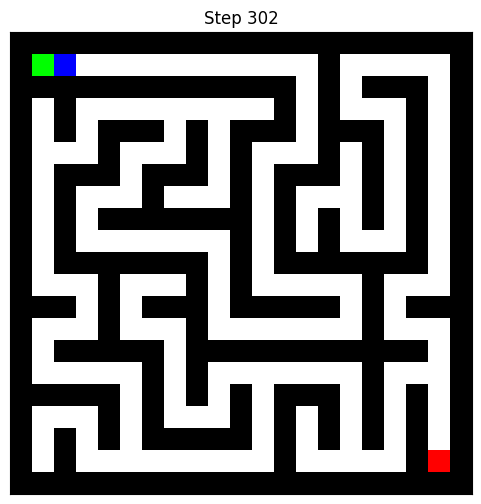

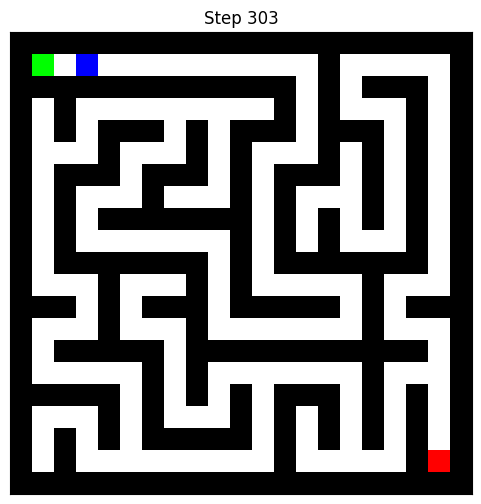

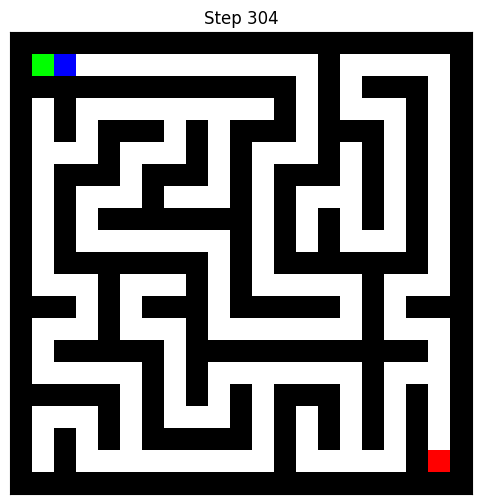

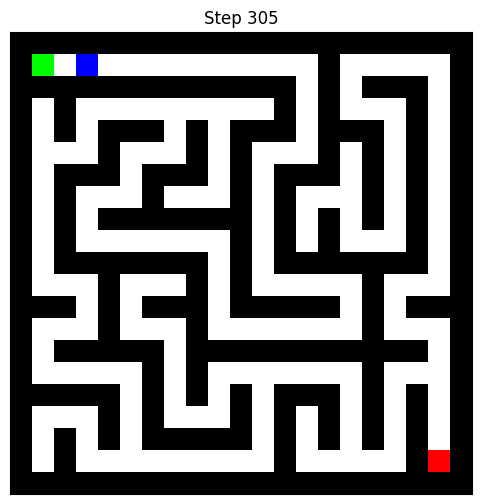

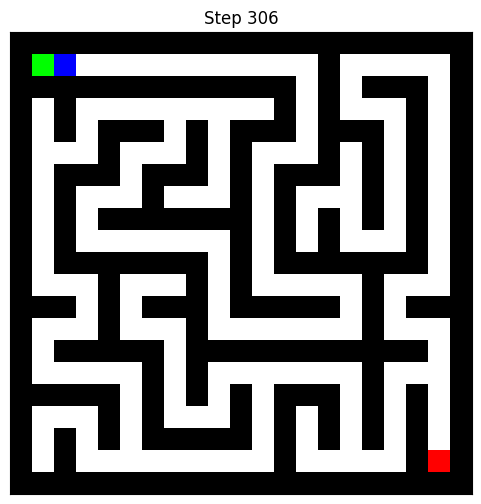

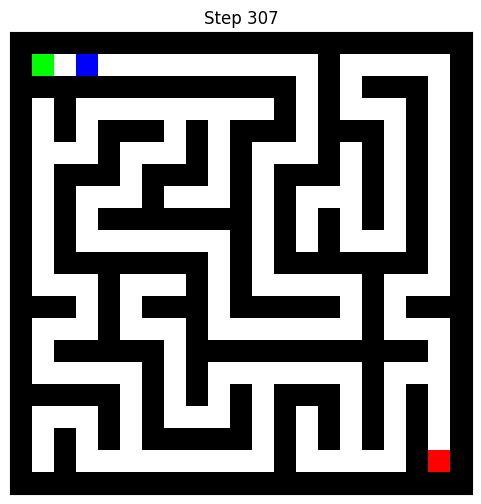

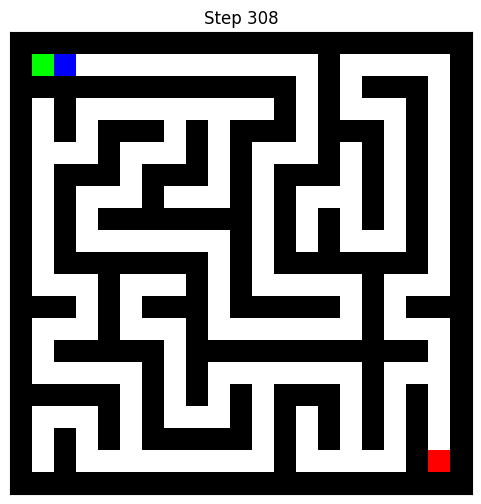

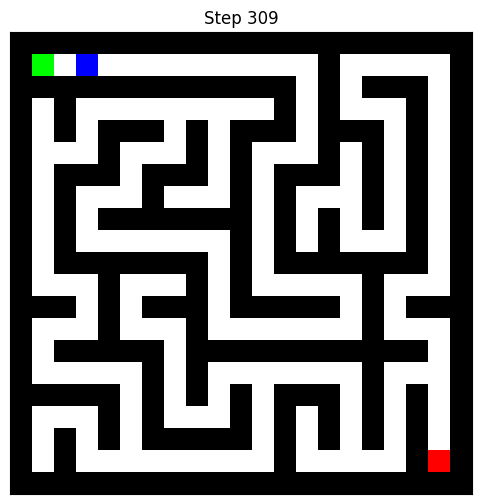

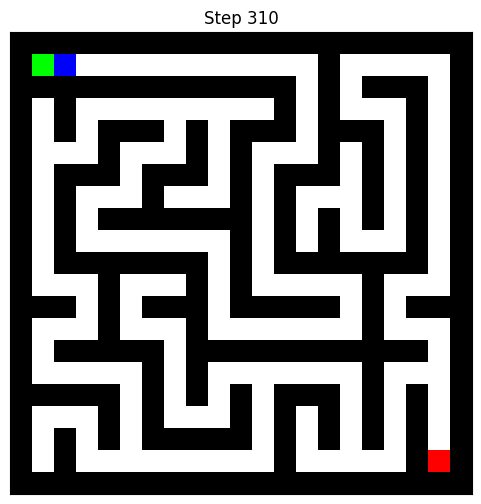

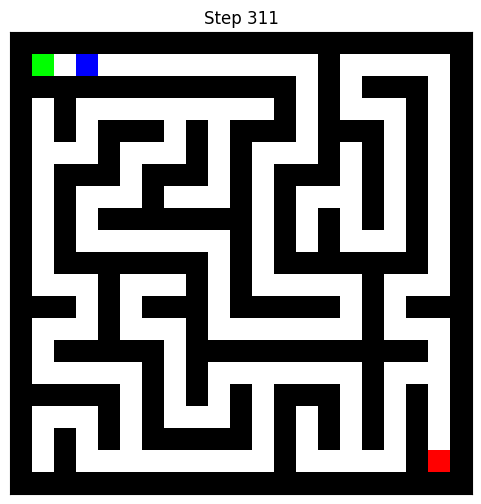

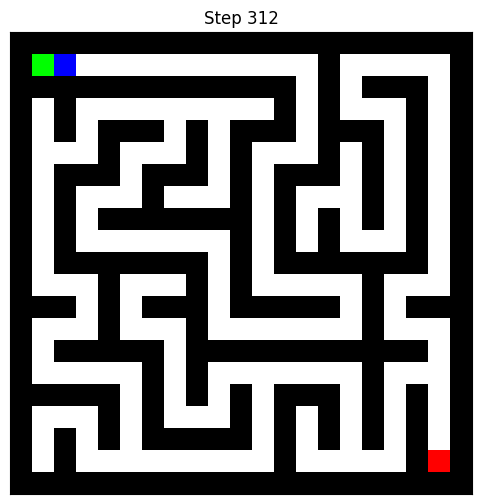

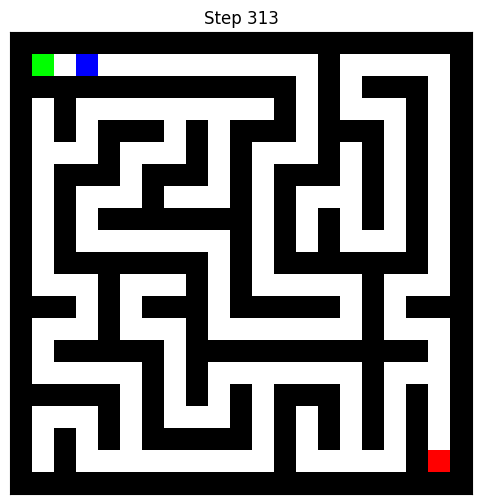

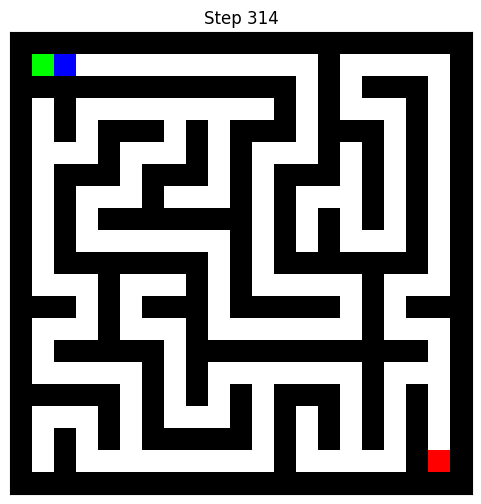

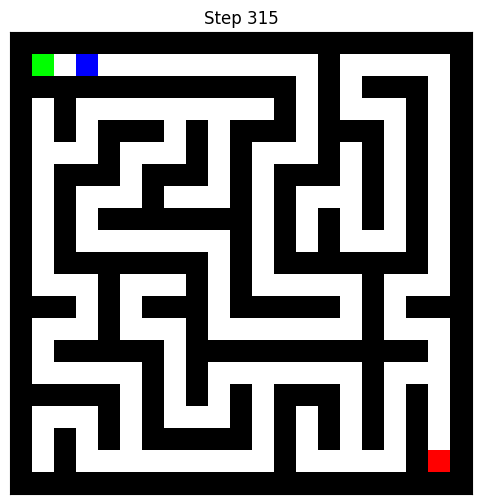

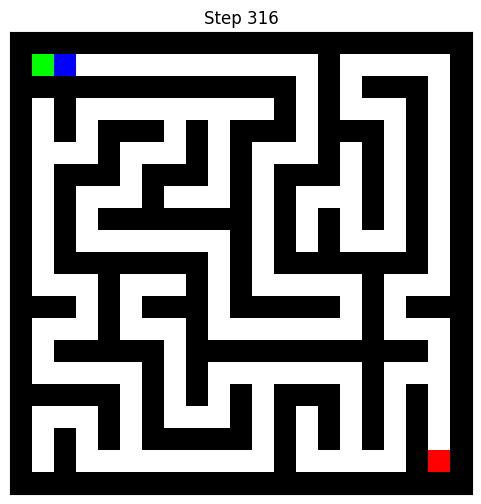

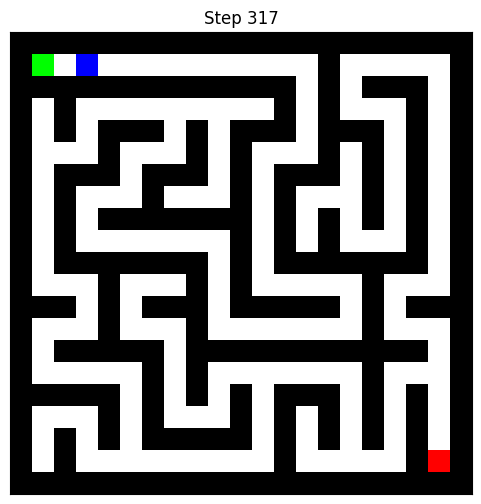

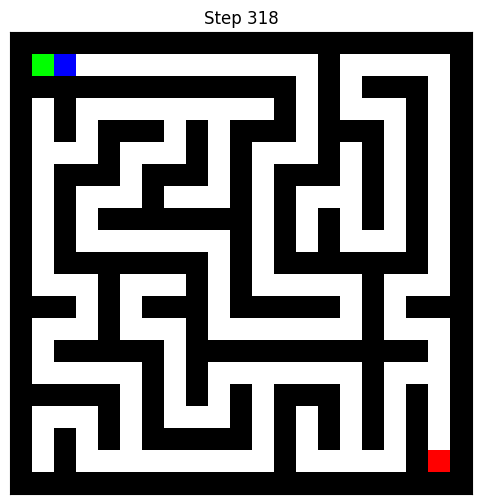

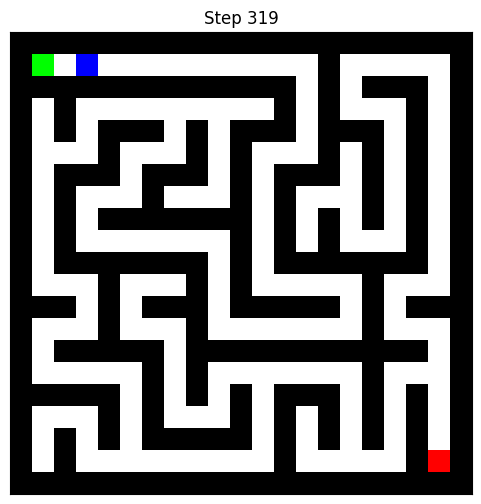

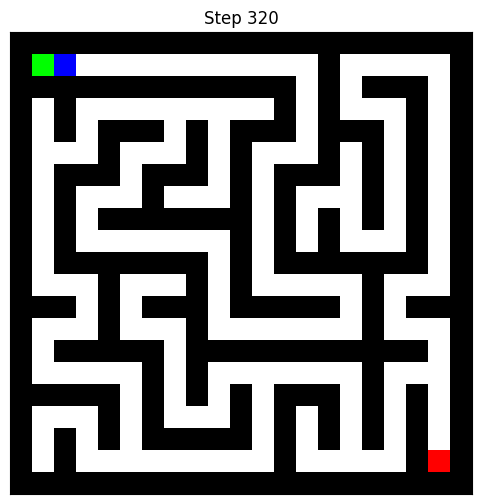

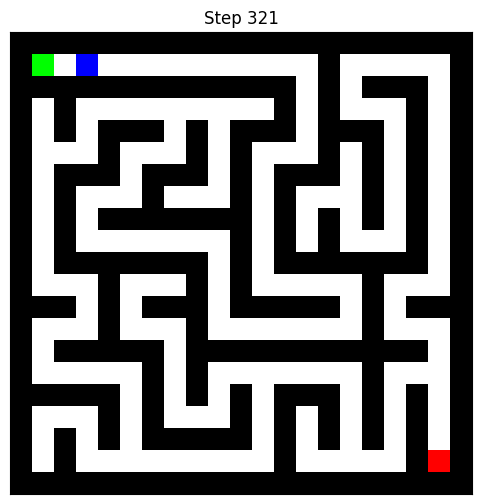

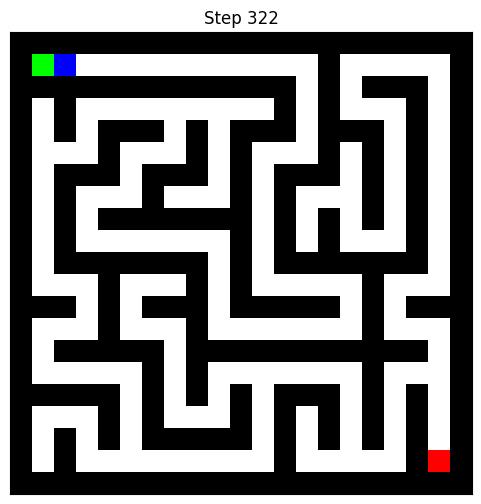

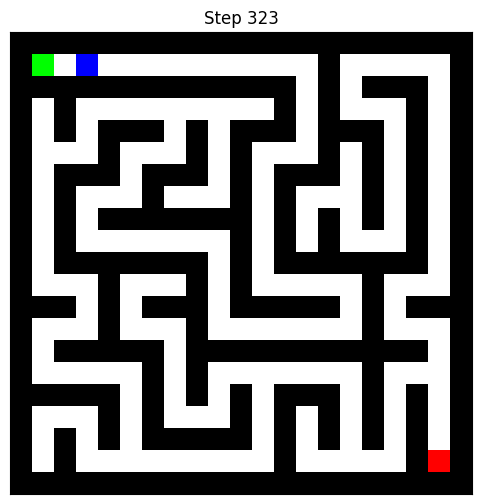

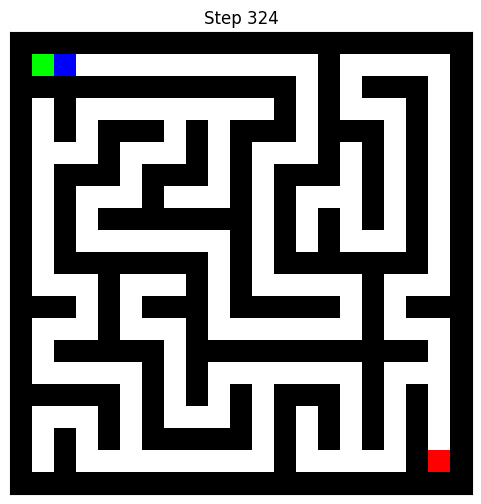

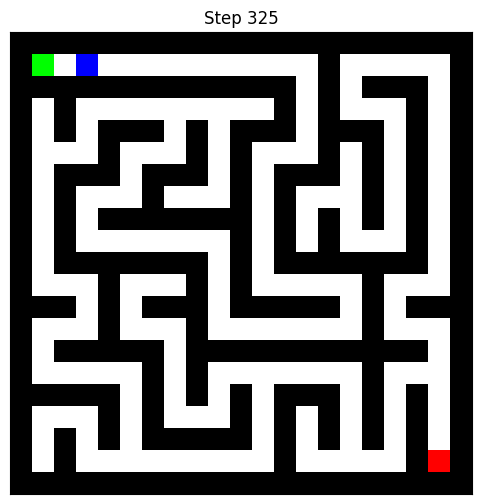

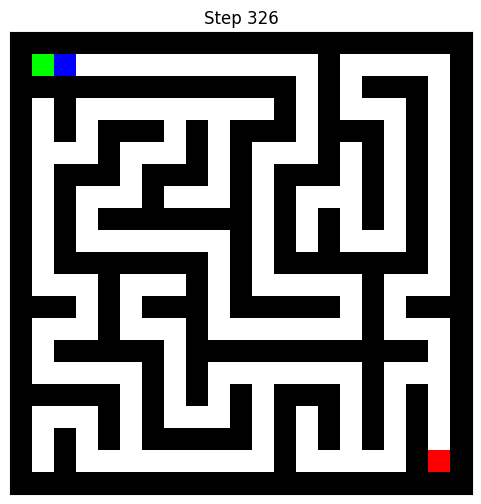

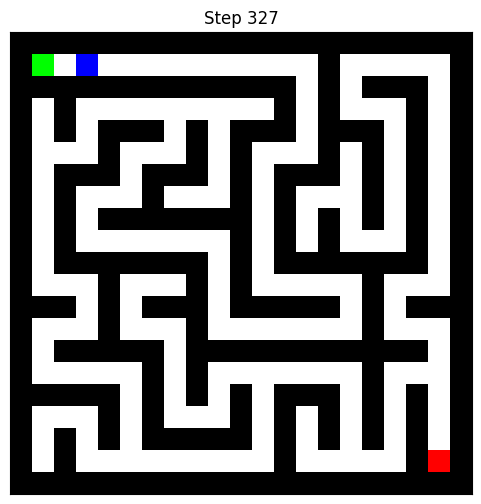

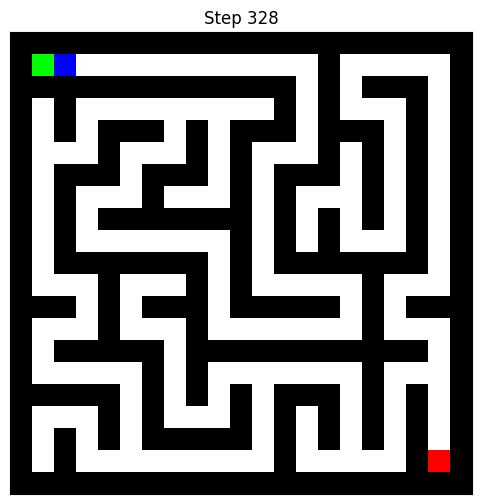

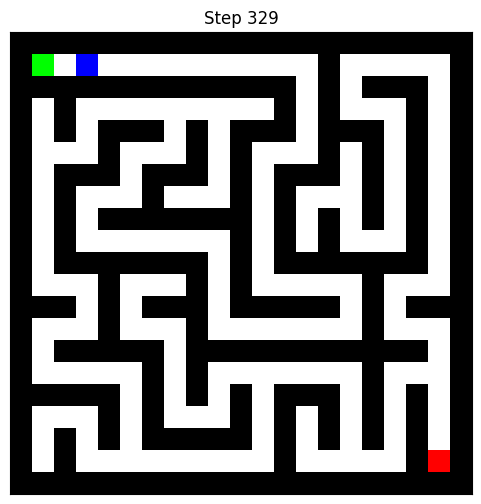

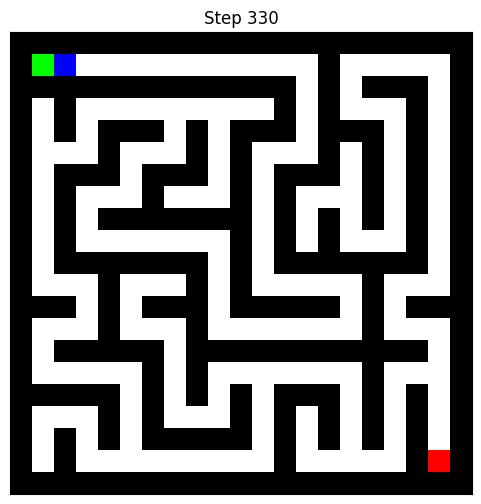

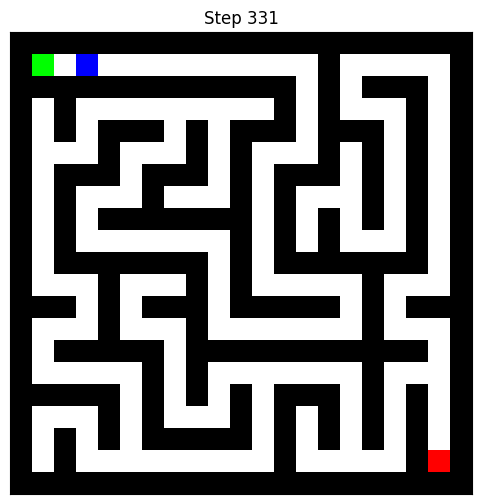

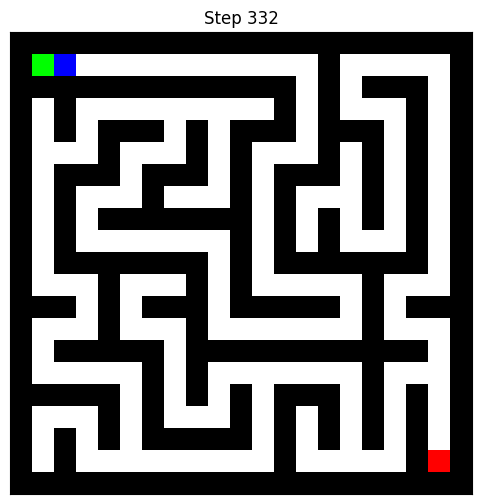

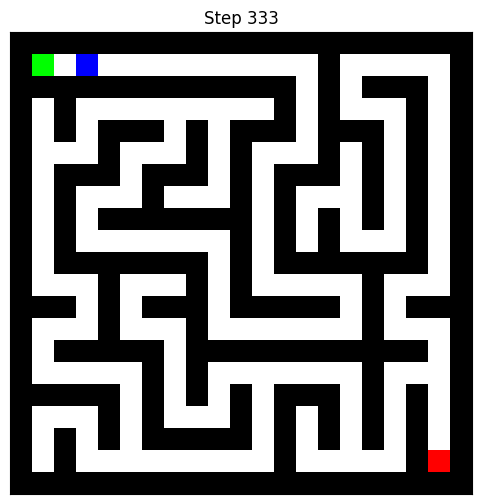

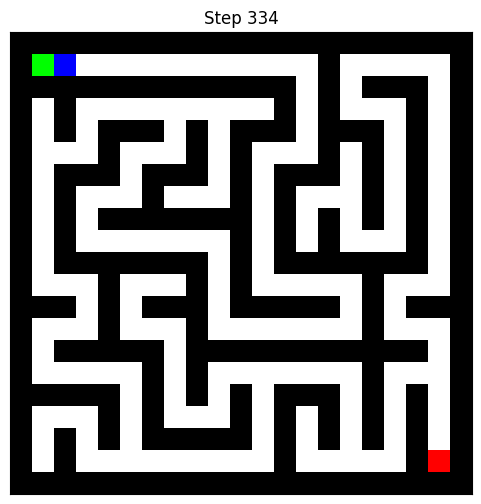

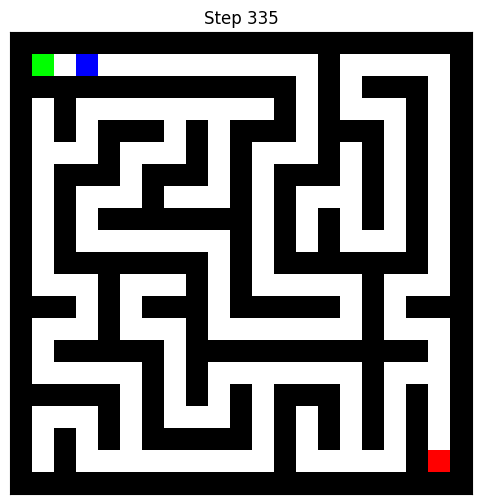

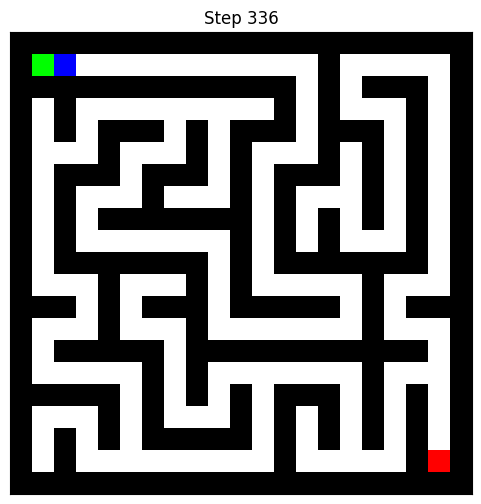

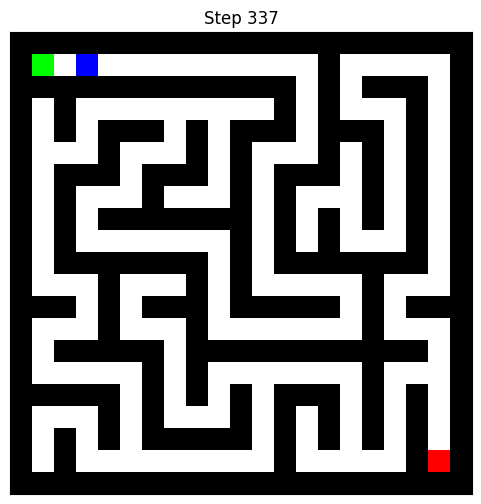

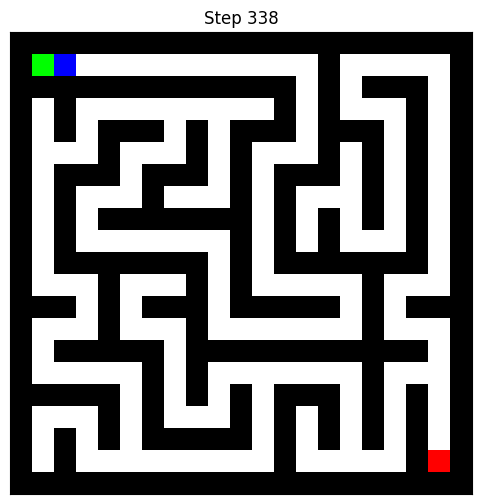

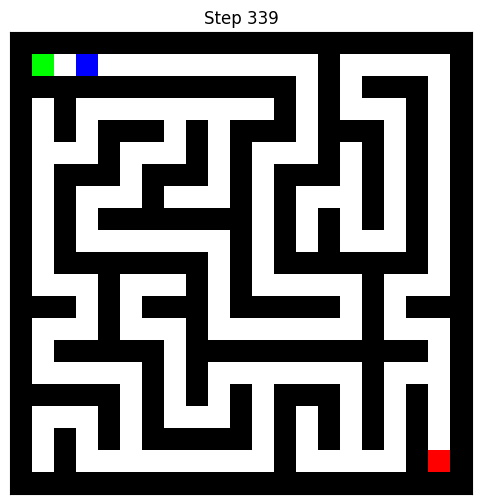

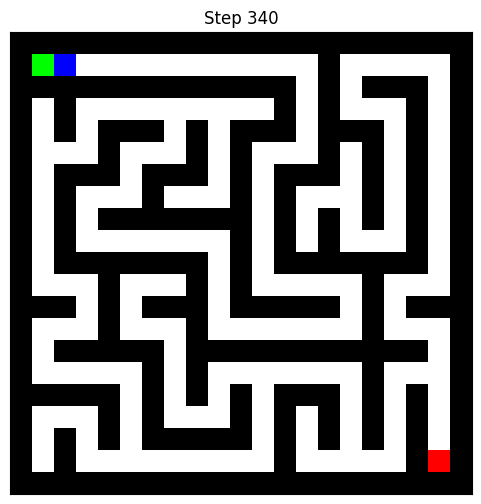

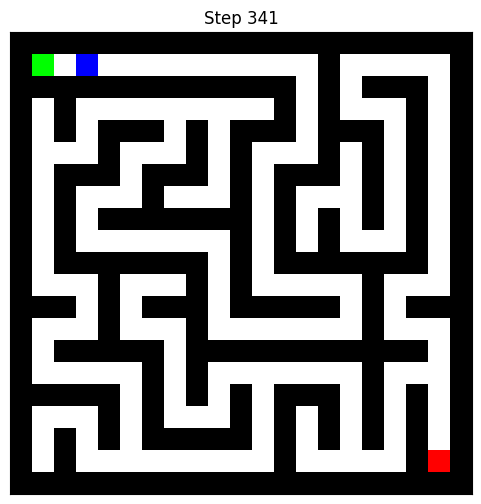

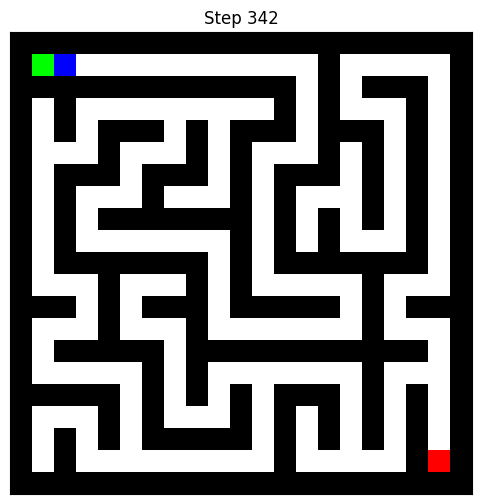

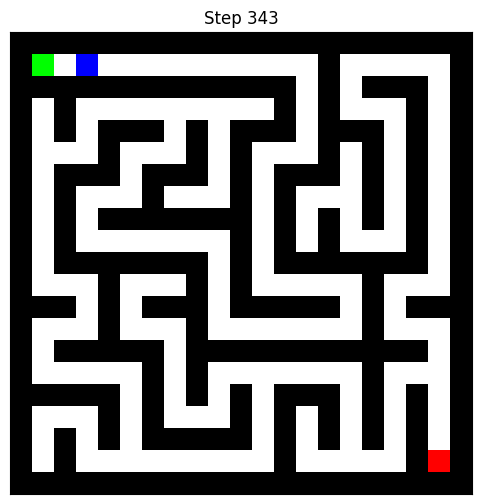

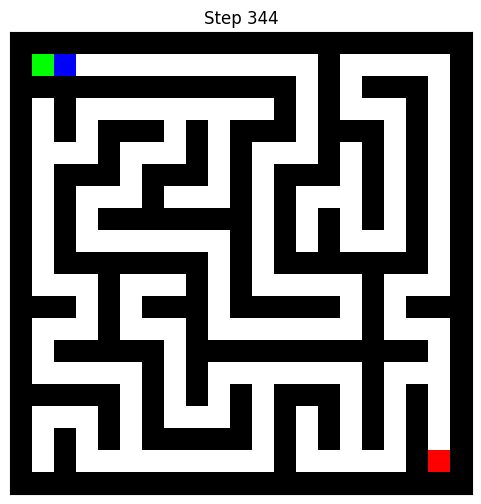

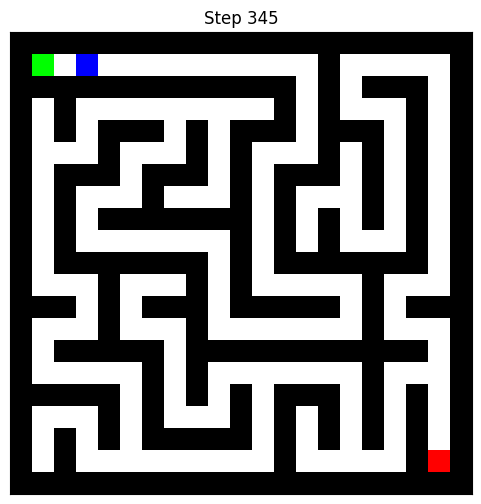

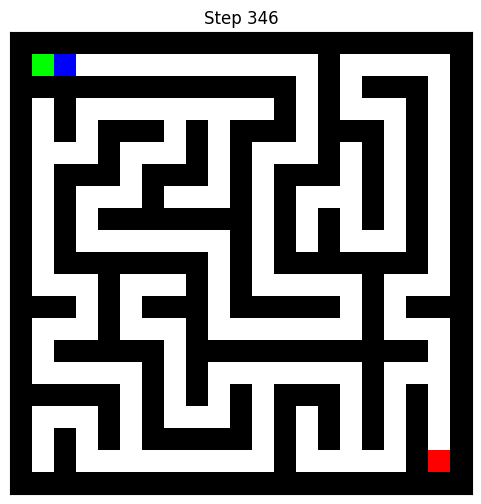

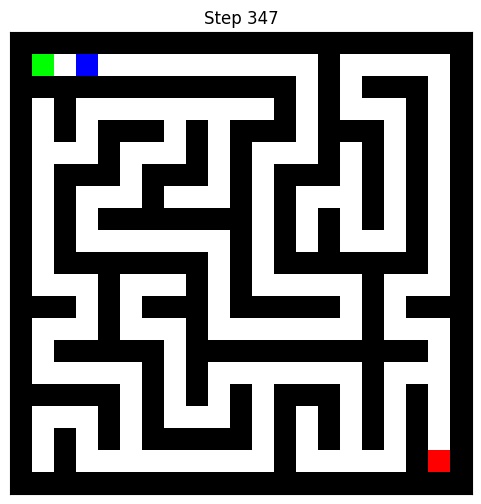

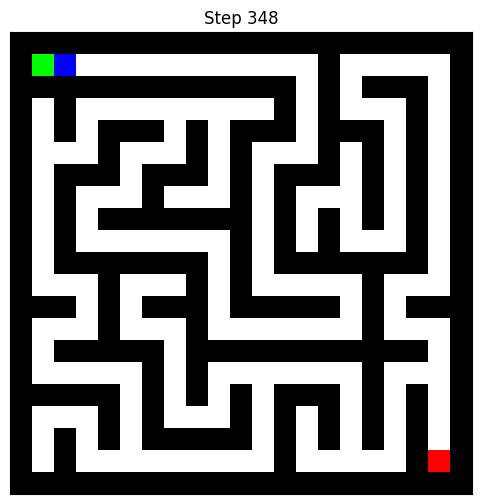

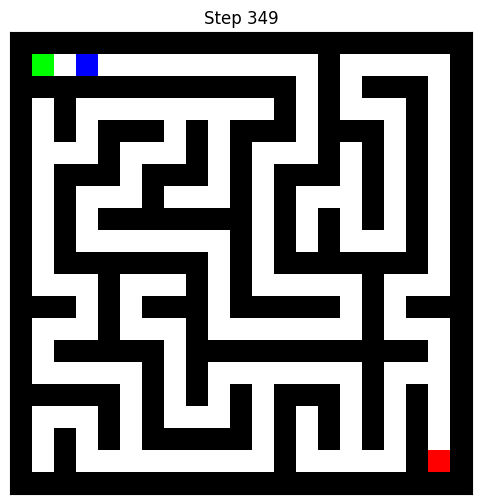

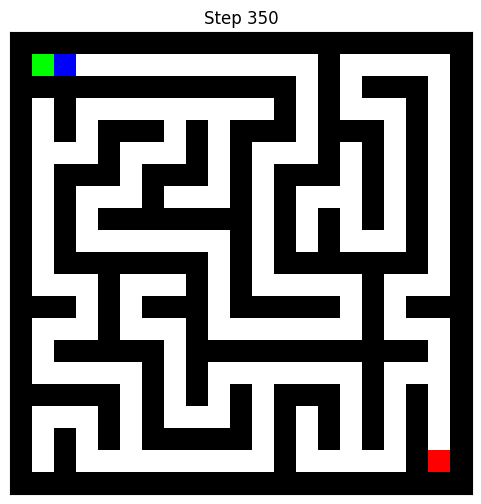

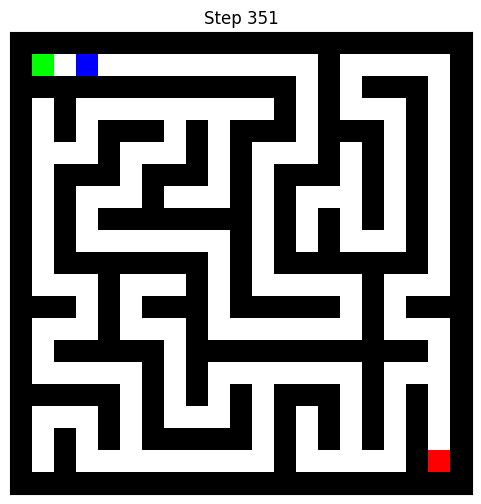

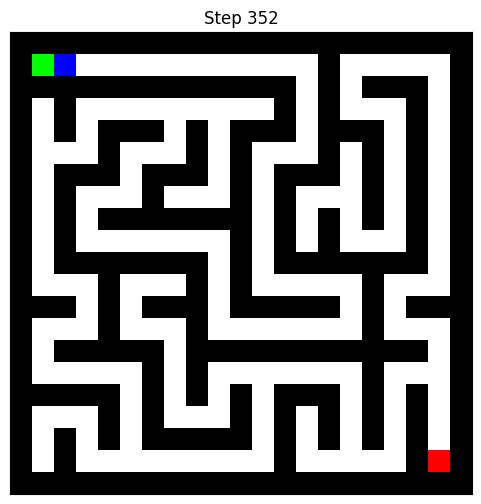

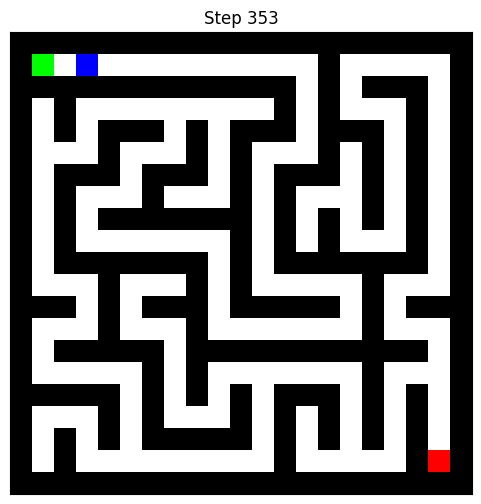

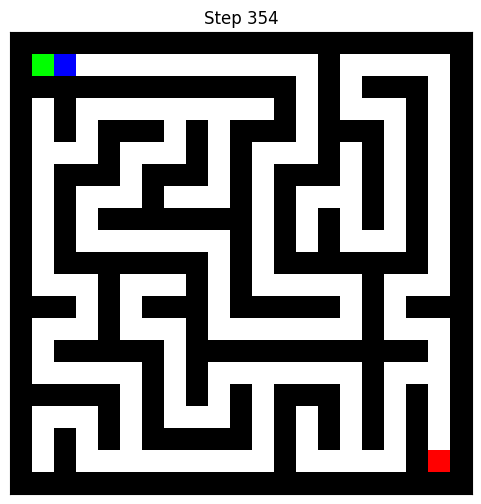

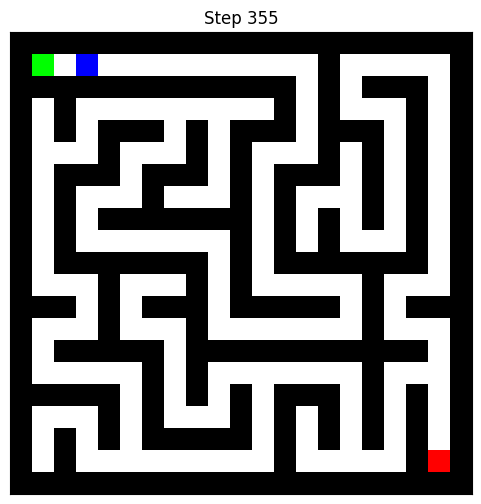

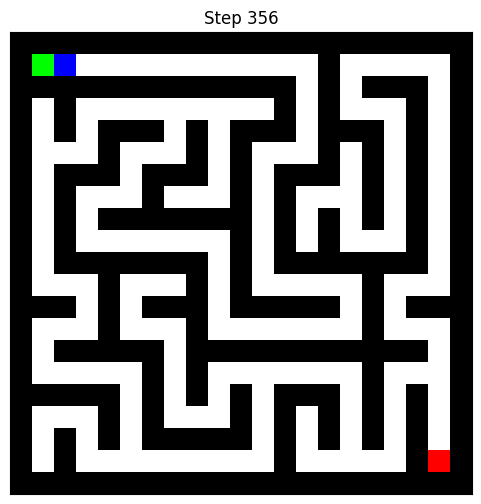

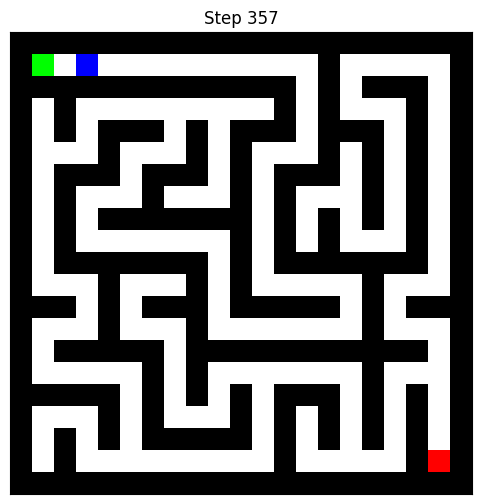

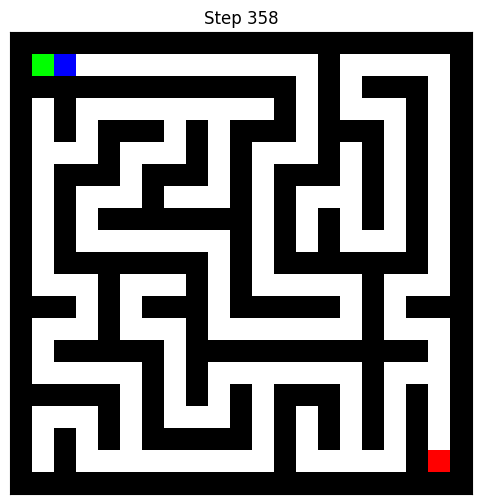

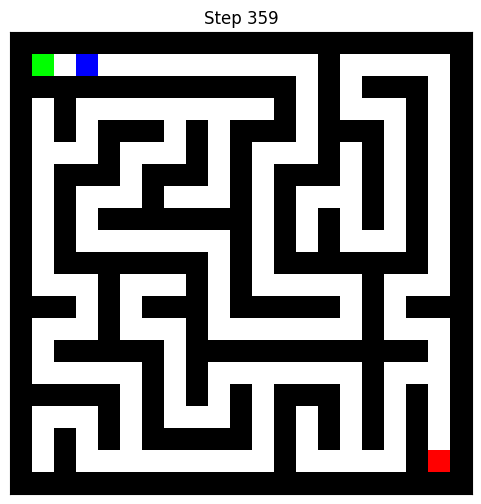

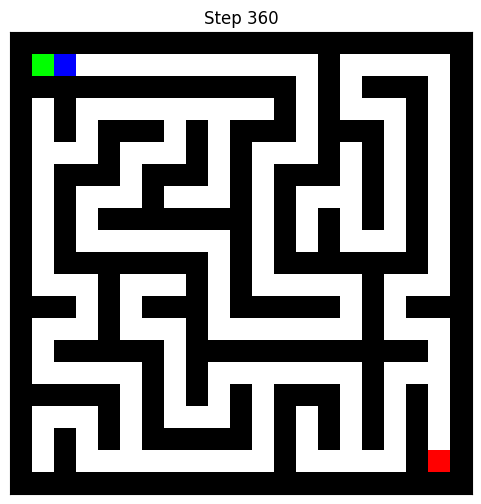

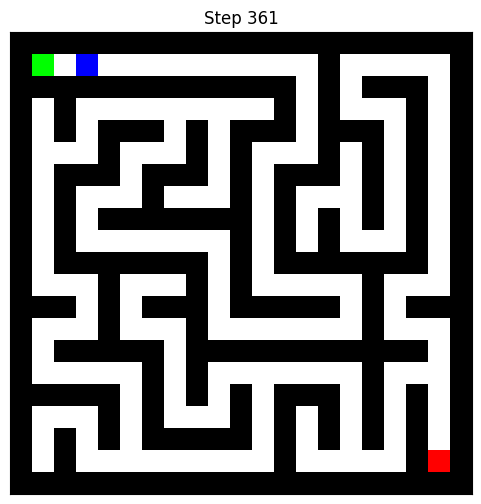

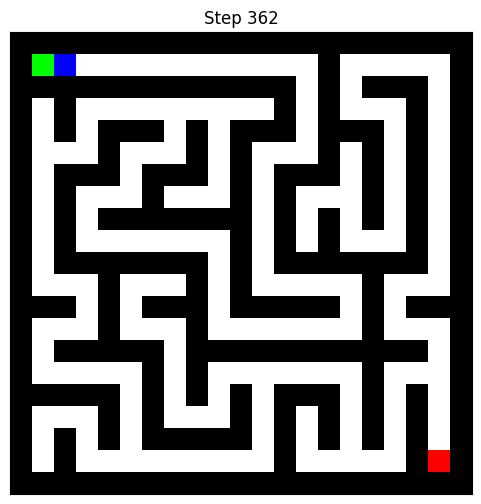

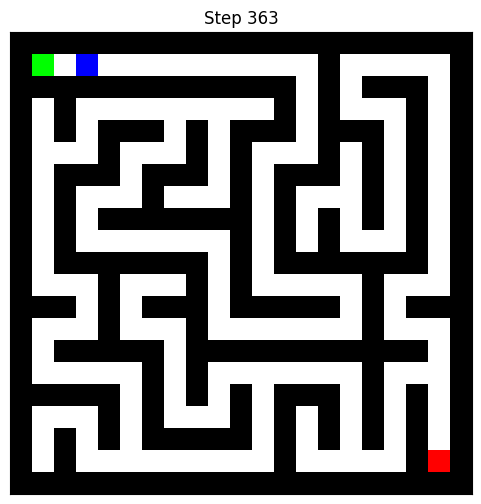

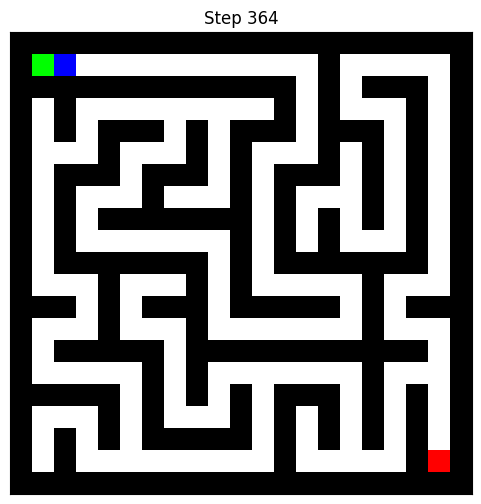

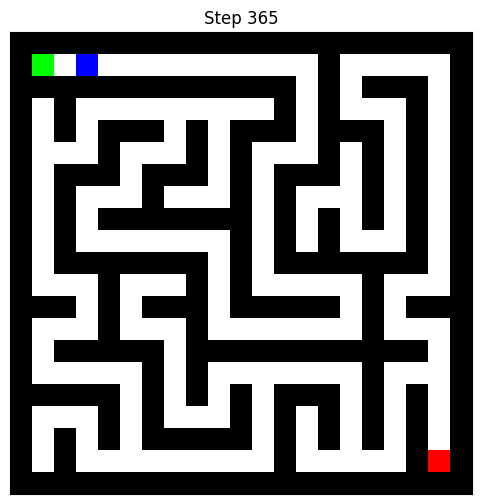

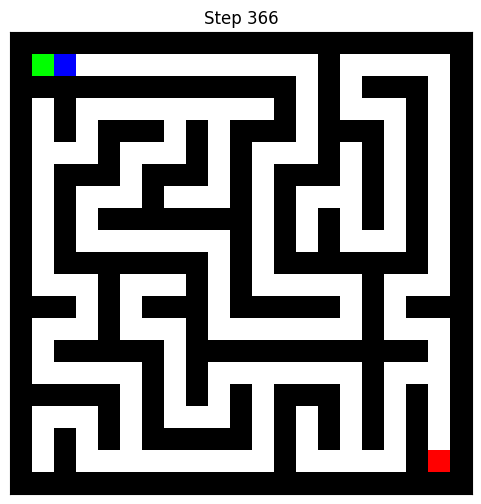

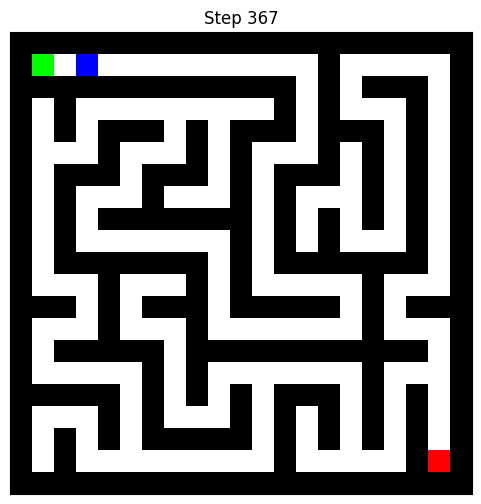

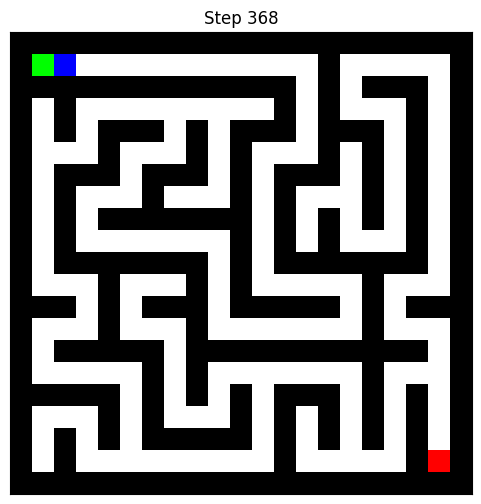

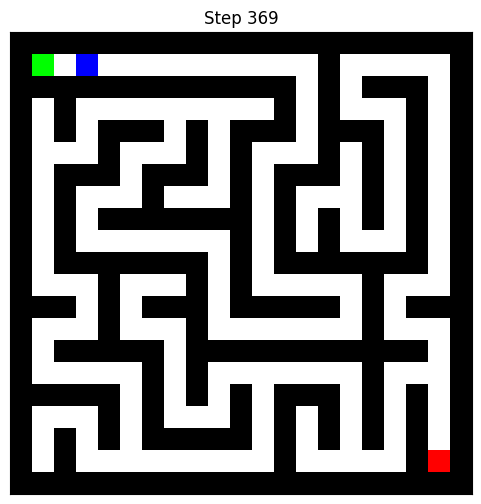

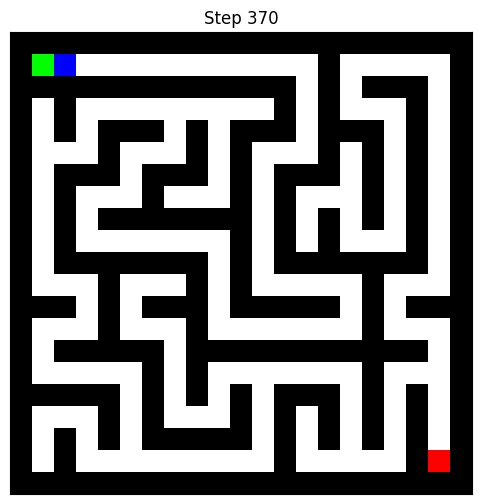

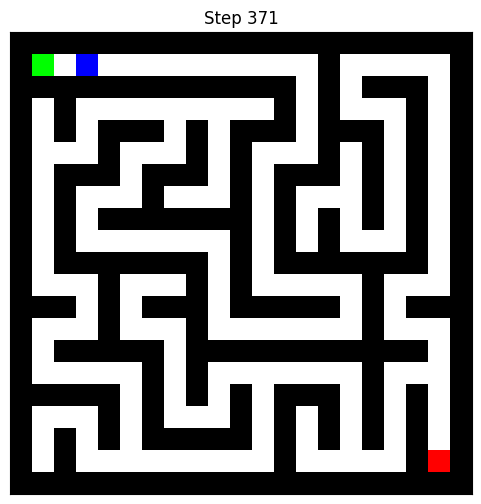

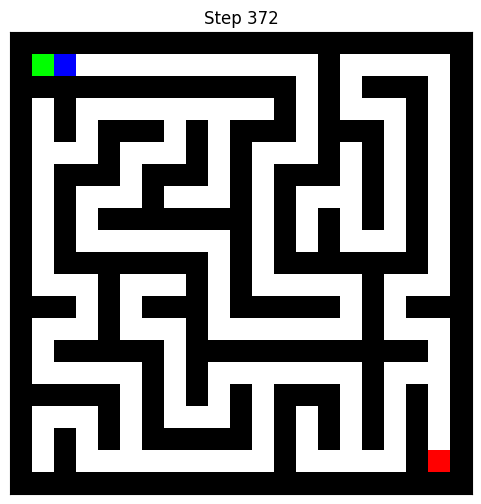

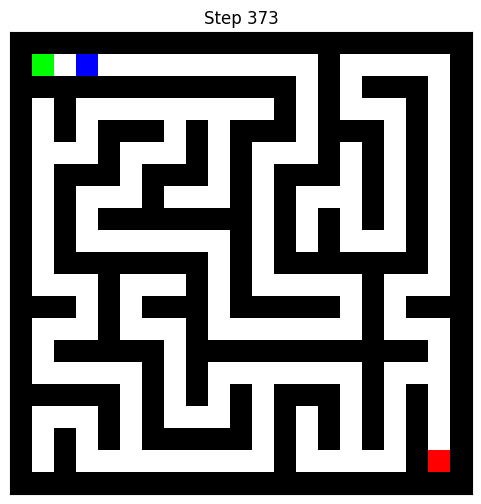

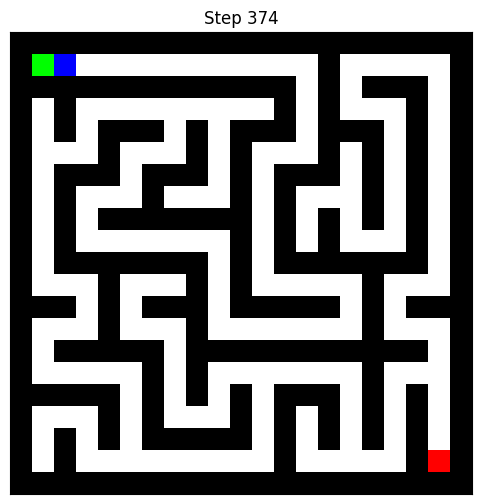

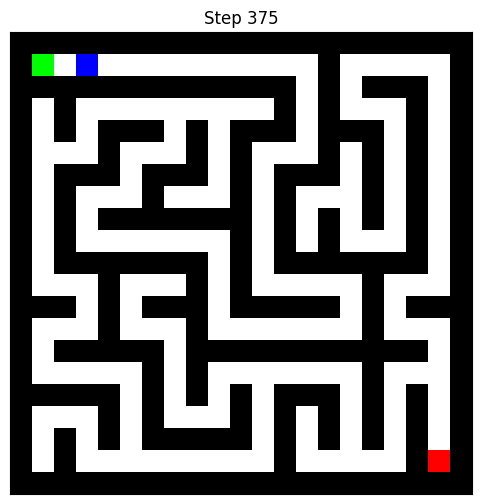

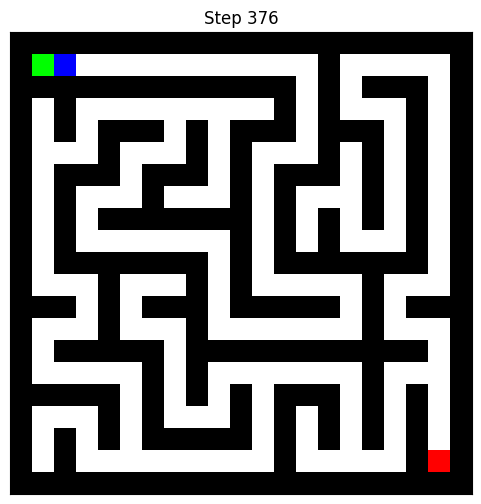

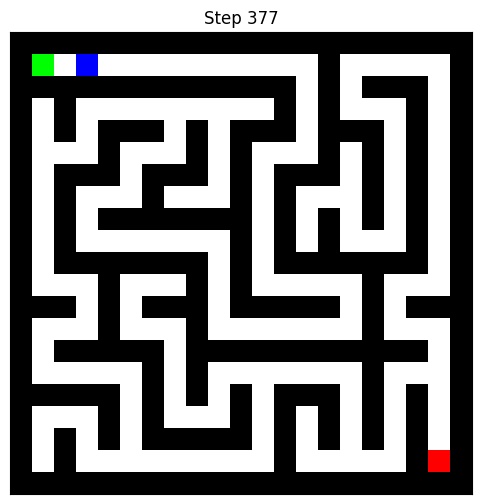

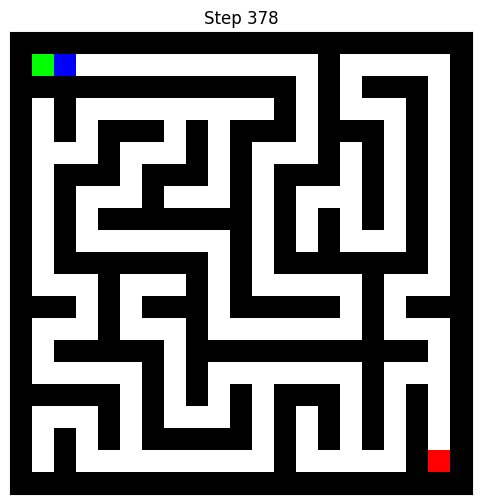

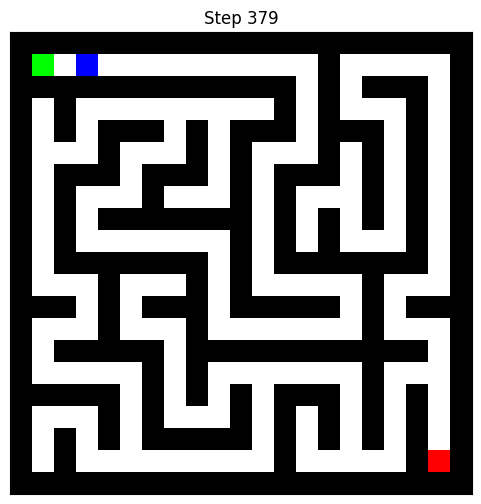

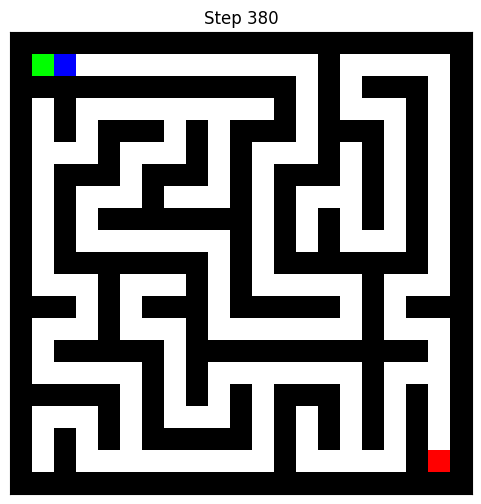

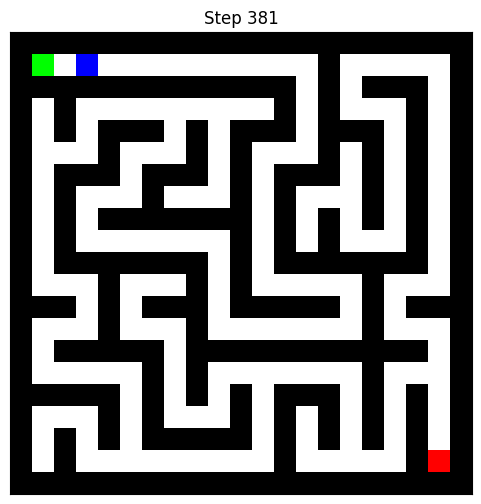

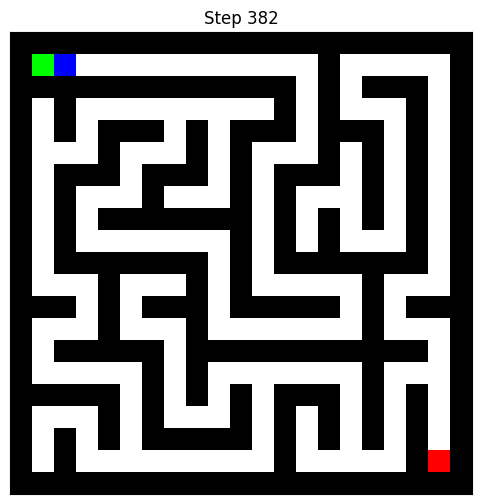

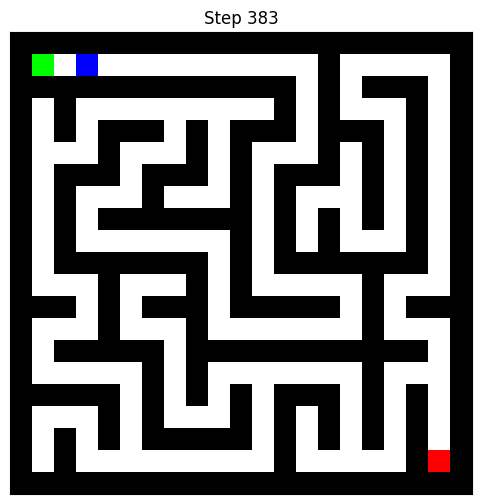

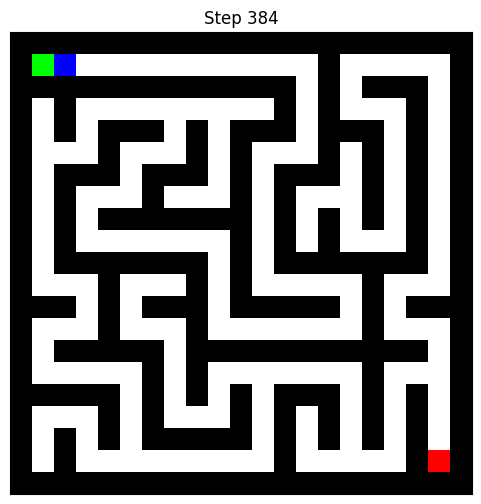

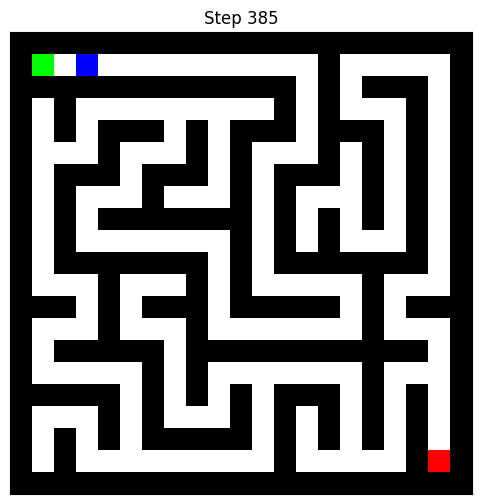

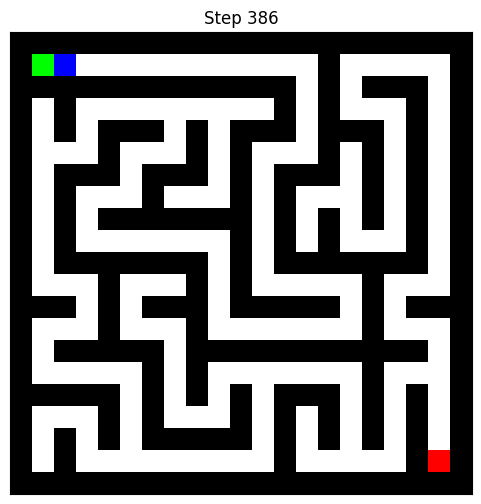

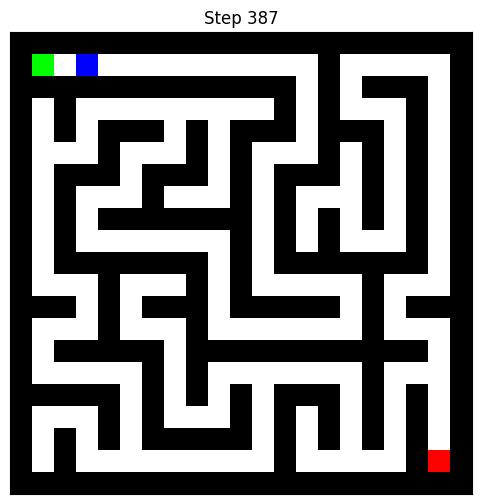

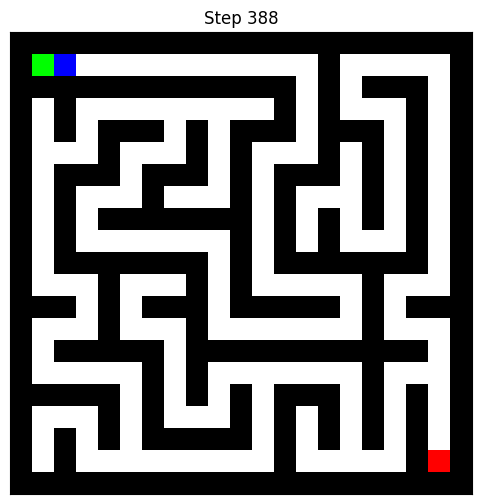

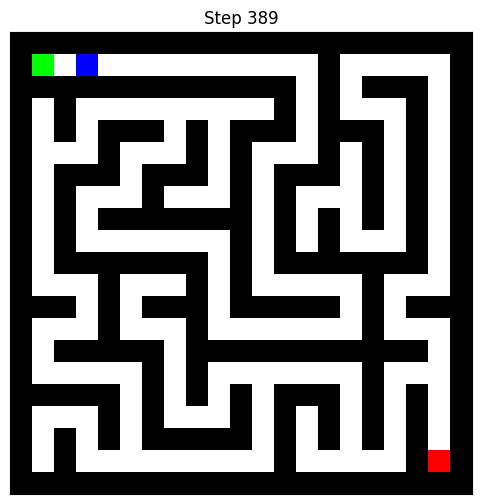

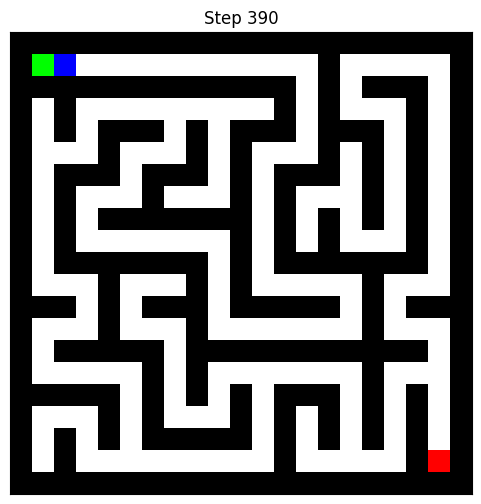

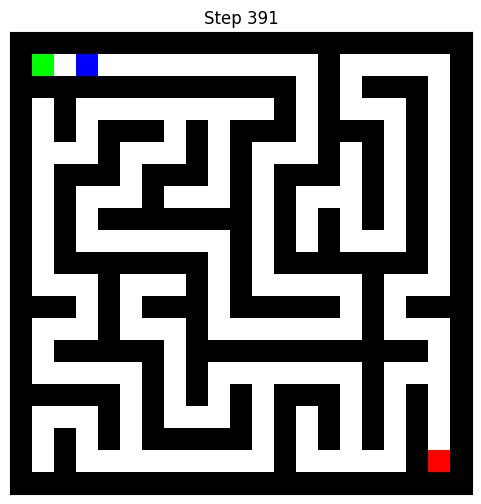

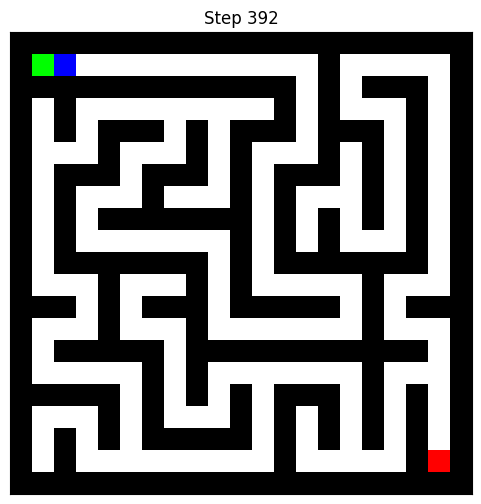

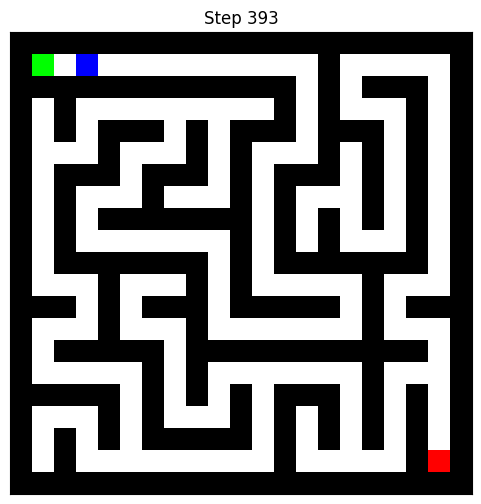

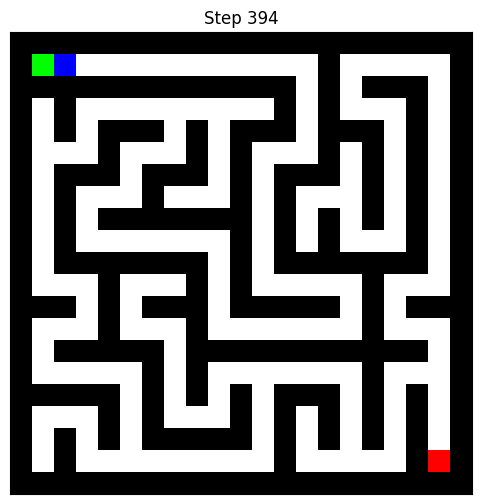

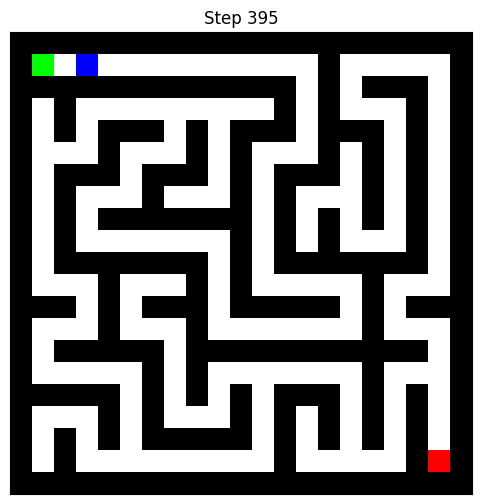

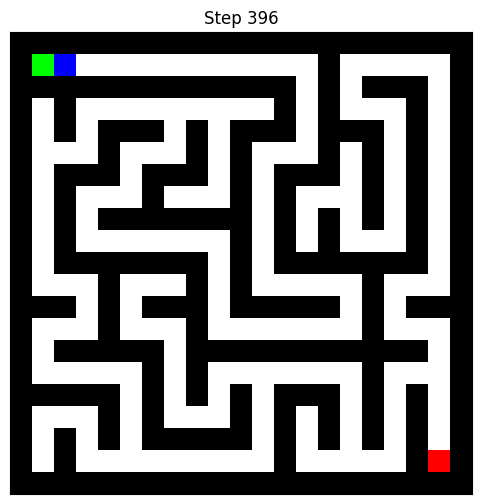

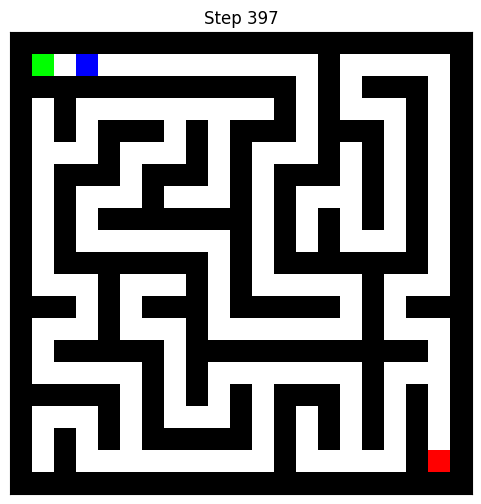

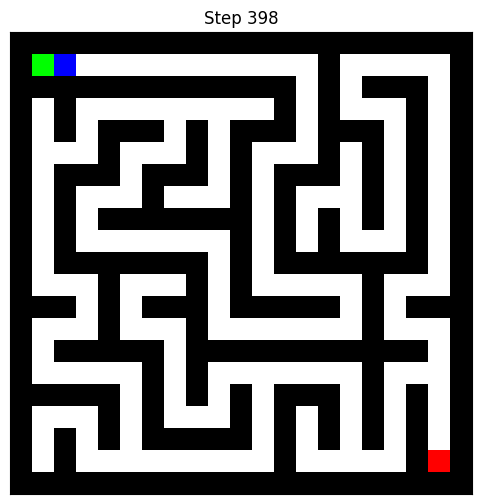

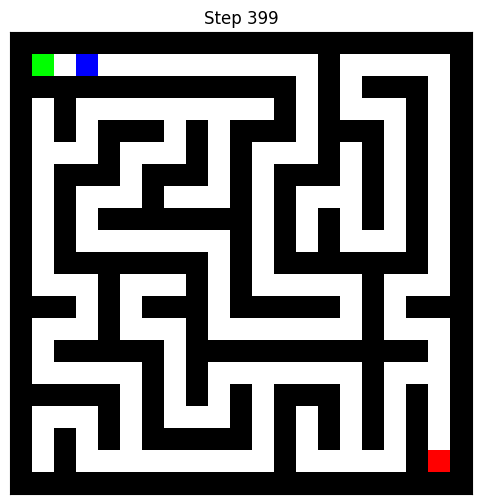

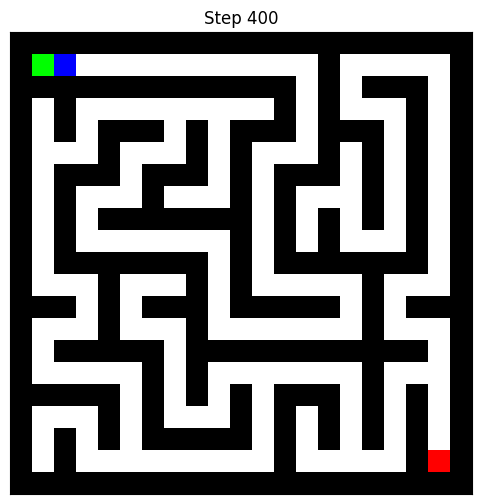

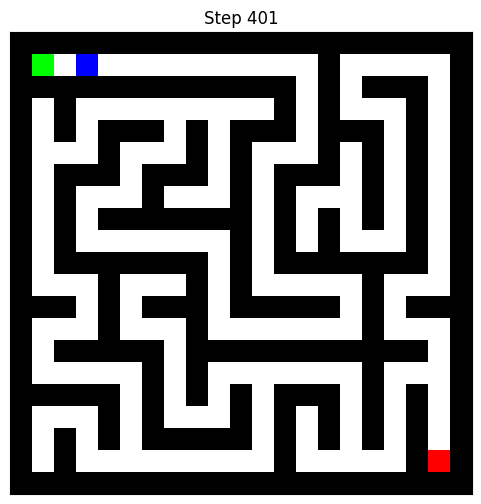

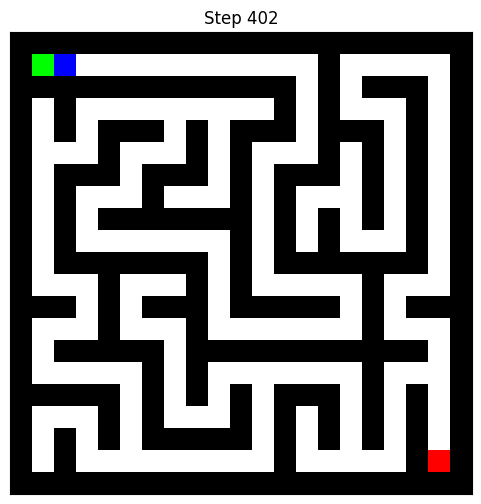

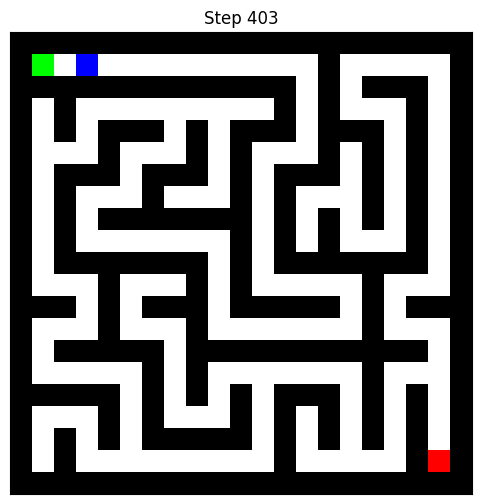

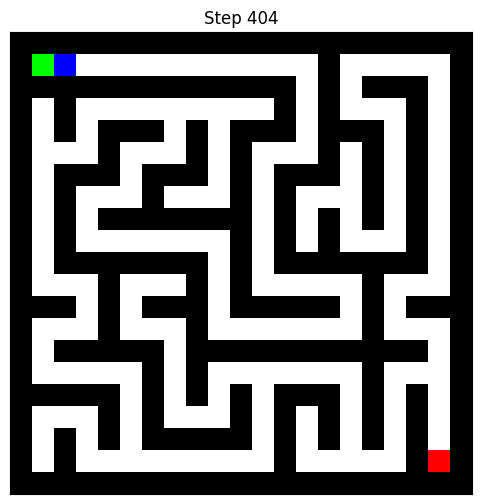

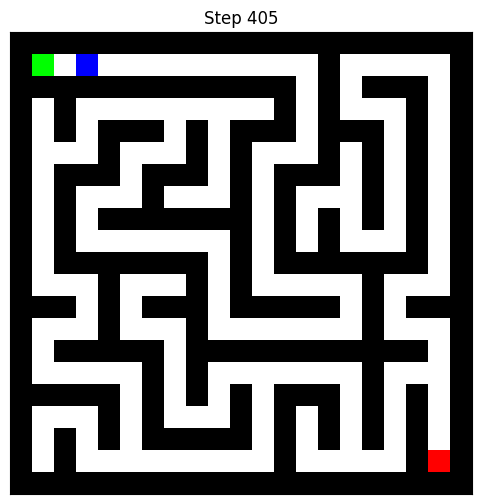

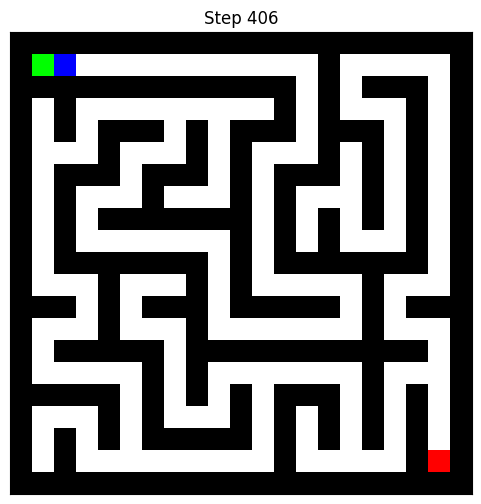

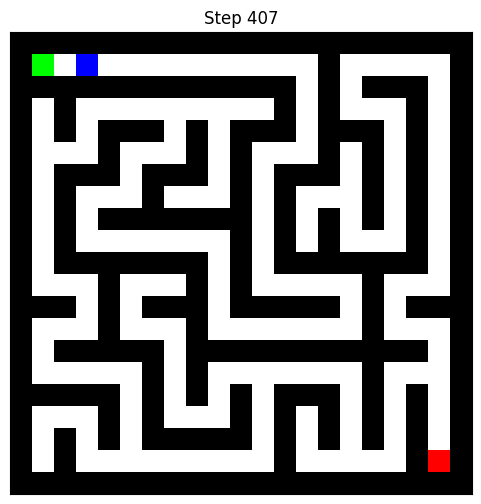

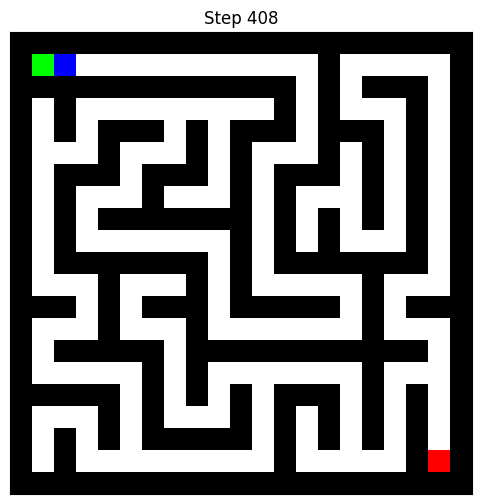

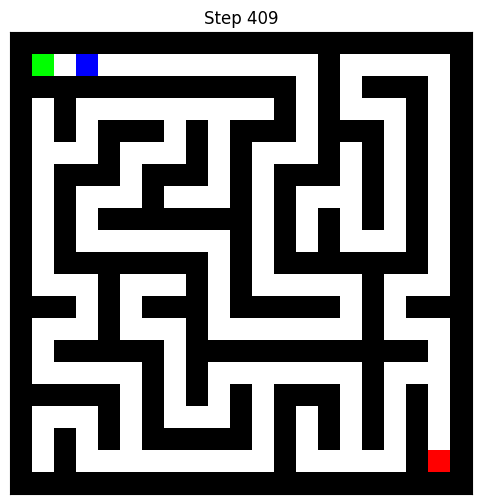

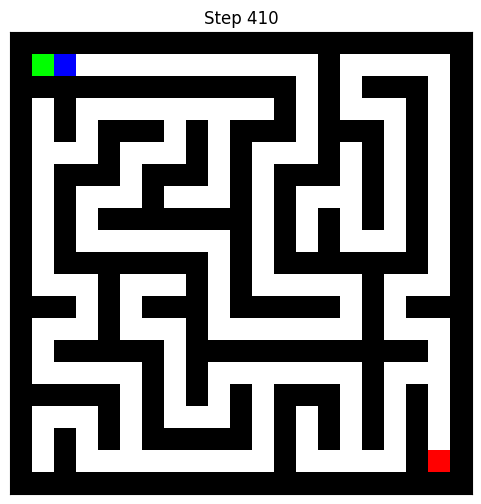

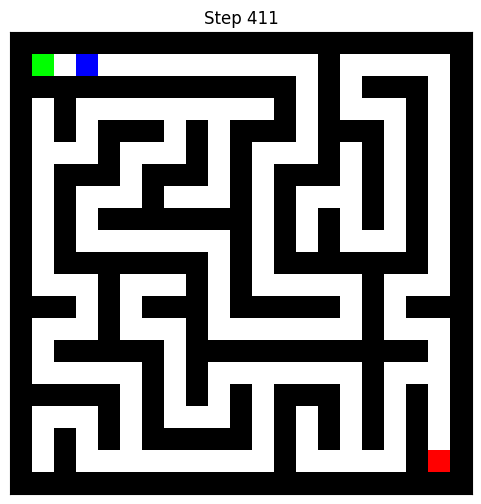

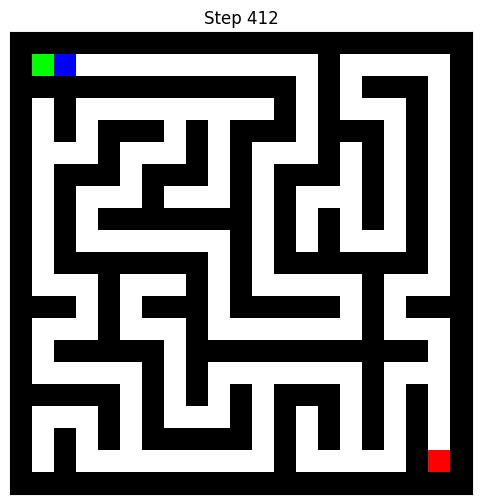

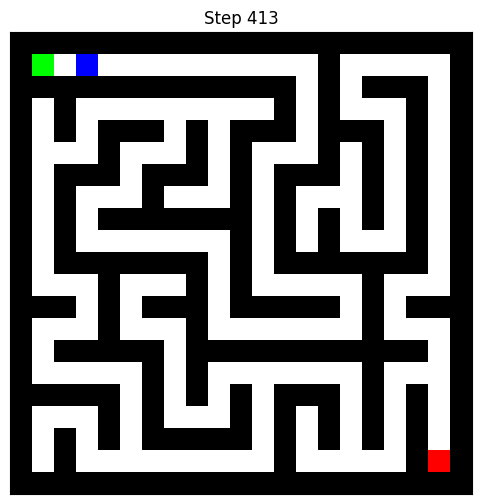

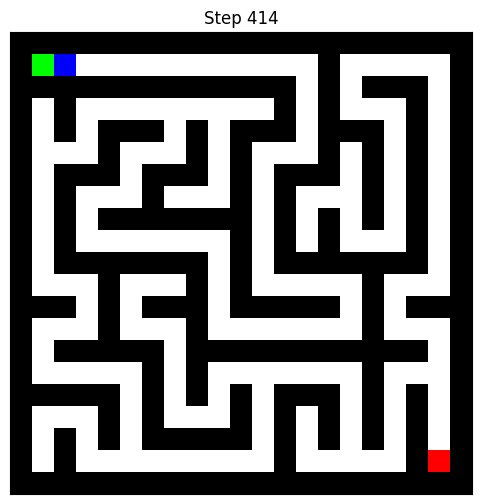

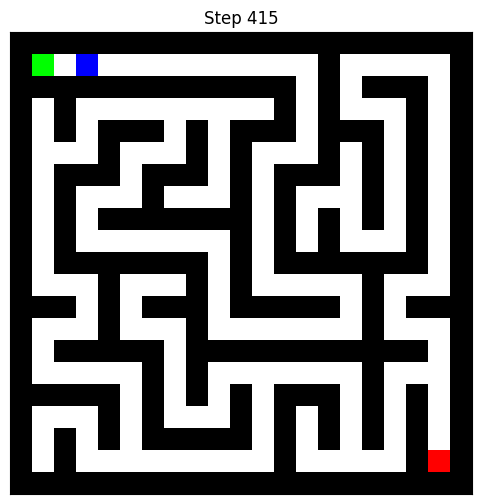

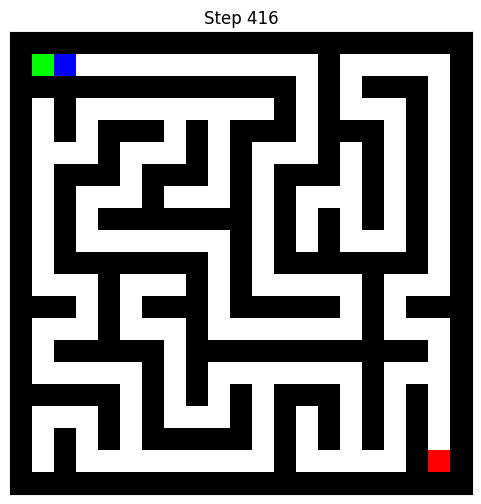

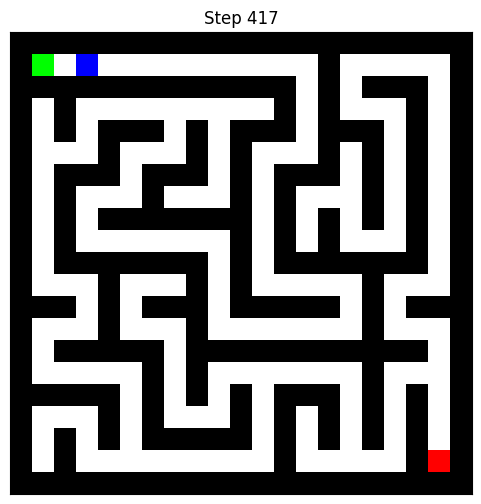

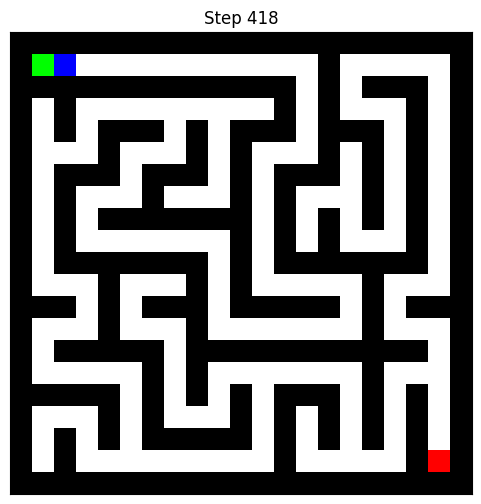

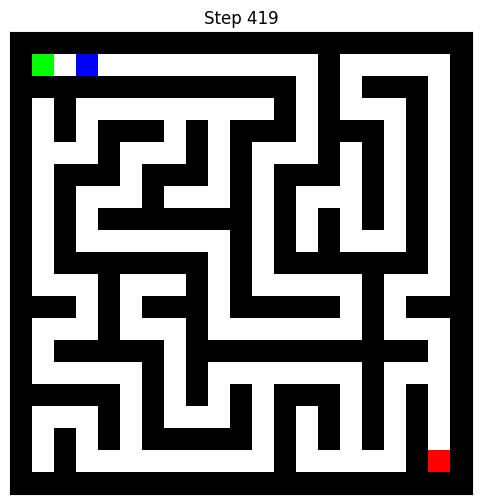

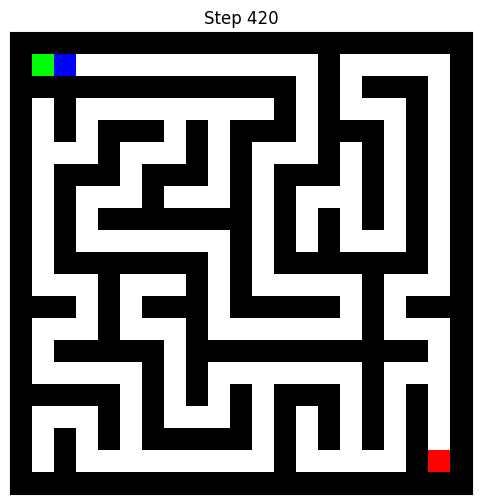

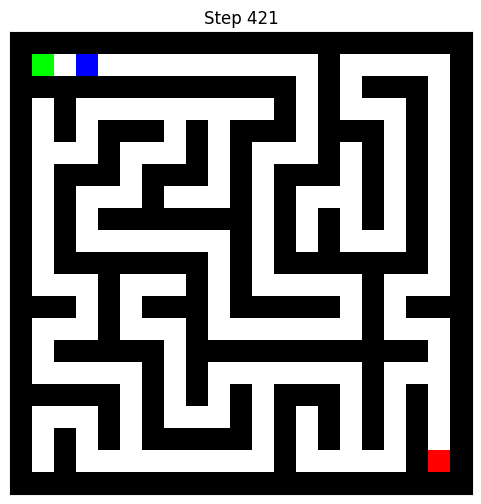

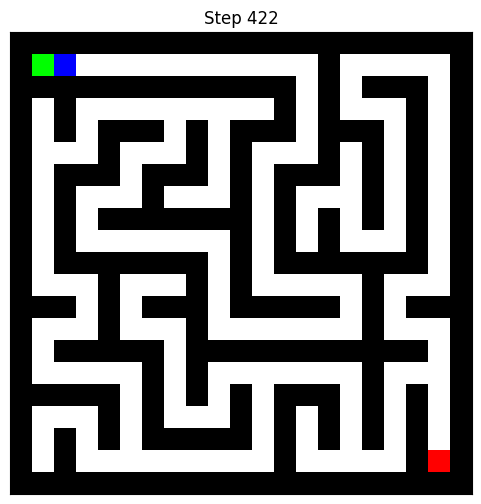

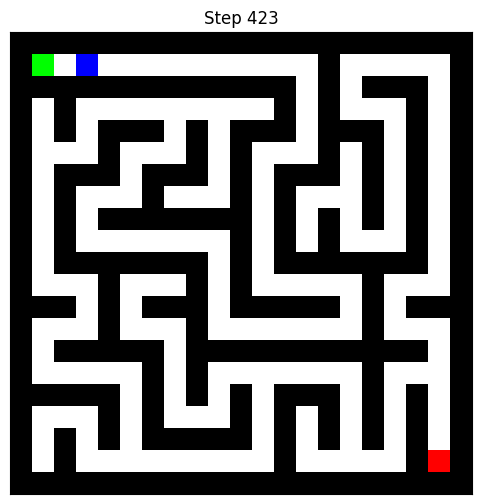

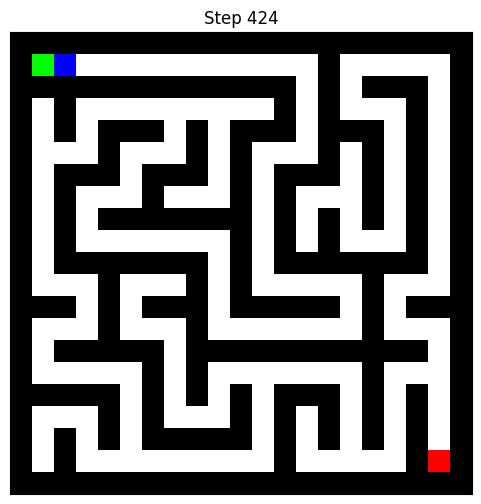

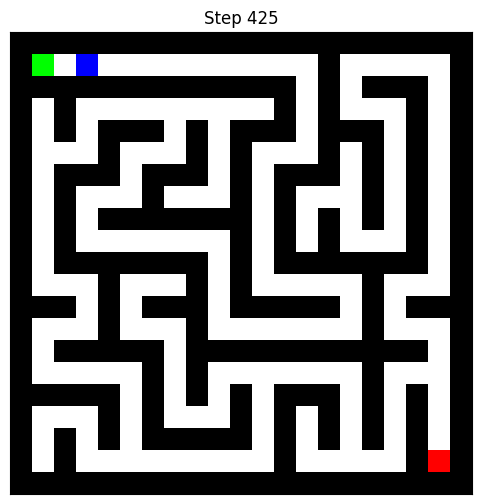

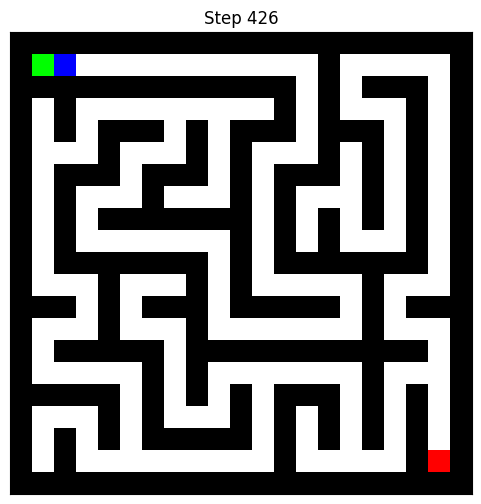

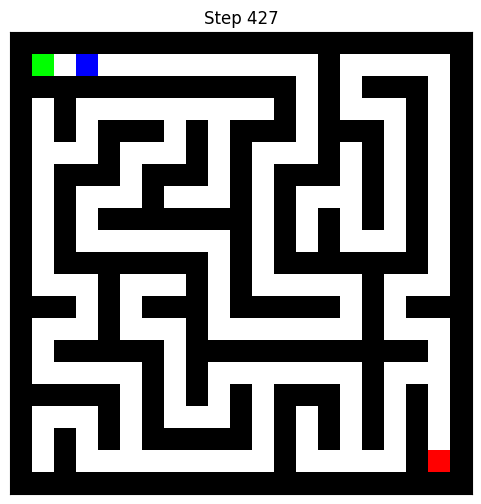

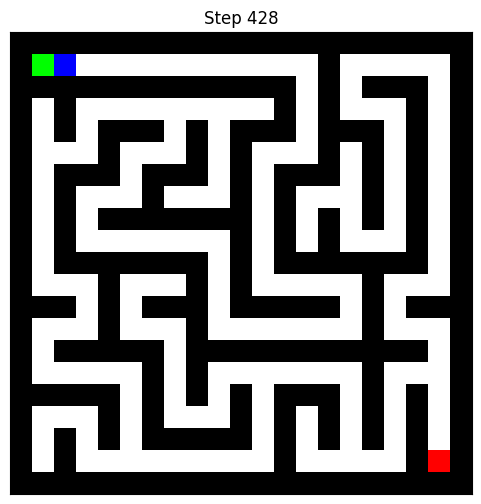

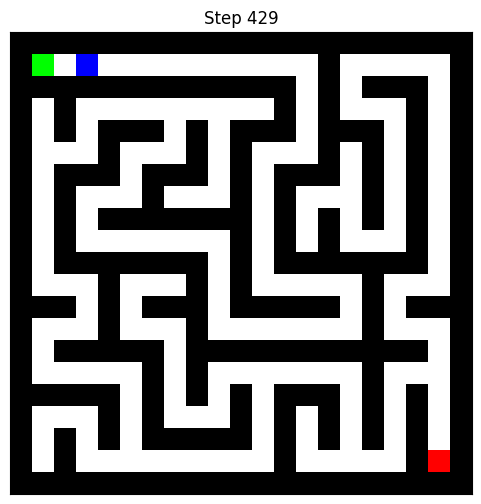

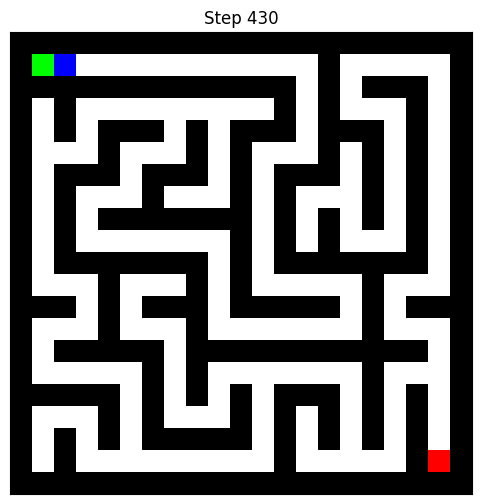

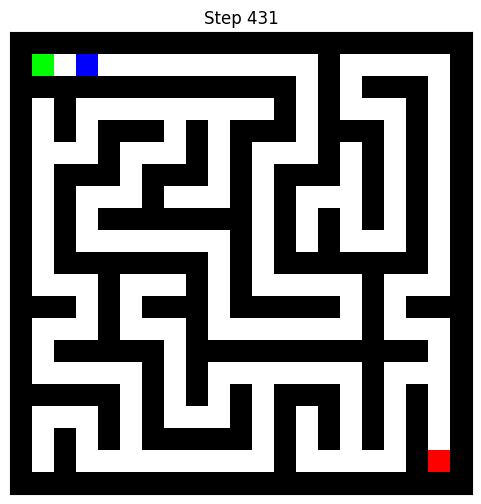

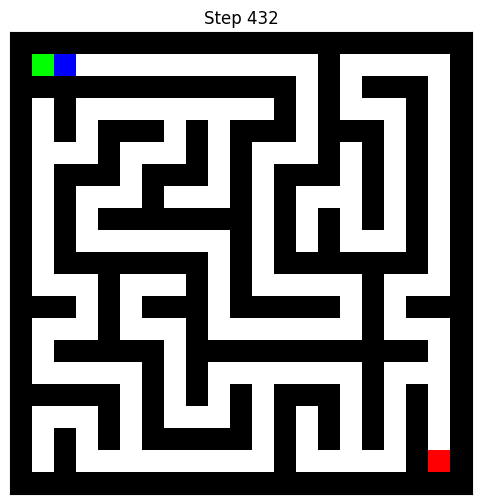

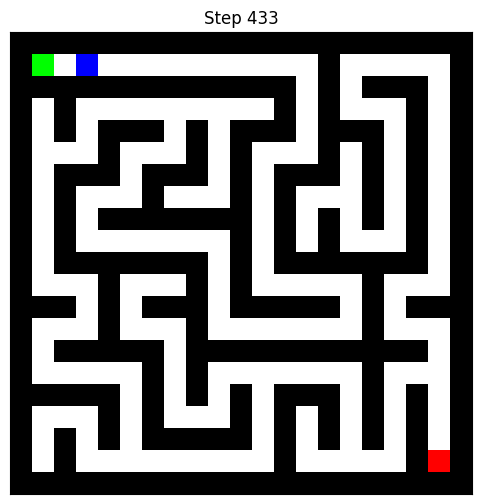

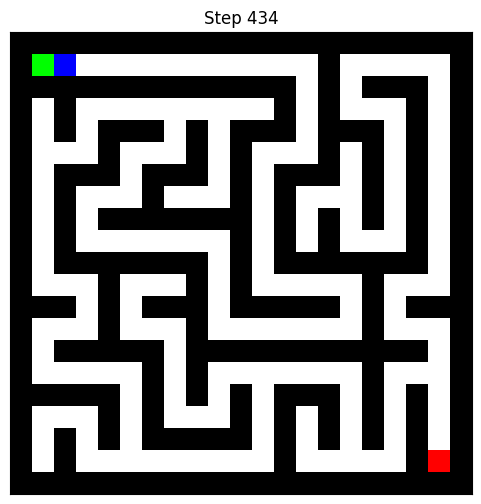

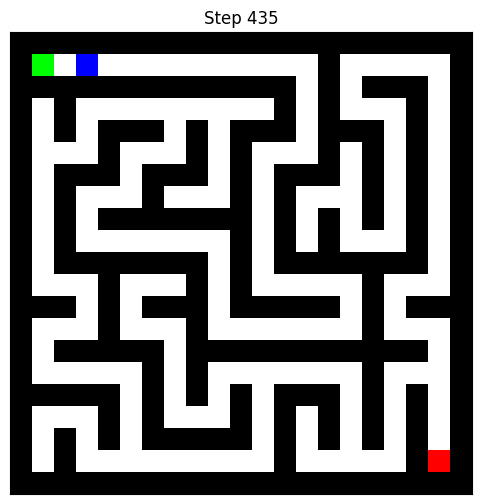

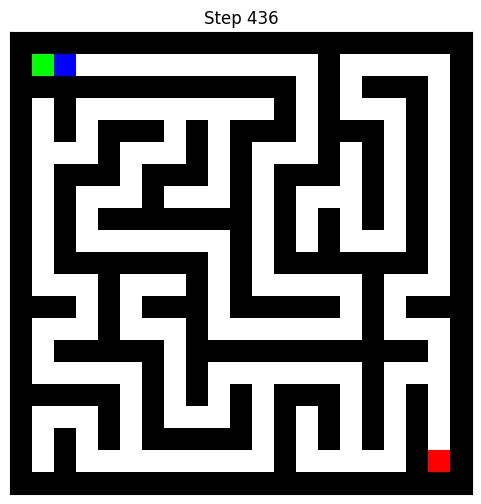

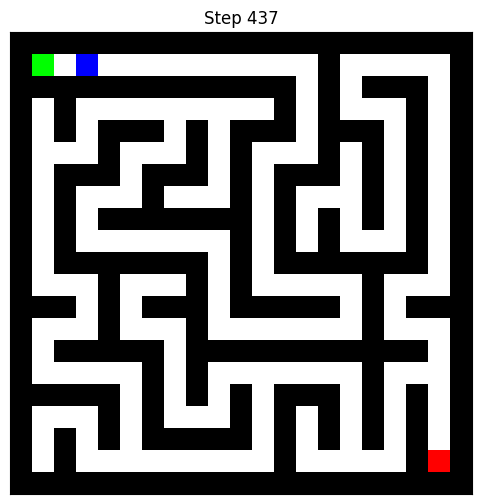

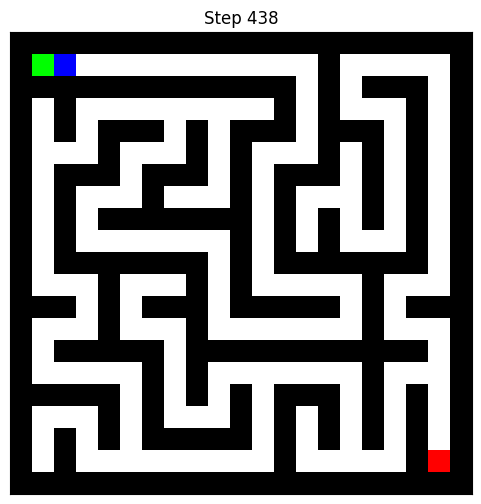

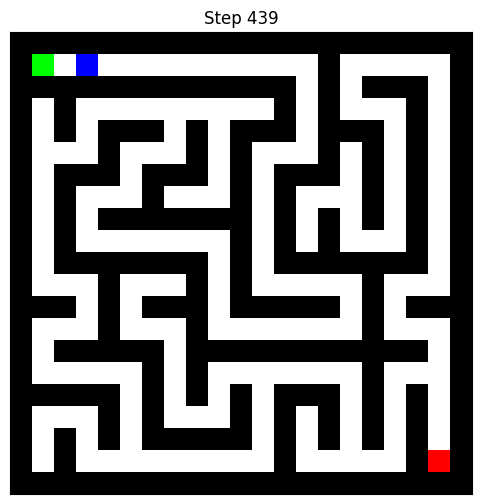

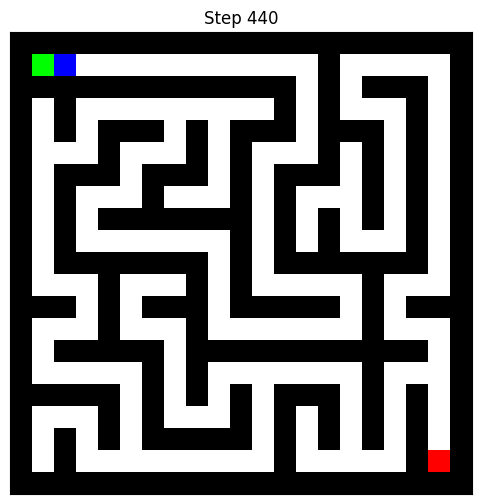

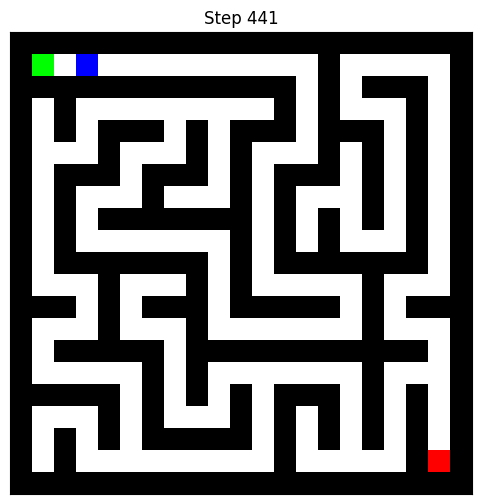

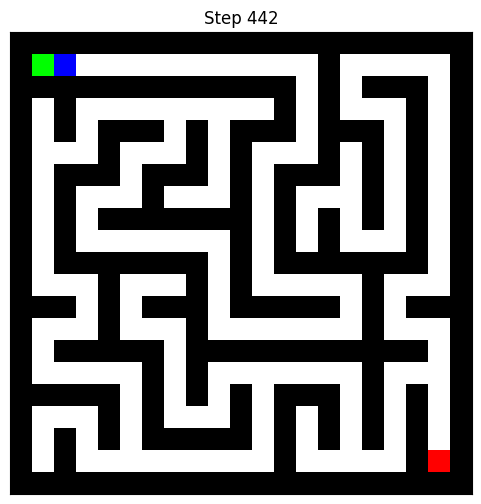

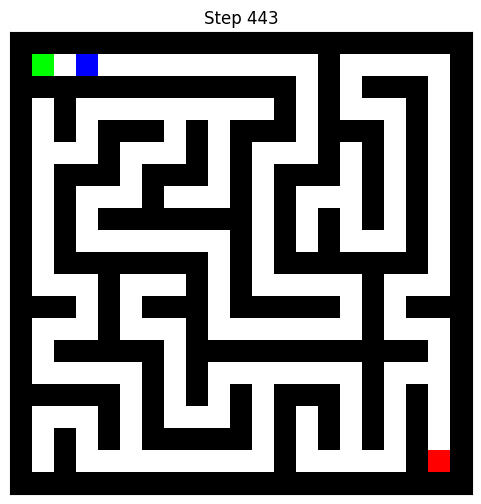

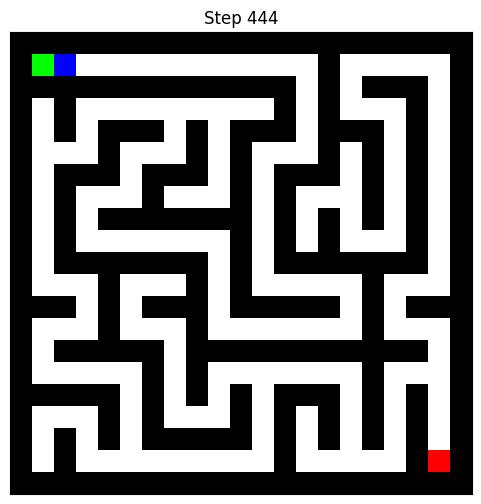

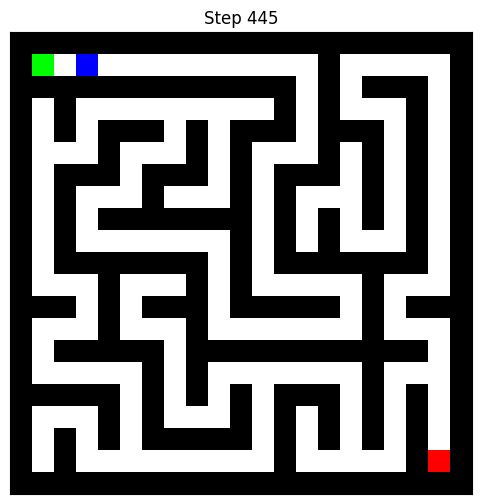

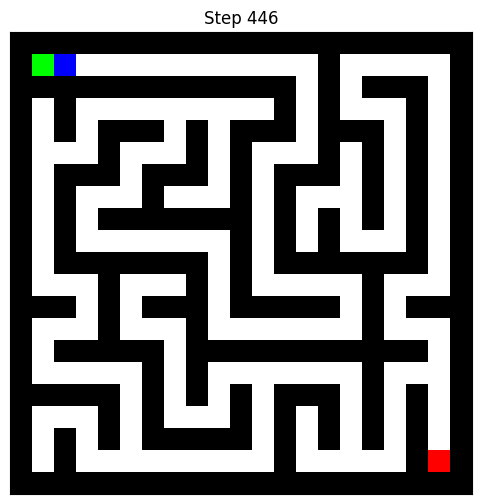

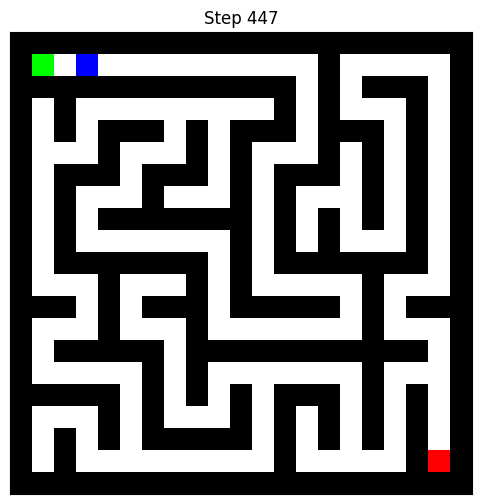

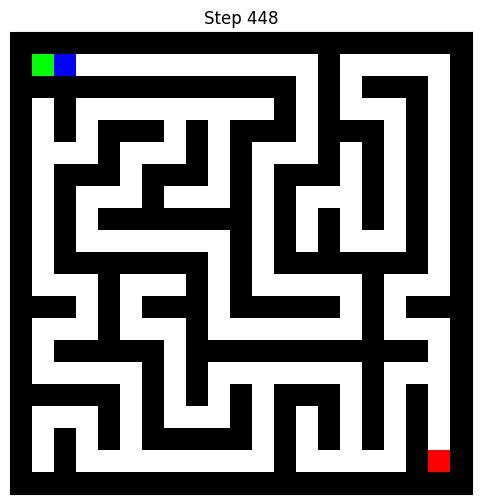

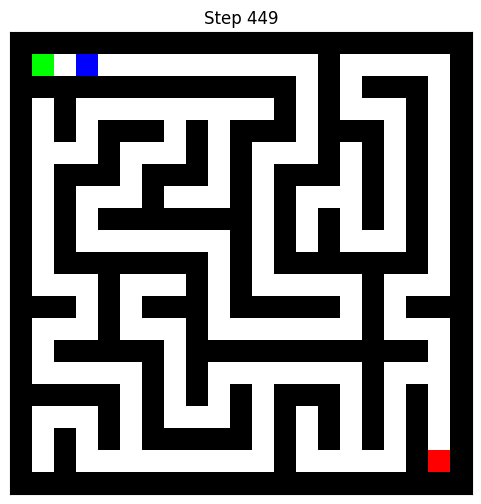

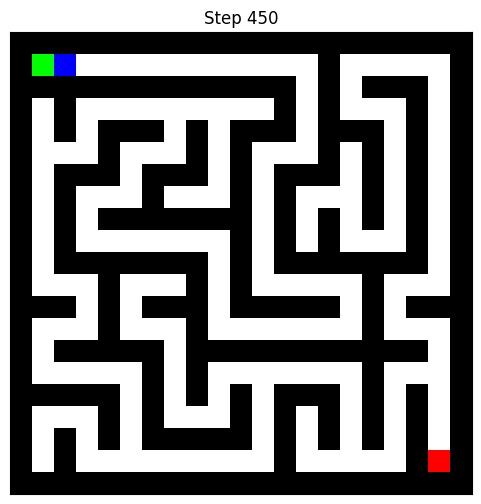

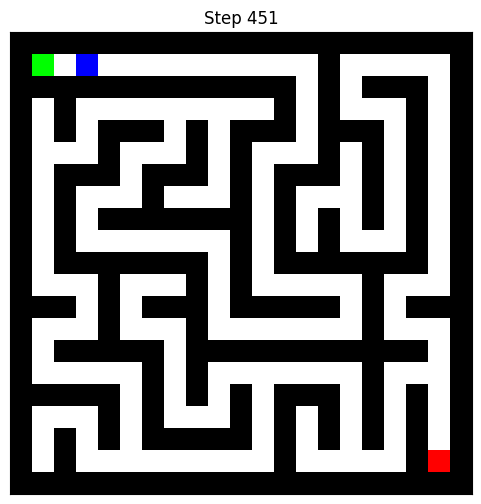

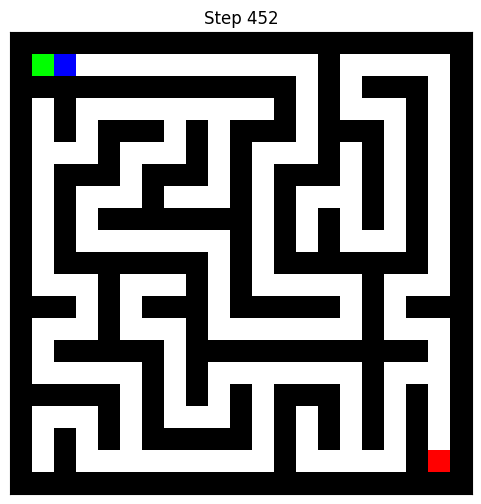

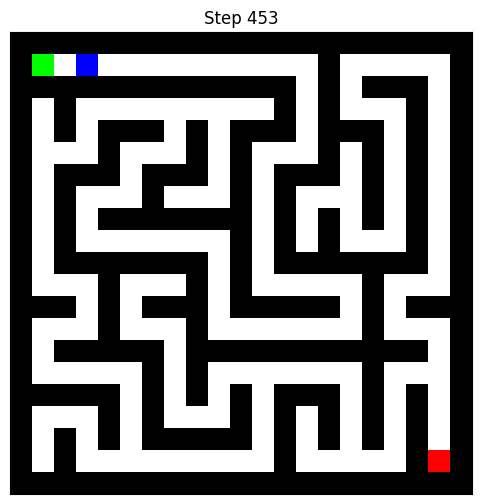

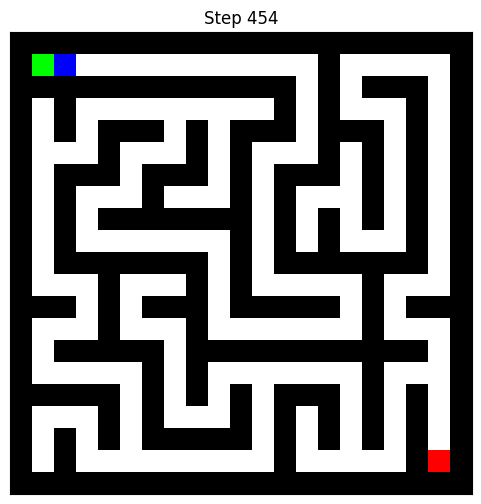

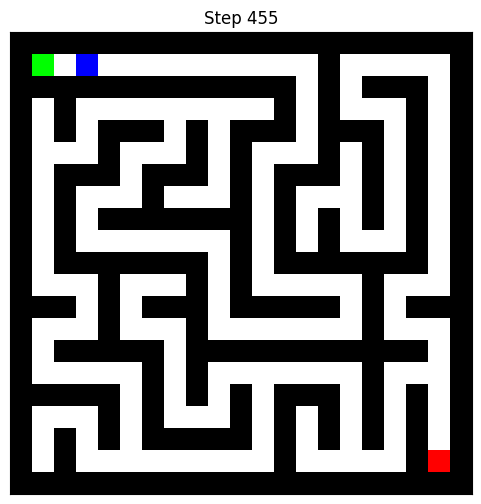

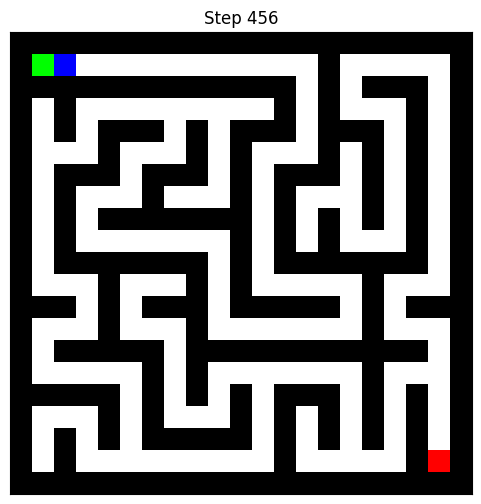

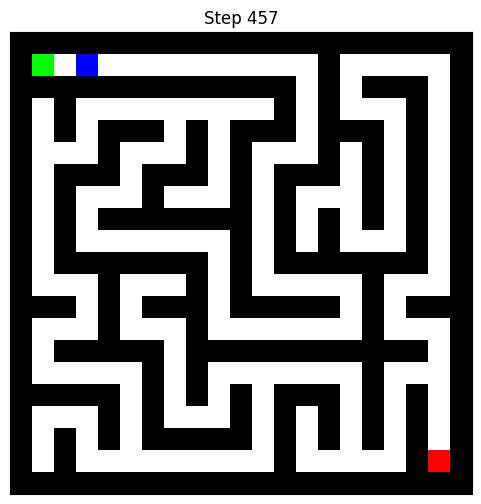

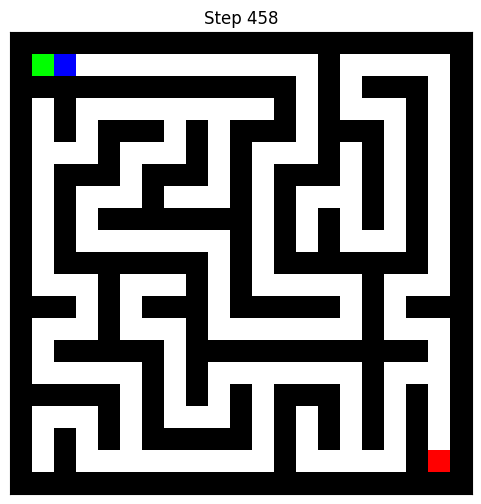

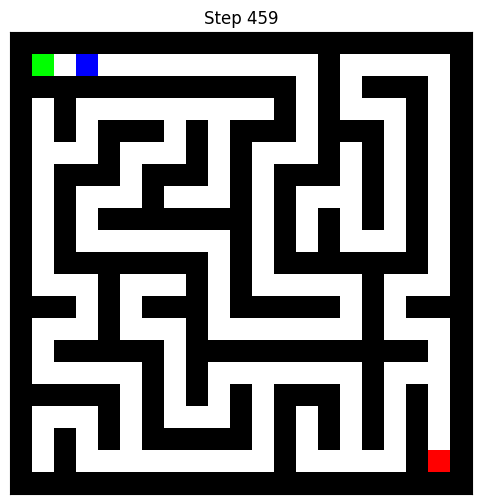

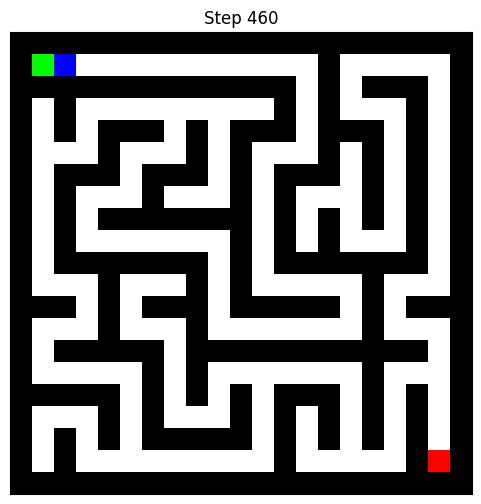

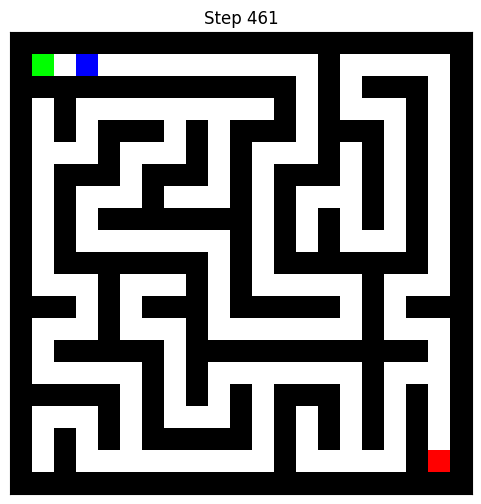

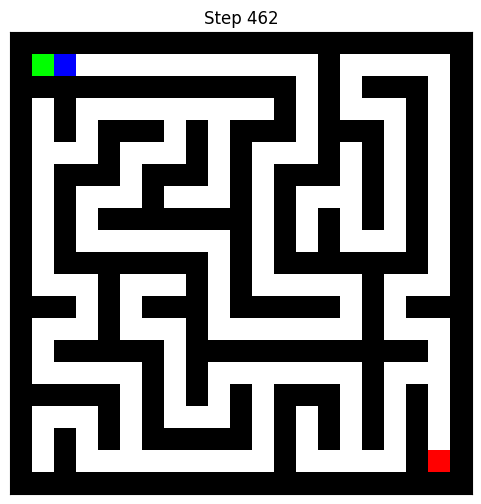

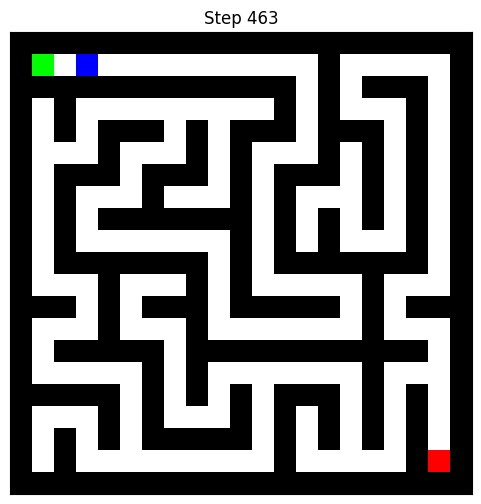

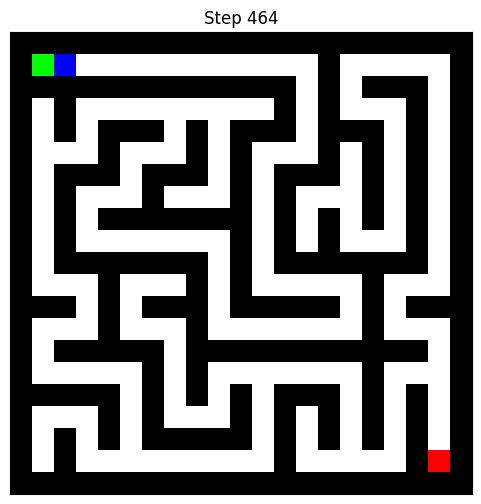

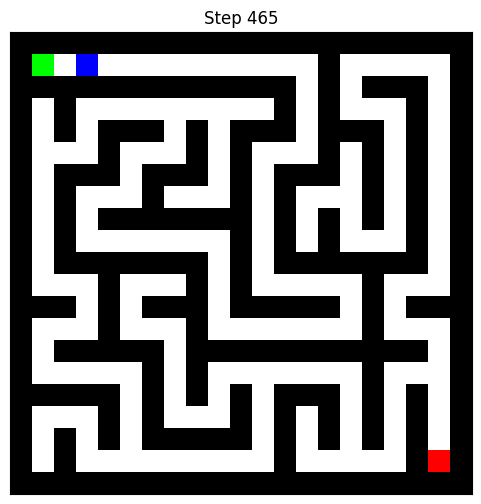

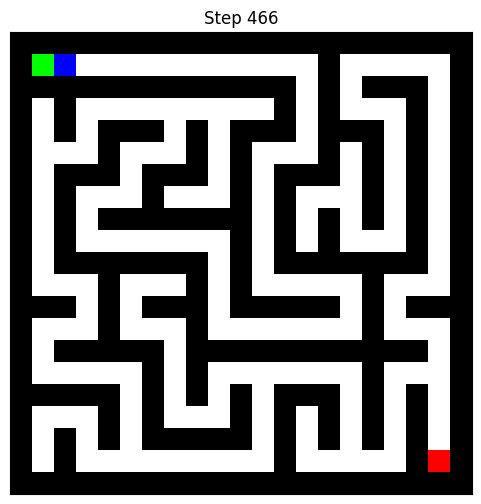

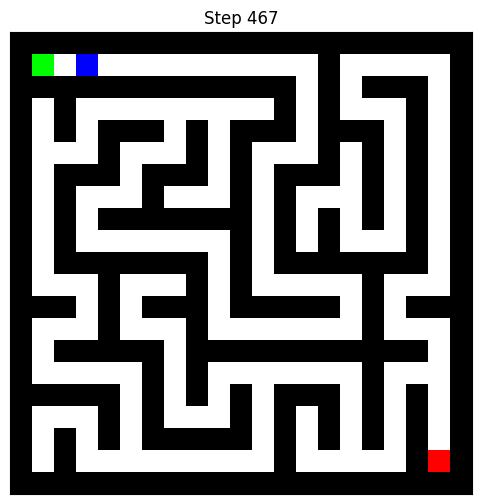

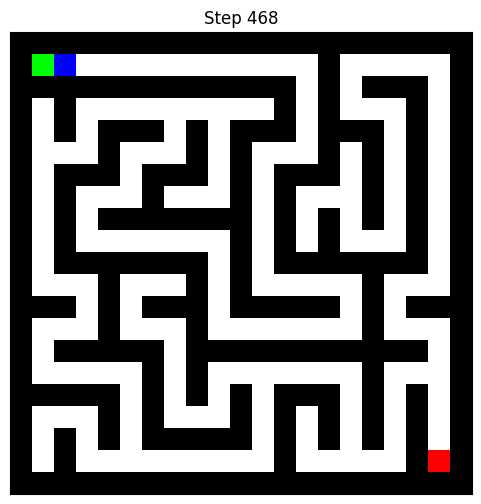

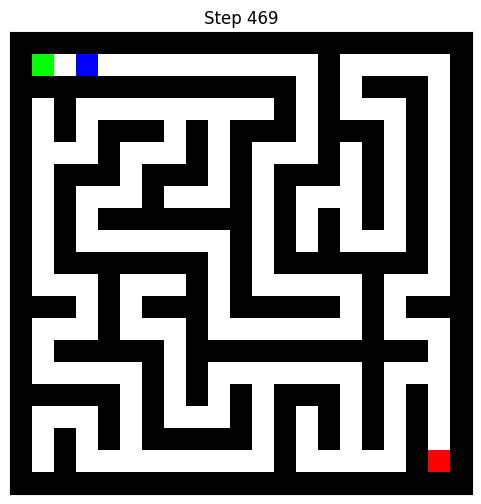

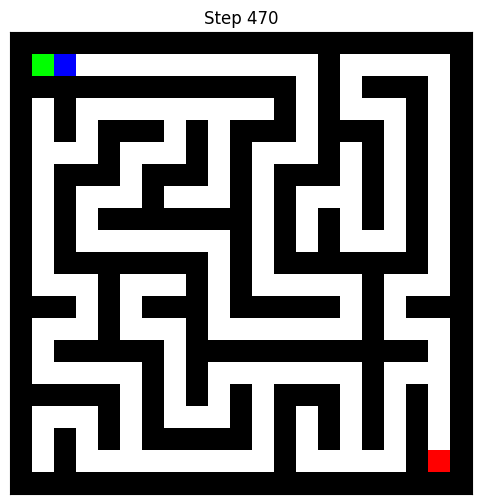

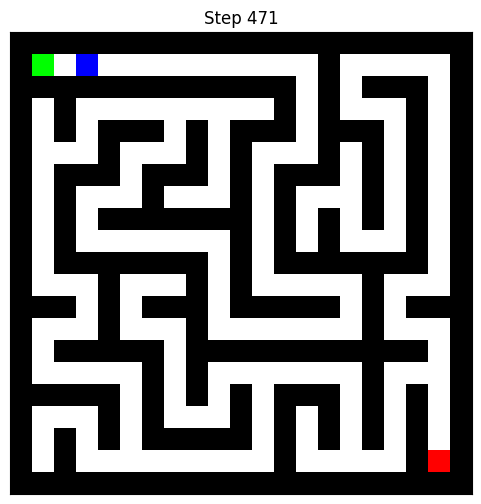

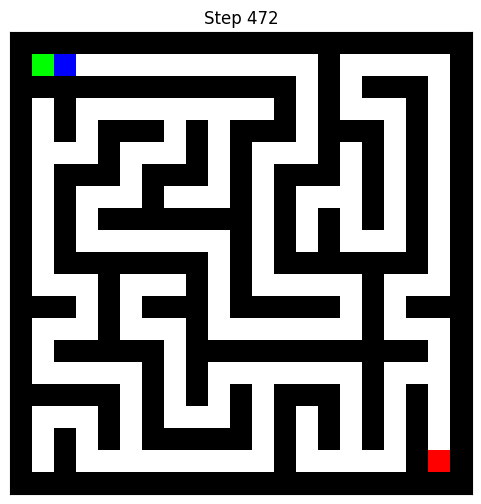

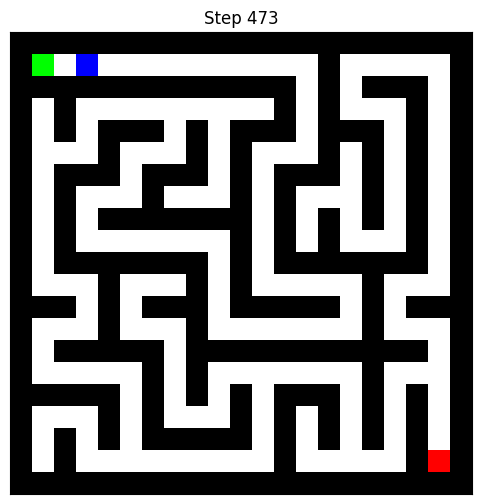

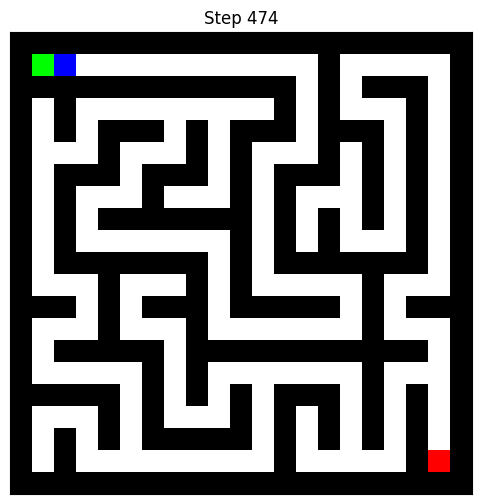

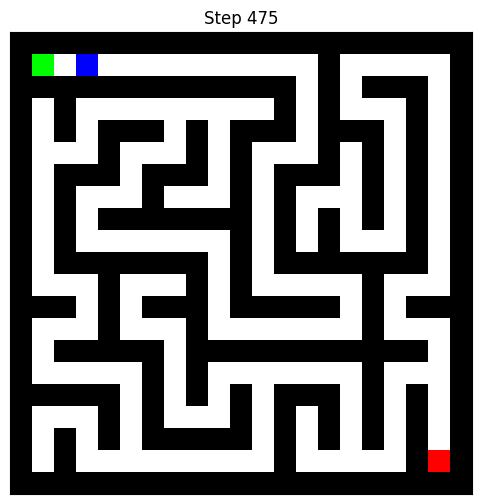

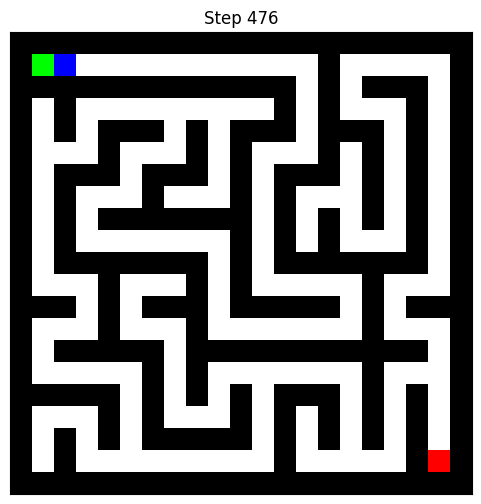

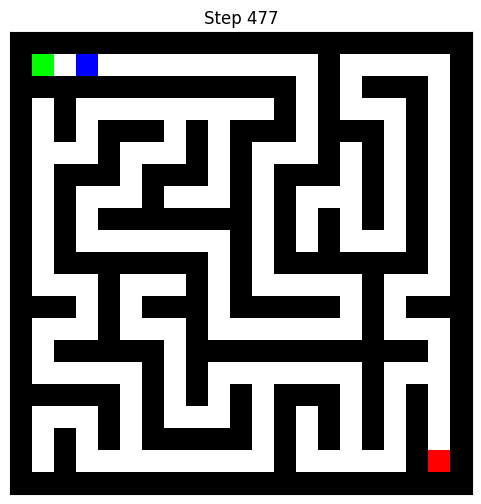

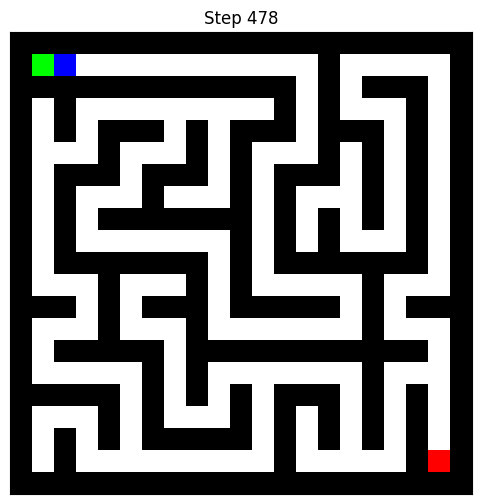

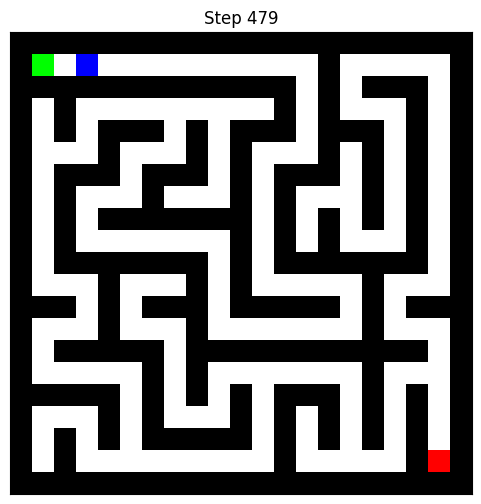

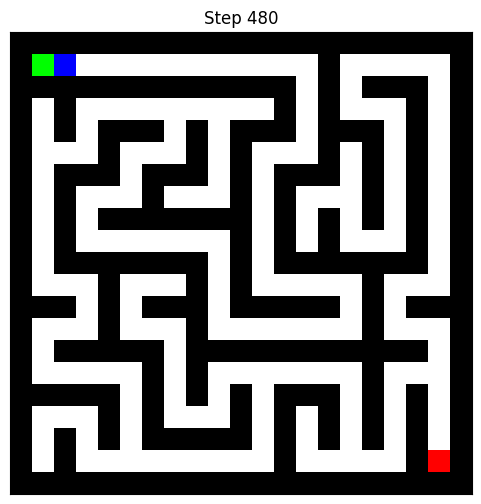

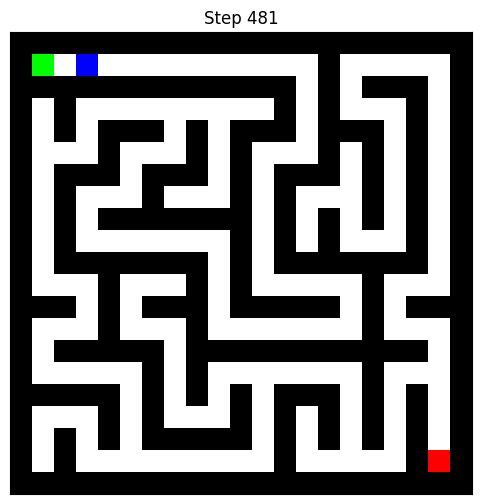

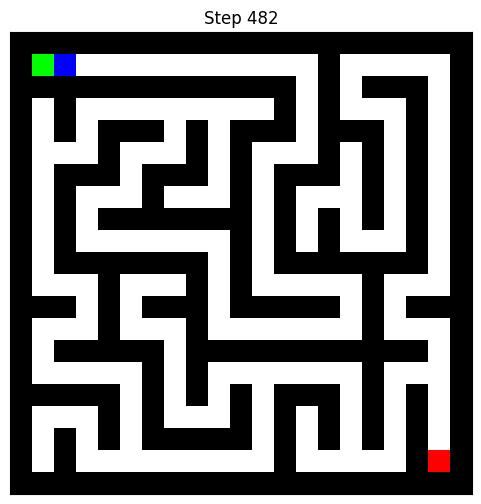

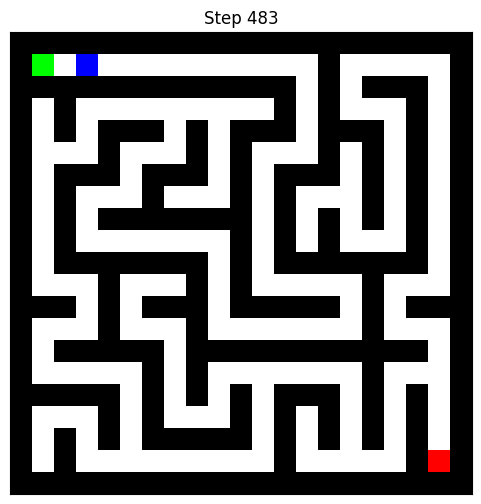

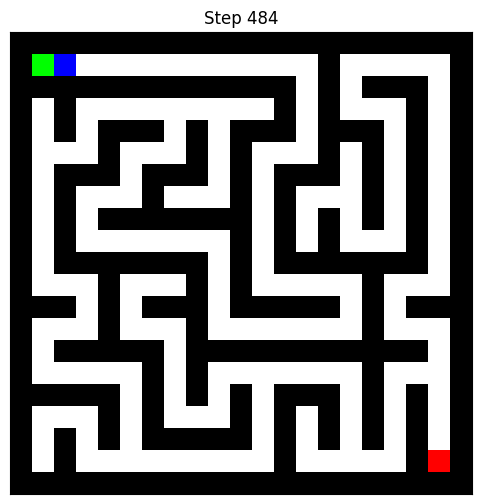

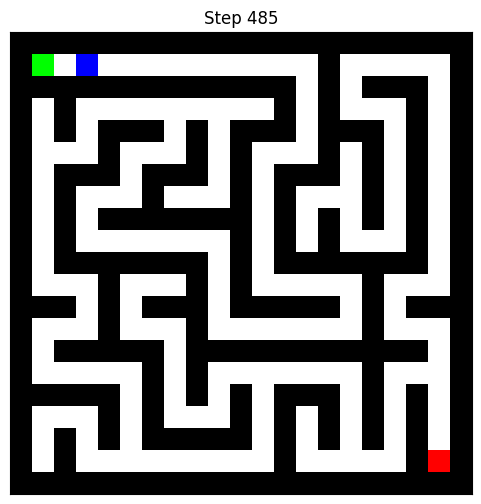

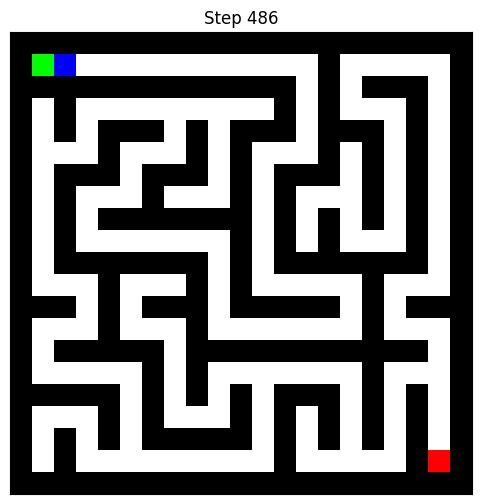

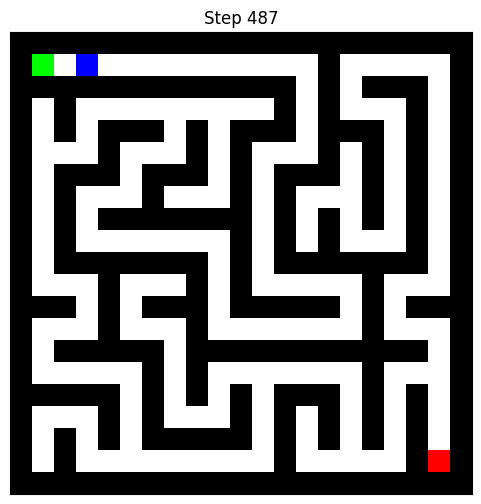

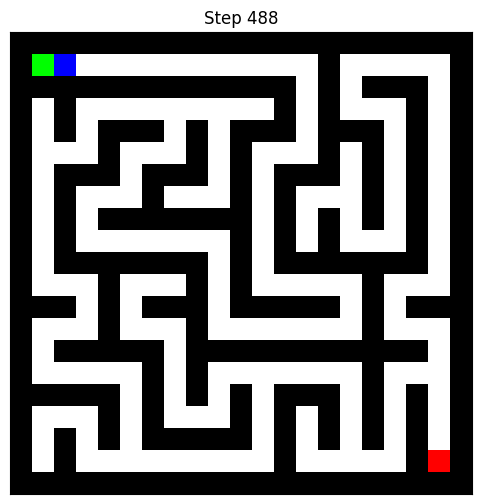

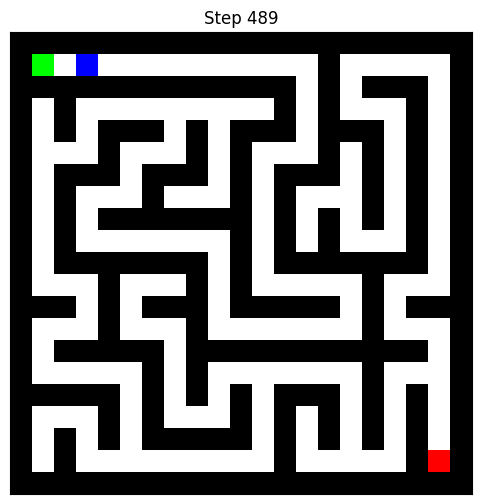

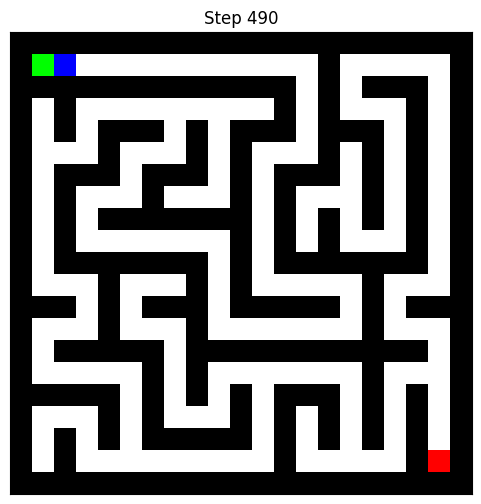

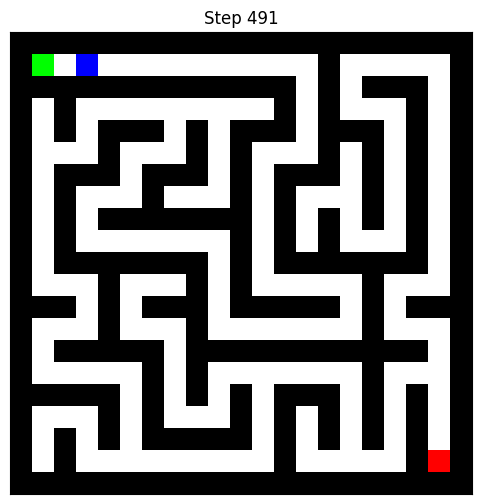

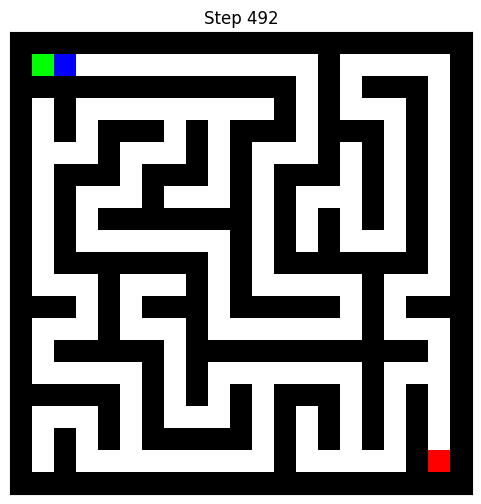

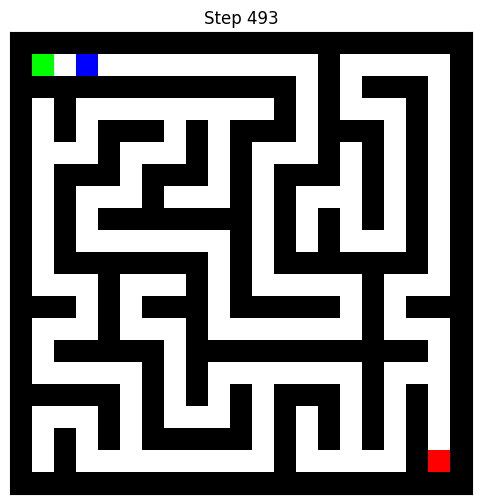

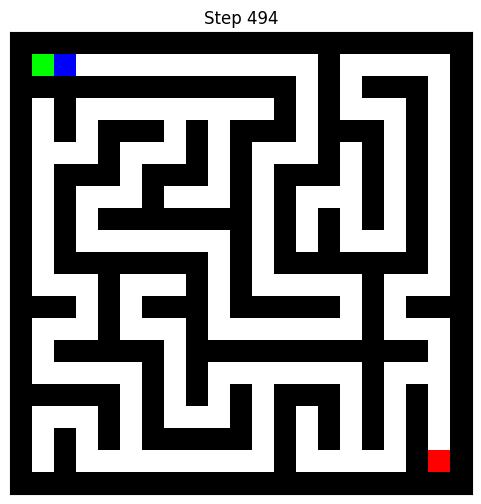

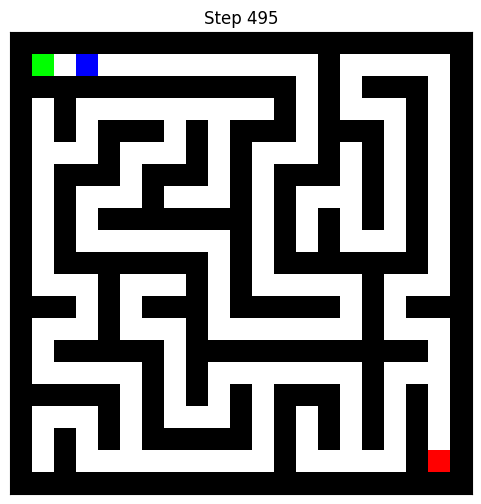

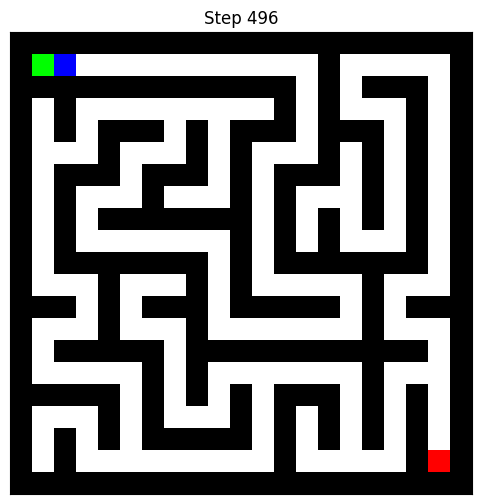

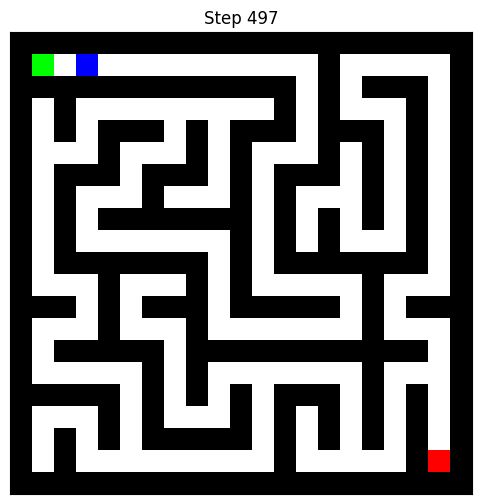

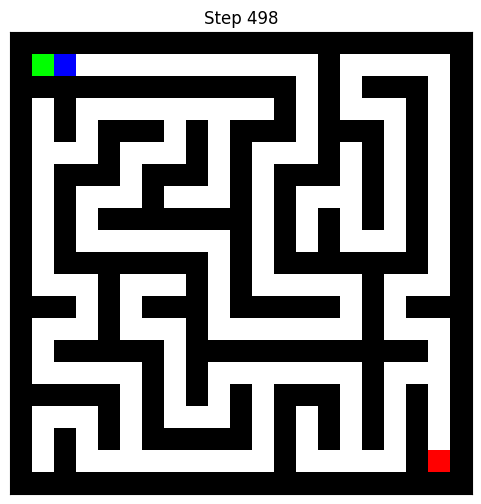

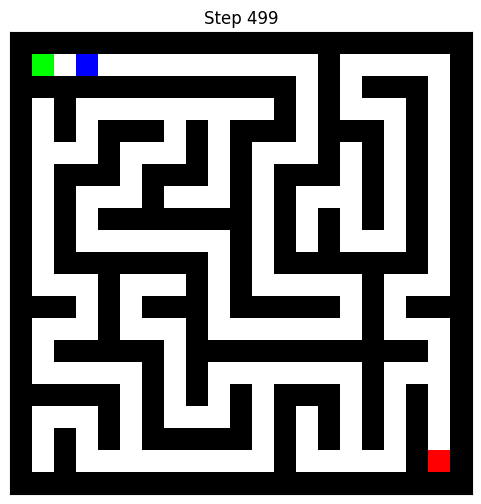

❌ Failed (Maximum Steps Reached)
Total Steps : 500
Total Reward: -25.00000000000022


In [7]:
# ============================================================
# Cell 5 - Test Trained PPO Agent
# ============================================================

from stable_baselines3 import PPO
from gymnasium.wrappers import FlattenObservation
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# Create Test Environment
# ------------------------------------------------------------

test_env = MazeEnv(21)
test_env = FlattenObservation(test_env)

# Load trained model
model = PPO.load("maze_ppo")

# Reset environment
obs, info = test_env.reset()

done = False
step = 0
total_reward = 0

while not done:

    # Predict action
    action, _ = model.predict(obs, deterministic=True)

    # Take action
    obs, reward, terminated, truncated, info = test_env.step(action)

    total_reward += reward
    done = terminated or truncated

    # Show maze
    plt.figure(figsize=(6,6))

    img = np.zeros((21,21,3))

    maze = test_env.unwrapped.maze

    img[maze==1] = [0,0,0]      # Wall
    img[maze==0] = [1,1,1]      # Path
    img[maze==2] = [0,1,0]      # Start
    img[maze==3] = [1,0,0]      # Goal

    ax, ay = test_env.unwrapped.agent_pos
    img[ax, ay] = [0,0,1]       # Agent

    plt.imshow(img)
    plt.title(f"Step {step}")
    plt.xticks([])
    plt.yticks([])
    plt.show()

    step += 1

    time.sleep(0.05)

# ------------------------------------------------------------
# Result
# ------------------------------------------------------------

print("="*50)

if terminated:
    print("🎉 SUCCESS! Goal Reached")
else:
    print("❌ Failed (Maximum Steps Reached)")

print("Total Steps :", step)
print("Total Reward:", total_reward)